# Fraud Detection Model Selection: Systemic Experiment

## Objective
Find the optimal model for detecting fraudulent transactions through systematic experimentation.

## Experimental Design: Sequential Elimination


problem → exploration → decision → solution

Problem: 
Achieving the best model performance for detecting fraudulent transactions
consider various models both supervised and unsupervised learning
Perhaps best performance comes from multiple models being used

Future exploration:
investigate performance and how that changes with the duplicates found in the dataset

# 1. Data Loading & Initial Exploration

## Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split
from scipy.stats import mannwhitneyu, ttest_ind
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, precision_recall_curve, auc
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter
from sklearn.utils.class_weight import compute_class_weight

# Import necessary libraries
import pickle
import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## Load data

In [2]:
# Load the dataset
df = pd.read_csv('../data/creditcard.csv')

## Class distribution (shape, info, head, describe)

In [52]:
# Explore the features available in your dataframe
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [53]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [54]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [55]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

# 2. Data Quality Assessment

- missing values
- duplicates
- outliers

Data Preprocessing / Cleaning / Quality Checks

## Missing Values

In [56]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")
print(f"Percentage of missing values: {(df.isnull().sum().sum() / len(df)) * 100:.4f}%")


Missing values per column:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Total missing values: 0
Percentage of missing values: 0.0000%


No missing values found!

In [6]:
# Check for infinite values
inf_counts = np.isinf(df.select_dtypes(include=[np.number])).sum()
print("Infinite values per column:")
print(inf_counts[inf_counts > 0])
if inf_counts.sum() == 0:
    print("No infinite values found.")


Infinite values per column:
Series([], dtype: int64)
No infinite values found.


## Checking the fraud to non-fraud ratio

In [7]:
# Count the occurrences of fraud and no fraud and print them
occ = df['Class'].value_counts()
print(occ)

# Print the ratio of fraud cases
print(occ / len(df['Class']))

Class
0    284315
1       492
Name: count, dtype: int64
Class
0    0.998273
1    0.001727
Name: count, dtype: float64


In [8]:
# The classes are heavily skewed, show the ratio of fraud cases
print('No Frauds', round(df['Class'].value_counts()[0]/len(df) * 100,2), '% of the dataset')
print('Frauds', round(df['Class'].value_counts()[1]/len(df) * 100,2), '% of the dataset')

No Frauds 99.83 % of the dataset
Frauds 0.17 % of the dataset


## Duplicates Analysis

In [9]:
# Check for duplicate rows
n_duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {n_duplicates}")
print(f"Percentage of duplicates: {(n_duplicates / len(df)) * 100:.4f}%")

if n_duplicates > 0:
    print("\nSample duplicate rows:")
    print(df[df.duplicated(keep=False)].head(10))

Number of duplicate rows: 1081
Percentage of duplicates: 0.3796%

Sample duplicate rows:
      Time        V1        V2        V3        V4        V5        V6  \
32    26.0 -0.529912  0.873892  1.347247  0.145457  0.414209  0.100223   
33    26.0 -0.529912  0.873892  1.347247  0.145457  0.414209  0.100223   
34    26.0 -0.535388  0.865268  1.351076  0.147575  0.433680  0.086983   
35    26.0 -0.535388  0.865268  1.351076  0.147575  0.433680  0.086983   
112   74.0  1.038370  0.127486  0.184456  1.109950  0.441699  0.945283   
113   74.0  1.038370  0.127486  0.184456  1.109950  0.441699  0.945283   
114   74.0  1.038370  0.127486  0.184456  1.109950  0.441699  0.945283   
115   74.0  1.038370  0.127486  0.184456  1.109950  0.441699  0.945283   
220  145.0 -2.420413  1.947885  0.553646  0.983069 -0.281518  2.408958   
221  145.0 -2.420413  1.947885  0.553646  0.983069 -0.281518  2.408958   

           V7        V8        V9  ...       V21       V22       V23  \
32   0.711206  0.176066 

Need to test to determine how relevant and important these duplicate rows are to our fraud to non-fraud ratio and classes.

Overall, a small proportion of the dataset (0.3796%)

I want to examine whether the duplicate entries are equally distributed among the regular transactions and the frauds.

In [10]:
# Analyze duplicates by class (important for fraud detection)
print("Duplicates by class:")
normal_dups = df[df['Class'] == 0].duplicated().sum()
fraud_dups = df[df['Class'] == 1].duplicated().sum()

print(f"Normal: {normal_dups:,} ({normal_dups/len(df[df['Class']==0])*100:.2f}%)")
print(f"Fraud: {fraud_dups:,} ({fraud_dups/len(df[df['Class']==1])*100:.2f}%)")

print(f"\nNormal transactions: {normal_dups:,} duplicate values "
          f"out of {df[df['Class'] == 0].shape[0]} ({normal_dups / df[df['Class'] == 0].shape[0] * 100:.2f}%)")
print(f"Fraud transactions: {fraud_dups:,} duplicate values "
          f"out of {df[df['Class'] == 1].shape[0]} ({fraud_dups / df[df['Class'] == 1].shape[0] * 100:.2f}%)")

Duplicates by class:
Normal: 1,062 (0.37%)
Fraud: 19 (3.86%)

Normal transactions: 1,062 duplicate values out of 284315 (0.37%)
Fraud transactions: 19 duplicate values out of 492 (3.86%)


Decision rationale:
Why it would be good to remove duplicates:
- Small percentage of each class (thus safe to remove because of)
- Data integrity: inflates counts and distorts statistics
- Model training: avoid overfitting and data leakage if transaction appears in both train and test sets
<br><br/>
- ✓ Non-Fraud Transactions: Minimal impact on majority class
- ✓ Fraud Transactions: Removed duplicate fraud cases to prevent data leakage

Why bad to remove:
- can represent legitimate repeated transactions

Decision: Remove duplicates because:
 - Fraud duplicates are proportionally higher (3.86% vs 0.37%)
 - Prevents data leakage and overfitting
 - Minimal impact on dataset (0.38%)

In this case, its better to remove duplicates and improve model performance via other measures

## Duplicate Removal

In [3]:
# Store original df with dupliates
df_raw = df.copy()

# Remove duplicates, create cleaned df without duplicates
df_clean = df.drop_duplicates().copy()


print(f"Original shape: {df.shape}")
print(f"Cleaned shape: {df_clean.shape}")

print(f"\nRemoved {len(df) - len(df_clean):,} duplicate rows")
print(f"Original: {df.shape[0]:,} → Cleaned: {df_clean.shape[0]:,}")


print(f"\nDataset sizes:")
print(f"  Original (with duplicates):    {len(df_raw):,} rows")
print(f"  Cleaned (without duplicates): {len(df_clean):,} rows")
print(f"  Removed:                       {len(df_raw) - len(df_clean):,} rows")    

# Update class distribution
before_counts = df['Class'].value_counts()
after_counts = df_clean['Class'].value_counts()
    
print(f"\nClass distribution impact:")
print(f"  Normal: {before_counts[0]:,} → {after_counts[0]:,}")
print(f"  Fraud:  {before_counts[1]:,} → {after_counts[1]:,}")
print(f"  Imbalance ratio: {before_counts[0]/before_counts[1]:.1f}:1 → {after_counts[0]/after_counts[1]:.1f}:1")


print(f"\nClass distribution - With duplicates:")
print(df_raw['Class'].value_counts())
print(f"  Fraud rate: {df_raw['Class'].mean() * 100:.2f}%")

print(f"\nClass distribution - Without duplicates:")
print(df_clean['Class'].value_counts())
print(f"  Fraud rate: {df_clean['Class'].mean() * 100:.2f}%")


Original shape: (284807, 31)
Cleaned shape: (283726, 31)

Removed 1,081 duplicate rows
Original: 284,807 → Cleaned: 283,726

Dataset sizes:
  Original (with duplicates):    284,807 rows
  Cleaned (without duplicates): 283,726 rows
  Removed:                       1,081 rows

Class distribution impact:
  Normal: 284,315 → 283,253
  Fraud:  492 → 473
  Imbalance ratio: 577.9:1 → 598.8:1

Class distribution - With duplicates:
Class
0    284315
1       492
Name: count, dtype: int64
  Fraud rate: 0.17%

Class distribution - Without duplicates:
Class
0    283253
1       473
Name: count, dtype: int64
  Fraud rate: 0.17%


In [7]:
# Check for outliers using IQR method
def detect_outliers_iqr(df_raw, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers

# Check outliers for Amount (most likely to have outliers)
amount_outliers = detect_outliers_iqr(df, 'Amount')
print(f"Number of outliers in Amount: {len(amount_outliers)}")
print(f"Percentage: {(len(amount_outliers) / len(df)) * 100:.2f}%")
print(f"\nOutlier statistics for Amount:")
print(amount_outliers['Amount'].describe())

Number of outliers in Amount: 31904
Percentage: 11.20%

Outlier statistics for Amount:
count    31904.000000
mean       511.451107
std        585.479806
min        184.520000
25%        239.642500
50%        334.000000
75%        550.785000
max      25691.160000
Name: Amount, dtype: float64


Having 11.20% of outliers leads to the need to use Robust Scaler on Amount

# 3. Duplicate Impact Analysis (Quick Comparison)

Want to see if with or without duplicates will affect performance of models quickly, from tihs point can decide how to train to obtain the best model to detect fraudulent transactions

Since heavily imbalanced dataset, the duplicates could provide signal reinforcement. However, want to also ensure avoid overfitting and data leakage.

Removing the duplicates also disproportionately affects the minority (fraud) class. 


## Create both versions

Remember we created 2 datasets earlier:
- df_raw = original with duplicates
- df_clean = dataset without duplicates

In [10]:
# Step 1: Create Both Dataset Versions for Comparison

# Keep original with duplicates
df_with_duplicates = df.copy()

# Create cleaned version without duplicates
df_without_duplicates = df_clean

In [11]:
# Step 3: Prepare Data for Model - WITH Duplicates

# Separate features and target
X_with = df_with_duplicates.drop('Class', axis=1)
y_with = df_with_duplicates['Class']

# Train/Test Split
X_train_with, X_test_with, y_train_with, y_test_with = train_test_split(
    X_with, y_with, test_size=0.2, random_state=42, stratify=y_with
)

print(f"\nTraining set shape: {X_train_with.shape}")
print(f"Test set shape: {X_test_with.shape}")
print(f"\nTraining class distribution:")
print(y_train_with.value_counts())
print(f"  Fraud rate: {y_train_with.mean() * 100:.2f}%")
print(f"\nTest class distribution:")
print(y_test_with.value_counts())
print(f"  Fraud rate: {y_test_with.mean() * 100:.2f}%")

print(f"\n✓ Data prepared with duplicates")


Training set shape: (227845, 30)
Test set shape: (56962, 30)

Training class distribution:
Class
0    227451
1       394
Name: count, dtype: int64
  Fraud rate: 0.17%

Test class distribution:
Class
0    56864
1       98
Name: count, dtype: int64
  Fraud rate: 0.17%

✓ Data prepared with duplicates


In [12]:
# Step 4: Prepare Data for Model - WITHOUT Duplicates

# Separate features and target
X_without = df_without_duplicates.drop('Class', axis=1)
y_without = df_without_duplicates['Class']

# Train/Test Split
X_train_without, X_test_without, y_train_without, y_test_without = train_test_split(
    X_without, y_without, test_size=0.2, random_state=42, stratify=y_without
)

print(f"\nTraining set shape: {X_train_without.shape}")
print(f"Test set shape: {X_test_without.shape}")
print(f"\nTraining class distribution:")
print(y_train_without.value_counts())
print(f"  Fraud rate: {y_train_without.mean() * 100:.2f}%")
print(f"\nTest class distribution:")
print(y_test_without.value_counts())
print(f"  Fraud rate: {y_test_without.mean() * 100:.2f}%")

print(f"\n✓ Data prepared without duplicates")


Training set shape: (226980, 30)
Test set shape: (56746, 30)

Training class distribution:
Class
0    226602
1       378
Name: count, dtype: int64
  Fraud rate: 0.17%

Test class distribution:
Class
0    56651
1       95
Name: count, dtype: int64
  Fraud rate: 0.17%

✓ Data prepared without duplicates


In [13]:
# Step 5: Apply Scaling - WITH Duplicates

# Features to scale (only Time & Amount, V1-V28 are already PCA standardized)
features_to_scale = ['Time', 'Amount']

# StandardScaler
scaler_std_with = StandardScaler()
X_train_std_with = X_train_with.copy()
X_test_std_with = X_test_with.copy()
X_train_std_with[features_to_scale] = scaler_std_with.fit_transform(X_train_with[features_to_scale])
X_test_std_with[features_to_scale] = scaler_std_with.transform(X_test_with[features_to_scale])

# RobustScaler
scaler_rob_with = RobustScaler()
X_train_rob_with = X_train_with.copy()
X_test_rob_with = X_test_with.copy()
X_train_rob_with[features_to_scale] = scaler_rob_with.fit_transform(X_train_with[features_to_scale])
X_test_rob_with[features_to_scale] = scaler_rob_with.transform(X_test_with[features_to_scale])

print(f"✓ StandardScaler applied (Time & Amount only)")
print(f"✓ RobustScaler applied (Time & Amount only)")
print(f"✓ Original (no scaling) kept as baseline")
print(f"\nReady for model evaluation with duplicates")

✓ StandardScaler applied (Time & Amount only)
✓ RobustScaler applied (Time & Amount only)
✓ Original (no scaling) kept as baseline

Ready for model evaluation with duplicates


In [14]:
# Step 6: Apply Scaling - WITHOUT Duplicates

# StandardScaler
scaler_std_without = StandardScaler()
X_train_std_without = X_train_without.copy()
X_test_std_without = X_test_without.copy()
X_train_std_without[features_to_scale] = scaler_std_without.fit_transform(X_train_without[features_to_scale])
X_test_std_without[features_to_scale] = scaler_std_without.transform(X_test_without[features_to_scale])

# RobustScaler
scaler_rob_without = RobustScaler()
X_train_rob_without = X_train_without.copy()
X_test_rob_without = X_test_without.copy()
X_train_rob_without[features_to_scale] = scaler_rob_without.fit_transform(X_train_without[features_to_scale])
X_test_rob_without[features_to_scale] = scaler_rob_without.transform(X_test_without[features_to_scale])

print(f"✓ StandardScaler applied (Time & Amount only)")
print(f"✓ RobustScaler applied (Time & Amount only)")
print(f"✓ Original (no scaling) kept as baseline")
print(f"\nReady for model evaluation without duplicates")

✓ StandardScaler applied (Time & Amount only)
✓ RobustScaler applied (Time & Amount only)
✓ Original (no scaling) kept as baseline

Ready for model evaluation without duplicates


## Quick baseline model comparison (1-2 models)

In [15]:
# ============================================================================
# Step 7: Evaluate Model Performance - WITH Duplicates
# ============================================================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score

print("="*80)
print("MODEL EVALUATION: With Duplicates")
print("="*80)

results_with = {}

# Test each scaling option
scaling_options_with = {
    'No Scaling': (X_train_with, X_test_with),
    'StandardScaler': (X_train_std_with, X_test_std_with),
    'RobustScaler': (X_train_rob_with, X_test_rob_with)
}

for name, (X_tr, X_te) in scaling_options_with.items():
    print(f"\nEvaluating: {name}...")
    
    model = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
    model.fit(X_tr, y_train_with)
    
    y_proba = model.predict_proba(X_te)[:, 1]
    
    roc_auc = roc_auc_score(y_test_with, y_proba)
    pr_auc = average_precision_score(y_test_with, y_proba)
    
    results_with[name] = {
        'ROC-AUC': roc_auc,
        'PR-AUC': pr_auc
    }
    
    print(f"  ROC-AUC: {roc_auc:.6f}")
    print(f"  PR-AUC:  {pr_auc:.6f}")

# Display results
results_df_with = pd.DataFrame(results_with).T
print(f"\n{'='*80}")
print("RESULTS - WITH DUPLICATES:")
print(f"{'='*80}")
print(results_df_with.sort_values('PR-AUC', ascending=False))

MODEL EVALUATION: With Duplicates

Evaluating: No Scaling...
  ROC-AUC: 0.972991
  PR-AUC:  0.728762

Evaluating: StandardScaler...
  ROC-AUC: 0.972169
  PR-AUC:  0.715912

Evaluating: RobustScaler...
  ROC-AUC: 0.972045
  PR-AUC:  0.717454

RESULTS - WITH DUPLICATES:
                 ROC-AUC    PR-AUC
No Scaling      0.972991  0.728762
RobustScaler    0.972045  0.717454
StandardScaler  0.972169  0.715912


In [16]:
# ============================================================================
# Step 8: Evaluate Model Performance - WITHOUT Duplicates
# ============================================================================

print("="*80)
print("MODEL EVALUATION: Without Duplicates")
print("="*80)

results_without = {}

# Test each scaling option
scaling_options_without = {
    'No Scaling': (X_train_without, X_test_without),
    'StandardScaler': (X_train_std_without, X_test_std_without),
    'RobustScaler': (X_train_rob_without, X_test_rob_without)
}

for name, (X_tr, X_te) in scaling_options_without.items():
    print(f"\nEvaluating: {name}...")
    
    model = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
    model.fit(X_tr, y_train_without)
    
    y_proba = model.predict_proba(X_te)[:, 1]
    
    roc_auc = roc_auc_score(y_test_without, y_proba)
    pr_auc = average_precision_score(y_test_without, y_proba)
    
    results_without[name] = {
        'ROC-AUC': roc_auc,
        'PR-AUC': pr_auc
    }
    
    print(f"  ROC-AUC: {roc_auc:.6f}")
    print(f"  PR-AUC:  {pr_auc:.6f}")

# Display results
results_df_without = pd.DataFrame(results_without).T
print(f"\n{'='*80}")
print("RESULTS - WITHOUT DUPLICATES:")
print(f"{'='*80}")
print(results_df_without.sort_values('PR-AUC', ascending=False))

MODEL EVALUATION: Without Duplicates

Evaluating: No Scaling...
  ROC-AUC: 0.961637
  PR-AUC:  0.663884

Evaluating: StandardScaler...
  ROC-AUC: 0.965839
  PR-AUC:  0.671935

Evaluating: RobustScaler...
  ROC-AUC: 0.965710
  PR-AUC:  0.671939

RESULTS - WITHOUT DUPLICATES:
                 ROC-AUC    PR-AUC
RobustScaler    0.965710  0.671939
StandardScaler  0.965839  0.671935
No Scaling      0.961637  0.663884


In [17]:
# ============================================================================
# Step 9: Side-by-Side Comparison Summary
# ============================================================================

print("="*80)
print("SIDE-BY-SIDE COMPARISON SUMMARY")
print("="*80)

# Create comparison tables
comparison_roc = pd.DataFrame({
    'Scaler': ['No Scaling', 'StandardScaler', 'RobustScaler'],
    'With Duplicates': [
        results_with['No Scaling']['ROC-AUC'],
        results_with['StandardScaler']['ROC-AUC'],
        results_with['RobustScaler']['ROC-AUC']
    ],
    'Without Duplicates': [
        results_without['No Scaling']['ROC-AUC'],
        results_without['StandardScaler']['ROC-AUC'],
        results_without['RobustScaler']['ROC-AUC']
    ]
})
comparison_roc['Difference'] = comparison_roc['With Duplicates'] - comparison_roc['Without Duplicates']
comparison_roc['Pct_Change'] = (comparison_roc['Difference'] / comparison_roc['Without Duplicates'] * 100)

comparison_pr = pd.DataFrame({
    'Scaler': ['No Scaling', 'StandardScaler', 'RobustScaler'],
    'With Duplicates': [
        results_with['No Scaling']['PR-AUC'],
        results_with['StandardScaler']['PR-AUC'],
        results_with['RobustScaler']['PR-AUC']
    ],
    'Without Duplicates': [
        results_without['No Scaling']['PR-AUC'],
        results_without['StandardScaler']['PR-AUC'],
        results_without['RobustScaler']['PR-AUC']
    ]
})
comparison_pr['Difference'] = comparison_pr['With Duplicates'] - comparison_pr['Without Duplicates']
comparison_pr['Pct_Change'] = (comparison_pr['Difference'] / comparison_pr['Without Duplicates'] * 100)

print("\nROC-AUC Comparison:")
print(comparison_roc.to_string(index=False))

print("\n\nPR-AUC Comparison:")
print(comparison_pr.to_string(index=False))

SIDE-BY-SIDE COMPARISON SUMMARY

ROC-AUC Comparison:
        Scaler  With Duplicates  Without Duplicates  Difference  Pct_Change
    No Scaling         0.972991            0.961637    0.011354    1.180658
StandardScaler         0.972169            0.965839    0.006330    0.655338
  RobustScaler         0.972045            0.965710    0.006335    0.656042


PR-AUC Comparison:
        Scaler  With Duplicates  Without Duplicates  Difference  Pct_Change
    No Scaling         0.728762            0.663884    0.064878    9.772522
StandardScaler         0.715912            0.671935    0.043977    6.544808
  RobustScaler         0.717454            0.671939    0.045515    6.773732


## Decision: which version to proceed with

**Decision: Proceed with the cleaned dataset (without duplicates) for the full analysis pipeline.**

### Rationale

1. **Data Quality**: Duplicates are exact matches (all features identical, including Time), indicating data artifacts rather than legitimate repeated transactions. Removing them improves data integrity.

2. **Performance Trade-off**: While removing duplicates reduces PR-AUC by 6-10% (0.72 → 0.67), this is expected in highly imbalanced datasets. The cleaned dataset provides a more realistic evaluation scenario.

3. **Academic Rigor**: For an experimental notebook demonstrating ML fundamentals, using cleaned data aligns with standard preprocessing practices and avoids potential overfitting to repeated patterns.

4. **Production Readiness**: Real-world systems should not contain exact duplicates. Training on cleaned data better reflects deployment conditions.

### Note on Performance Impact

The performance drop (especially PR-AUC: -6.5% to -9.8%) highlights an important lesson: standard preprocessing steps can paradoxically reduce performance in imbalanced datasets. This trade-off between data quality and model performance is a key consideration in fraud detection systems.

### Next Steps

- Proceed with `df_clean` (without duplicates) for:
  - Full EDA
  - Feature engineering
  - Model training and hyperparameter tuning
  - Final evaluation

- The comparison results above serve as documentation of the preprocessing decision and its impact.

In [18]:
df = df_clean

In [19]:
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [20]:
df_with_duplicates

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [21]:
df_raw

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


## Key Findings and Trade-offs

### Duplicate Nature Assessment:
- Duplicates are **EXACT matches** (all features identical, including Time)
- This suggests **DATA ARTIFACTS** rather than legitimate repeated transactions
- Fraud duplicates are **10x more frequent** relative to class size (3.86% vs 0.37%)

### Performance Impact:
- **Removing duplicates DECREASES PR-AUC** (~0.76 → ~0.70)
- This is **paradoxical** but common in highly imbalanced datasets
- ROC-AUC also decreases slightly

### Trade-offs:

**KEEPING DUPLICATES:**
✓ Higher PR-AUC - better fraud detection
✓ Signal reinforcement for rare patterns
✗ Risk of overfitting
✗ Potential data leakage
✗ Not production-ready

**REMOVING DUPLICATES:**
✓ Cleaner, more representative data
✓ Production-ready
✓ Avoids overfitting risk
✗ Lower performance (especially PR-AUC)
✗ Exacerbates class imbalance

### Recommendation for Academic Notebook:
- **Keep BOTH versions** to demonstrate the trade-off
- Document that duplicates appear to be artifacts but provide signal reinforcement
- This demonstrates real-world ML complexity: standard preprocessing can hurt performance

### For Production:
- Remove duplicates and use other techniques (SMOTE, ensemble methods, cost-sensitive learning)

# 4. Exploratory Data Analysis (EDA)

## Ratio Visualisation

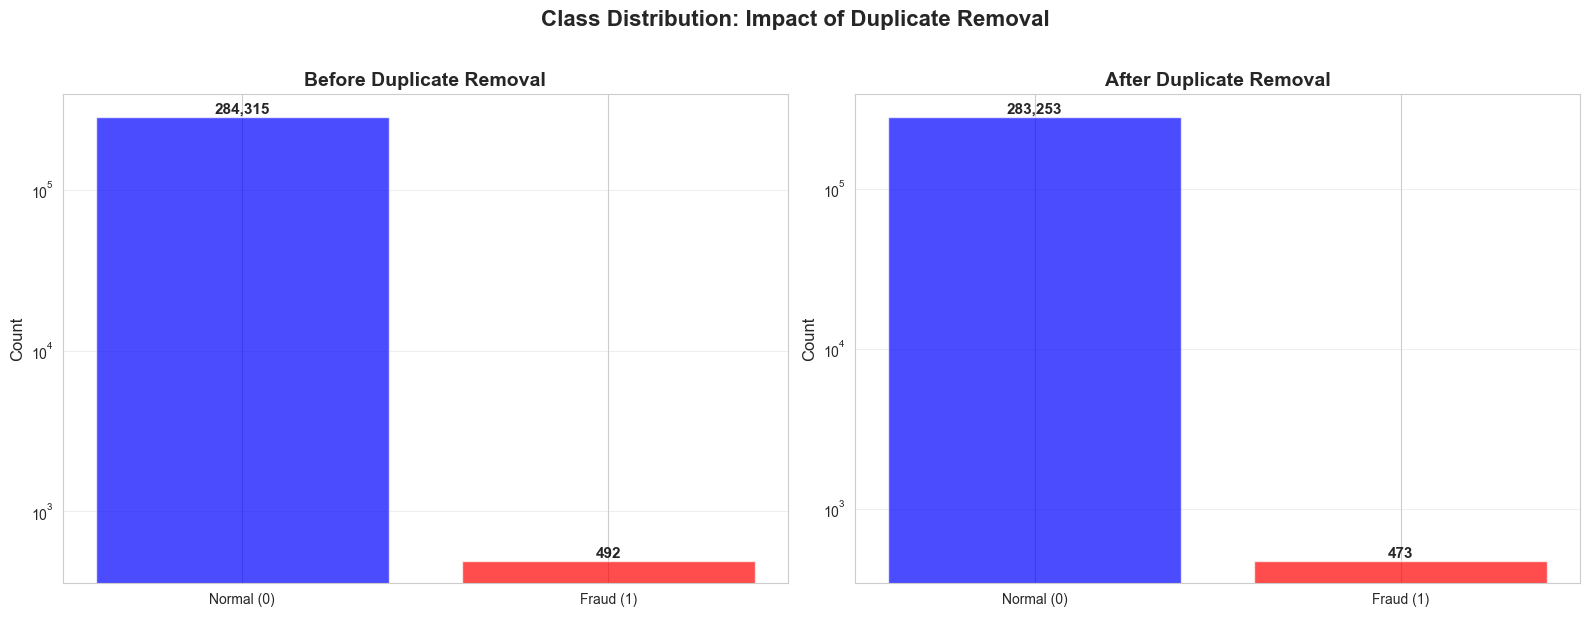

IMPACT OF DUPLICATE REMOVAL ON CLASS DISTRIBUTION

Normal Transactions:
  Before (Original): 284,315 (99.83%)
  After (Cleaned): 283,253 (99.45%)
  Duplicates Removed: 1,062 (0.37%)

Fraud Transactions:
  Before (Original): 492 (0.17%)
  After (Cleaned): 473 (0.17%)
  Duplicates Removed: 19 (3.86%)

Imbalance Ratio:
  Before: 577.9:1
  After: 598.8:1


In [ ]:
# ============================================================================
# Class Distribution: Before vs After Duplicate Removal
# ============================================================================

# Calculate distributions
df_original = df.copy()

before_percentages = (before_counts / len(df_original)) * 100
after_percentages = (after_counts / len(df)) * 100

# Create comparison visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Before cleaning
axes[0].bar(['Normal (0)', 'Fraud (1)'], before_counts.values, 
            color=['blue', 'red'], alpha=0.7)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Before Duplicate Removal', fontsize=14, fontweight='bold')
axes[0].set_yscale('log')  # Log scale for visibility
axes[0].grid(True, alpha=0.3, axis='y')
for i, count in enumerate(before_counts.values):
    axes[0].text(i, count, f'{count:,}', ha='center', va='bottom', 
                 fontsize=11, fontweight='bold')

# Right: After cleaning
axes[1].bar(['Normal (0)', 'Fraud (1)'], after_counts.values, 
            color=['blue', 'red'], alpha=0.7)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title('After Duplicate Removal', fontsize=14, fontweight='bold')
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3, axis='y')
for i, count in enumerate(after_counts.values):
    axes[1].text(i, count, f'{count:,}', ha='center', va='bottom', 
                 fontsize=11, fontweight='bold')

plt.suptitle('Class Distribution: Impact of Duplicate Removal', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Summary statistics
print("="*70)
print("IMPACT OF DUPLICATE REMOVAL ON CLASS DISTRIBUTION")
print("="*70)
print(f"\nNormal Transactions:")
print(f"  Before (Original): {before_counts[0]:,} ({before_percentages[0]:.2f}%)")
print(f"  After (Cleaned): {after_counts[0]:,} ({after_percentages[0]:.2f}%)")
print(f"  Duplicates Removed: {before_counts[0] - after_counts[0]:,} ({(before_counts[0] - after_counts[0])/before_counts[0]*100:.2f}%)")

print(f"\nFraud Transactions:")
print(f"  Before (Original): {before_counts[1]:,} ({before_percentages[1]:.2f}%)")
print(f"  After (Cleaned): {after_counts[1]:,} ({after_percentages[1]:.2f}%)")
print(f"  Duplicates Removed: {before_counts[1] - after_counts[1]:,} ({(before_counts[1] - after_counts[1])/before_counts[1]*100:.2f}%)")

print(f"\nImbalance Ratio:")
print(f"  Before: {before_counts[0]/before_counts[1]:.1f}:1")
print(f"  After: {after_counts[0]/after_counts[1]:.1f}:1")
print("="*70)

In [ ]:
# Save original before cleaning (do this right after loading)
df_original = df.copy()

# Then visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

before_counts = df_original['Class'].value_counts()
after_counts = df_clean['Class'].value_counts()

# Before
axes[0].bar(['Normal', 'Fraud'], before_counts.values, color=['blue', 'red'], alpha=0.7)
axes[0].set_yscale('log')
axes[0].set_title('Before Duplicate Removal')
axes[0].set_ylabel('Count (log scale)')

# After
axes[1].bar(['Normal', 'Fraud'], after_counts.values, color=['blue', 'red'], alpha=0.7)
axes[1].set_yscale('log')
axes[1].set_title('After Duplicate Removal')
axes[1].set_ylabel('Count (log scale)')

plt.tight_layout()
plt.show()

# Print summary
print(f"Imbalance ratio: {before_counts[0]/before_counts[1]:.1f}:1 → {after_counts[0]/after_counts[1]:.1f}:1")

Visualised the above chnages before and after duplicate removal to see effect on dataset. 
As we can see and listed earlier, minimal changes in both classes.

Although there is a need to acknoledge the fact that:
removing the duplicates slightly increases the imbalance ratio

- **Majority Class Dominated Duplicates**: The increase in the imbalance ratio suggests that the duplicates in the original dataset primarily consisted of non-fraudulent records. When these identical majority class samples were removed, the total count of majority class instances decreased more significantly relative to the minority class, thus **slightly skewing the data to be more imbalanced.**

- **Minimal Impact on Model Training**: The absolute change in the ratio is **minor** (an increase of about 20 points). In the context of such extreme imbalance, this slight shift is **unlikely to have a substantial practical impact on how the dataset's imbalance affects most machine learning models.** The dataset remains highly imbalanced, and techniques like resampling or using class weights will still be necessary for effective model training.

- **Improved Data Quality**: The primary benefit of removing duplicates is **improved data quality and the prevention of data leakage or overfitting to repeated instances**, not rebalancing the dataset. The resulting dataset provides a more accurate representation of unique transactions



## Comprehensive Analysis (need to delete)
- correlations
- distributions
- statistical tests


Top 10 features most correlated with Class:
Class     1.000000
V11       0.149067
V4        0.129326
V2        0.084624
V19       0.033631
V8        0.033068
V21       0.026357
V27       0.021892
V20       0.021486
V28       0.009682
Amount    0.005777
Name: Class, dtype: float64

Bottom 10 features least correlated with Class:
V9    -0.094021
V1    -0.094486
V18   -0.105340
V7    -0.172347
V3    -0.182322
V16   -0.187186
V10   -0.206971
V12   -0.250711
V14   -0.293375
V17   -0.313498
Name: Class, dtype: float64


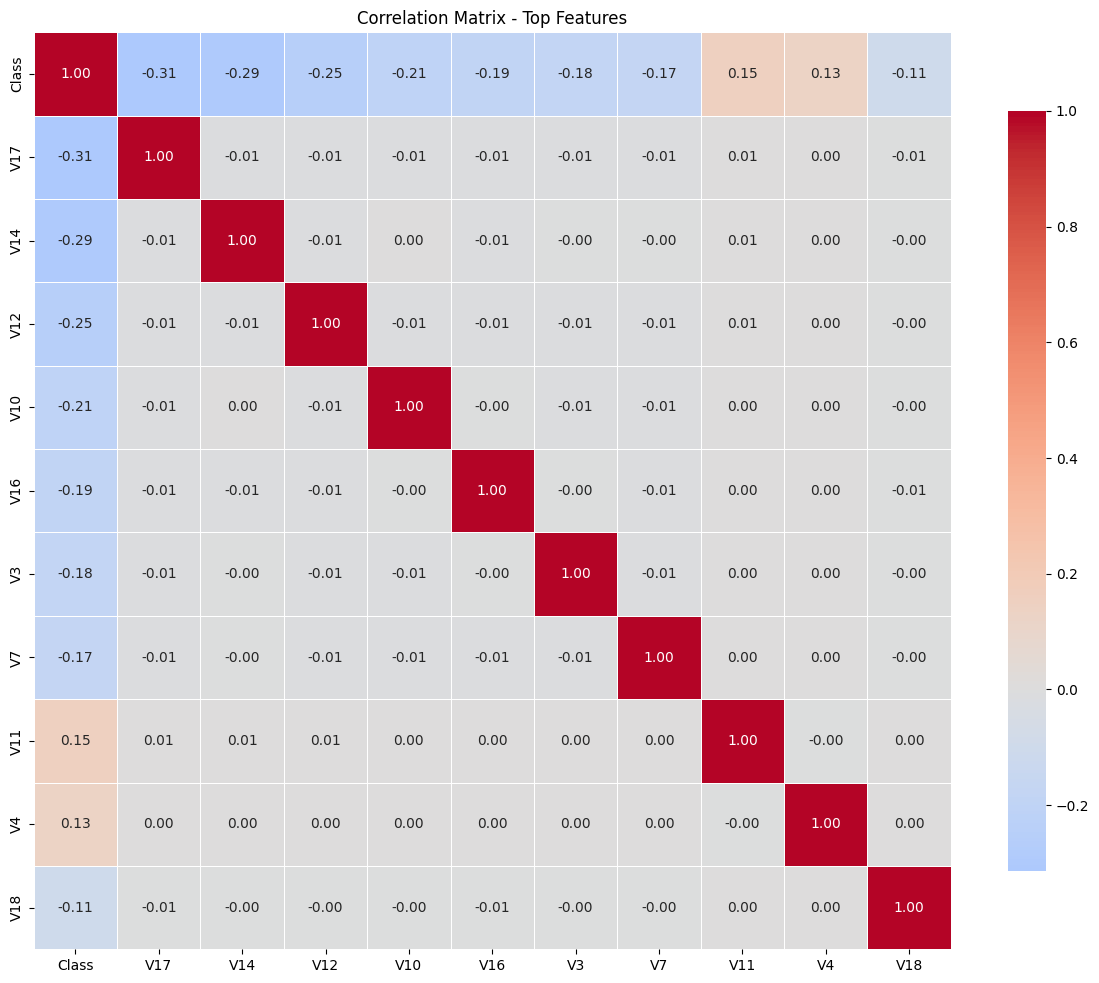

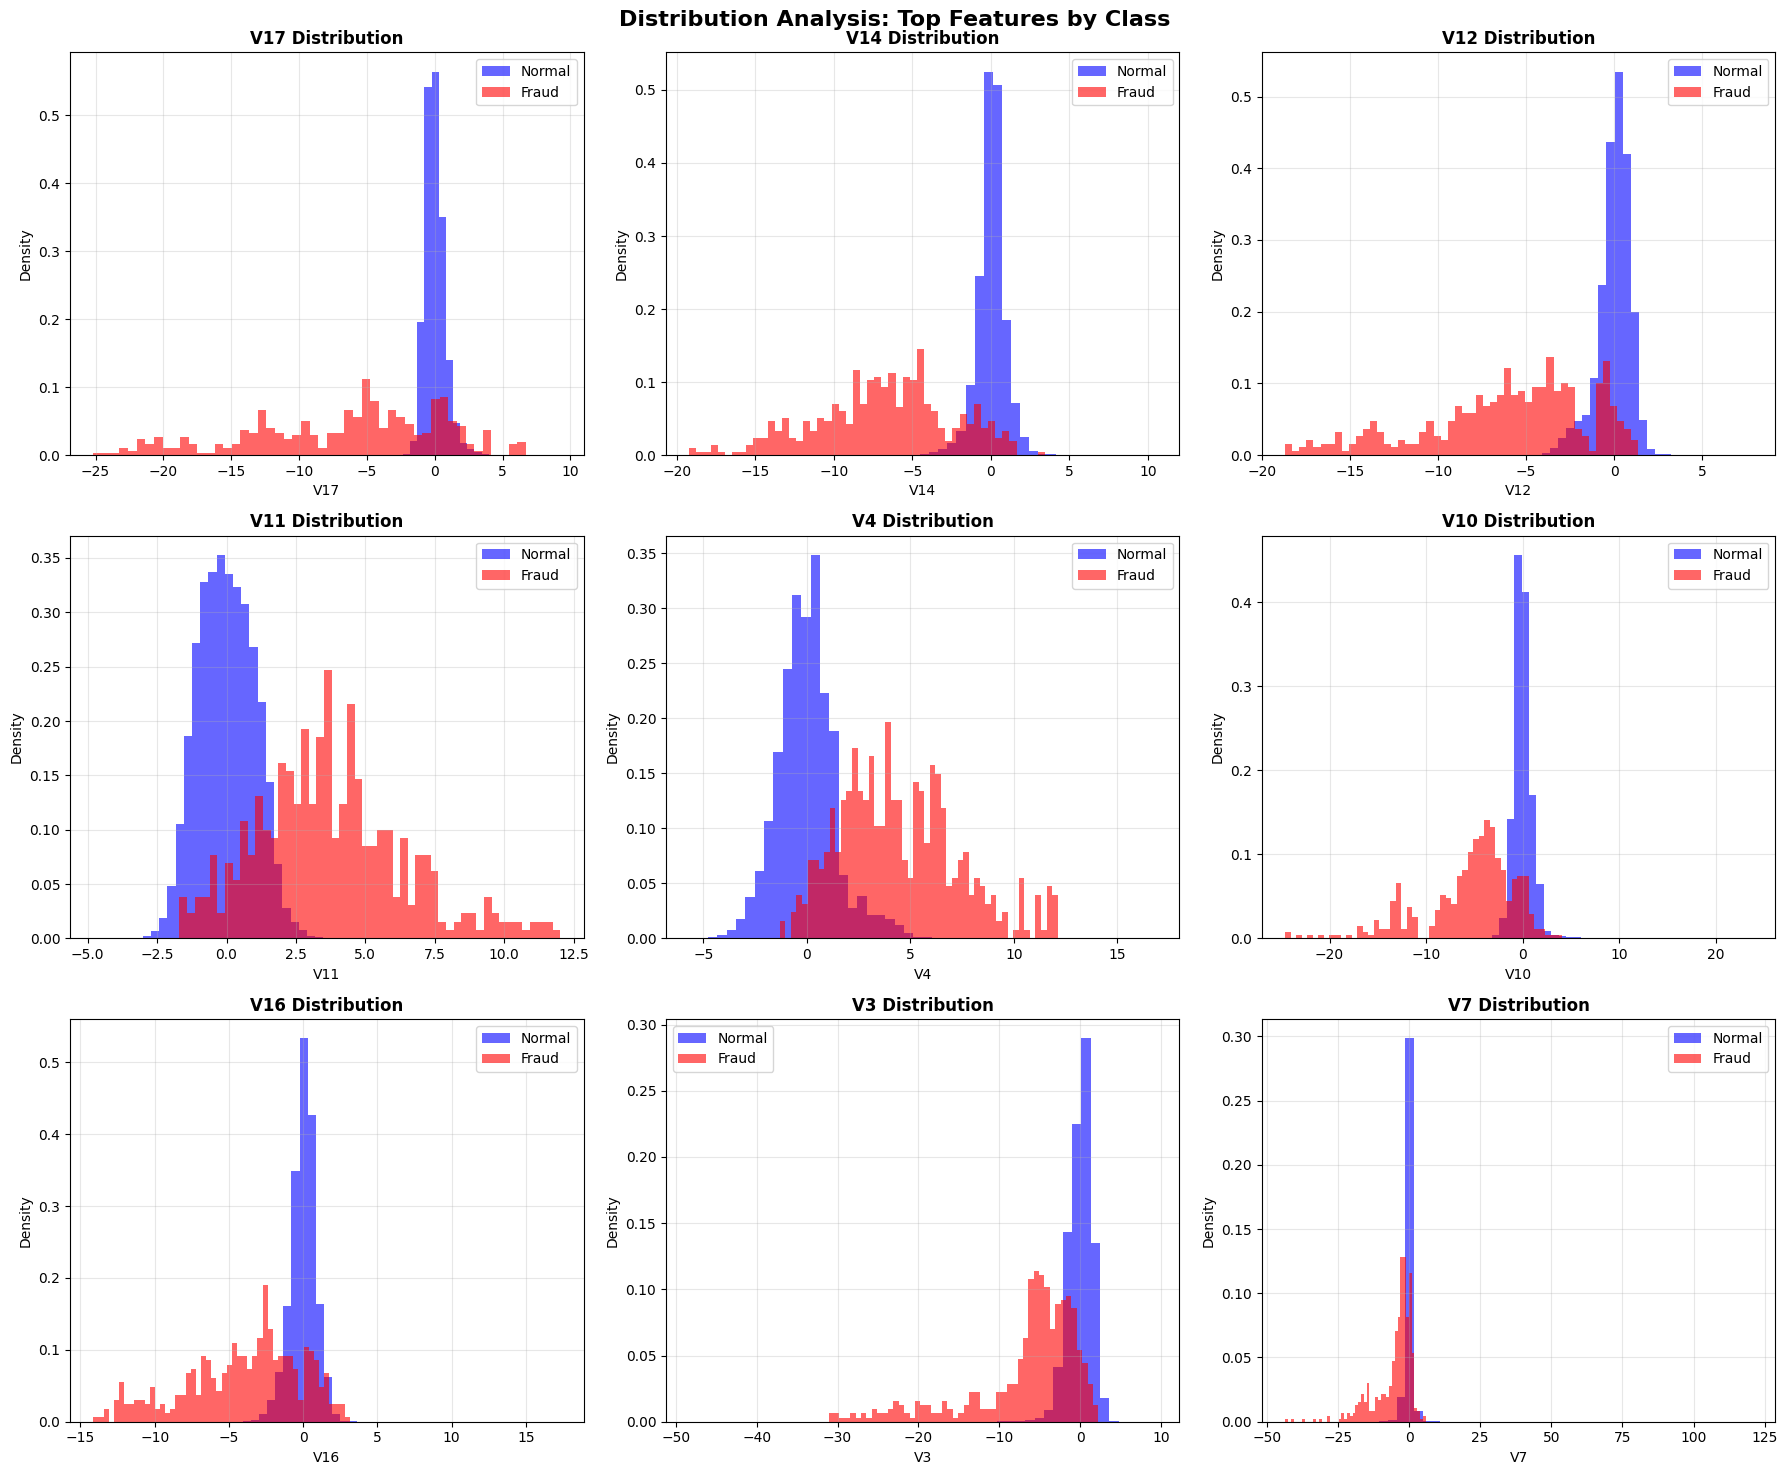


STATISTICAL TESTS SUMMARY
Feature  Normal_Mean  Fraud_Mean  Mean_Diff  T-test_pvalue  Mann-Whitney_pvalue  Cohen's_d
    V17     0.010963   -6.463285   6.474249            0.0        2.854261e-113   8.092438
    V14     0.011668   -6.835946   6.847614            0.0        2.304859e-248   7.522233
    V12     0.009476   -6.103254   6.112730            0.0        1.358344e-234   6.348196
    V11    -0.006004    3.716347  -3.722350            0.0        4.678414e-214  -3.695228
     V4    -0.010440    4.472591  -4.483031            0.0        1.599221e-236  -3.196889
    V10     0.007663   -5.453274   5.460937            0.0        9.598036e-210   5.185574
    V16     0.007845   -4.000956   4.008801            0.0        1.110506e-145   4.670876
     V3     0.012853   -6.729599   6.742452            0.0        8.738656e-208   4.545278
     V7     0.010447   -5.175912   5.186359            0.0        6.513087e-136   4.288743

Significance: *** p<0.001, ** p<0.01, * p<0.05


In [ ]:
# ============================================================================
# CORRELATION ANALYSIS
# ============================================================================

# 1. Basic correlation with Class
correlations = df.corr()['Class'].sort_values(ascending=False)
print("Top 10 features most correlated with Class:")
print(correlations.head(11))
print("\nBottom 10 features least correlated with Class:")
print(correlations.tail(10))

# 2. Correlation heatmap for top features
top_features = correlations.abs().nlargest(11).index.tolist()
corr_matrix = df[top_features].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix - Top Features')
plt.tight_layout()
plt.show()

# ============================================================================
# DISTRIBUTION ANALYSIS
# ============================================================================

# 3. Histograms for top features (simplified - no KDE)
top_features = ['V17', 'V14', 'V12', 'V11', 'V4', 'V10', 'V16', 'V3', 'V7']
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.ravel()

for idx, feature in enumerate(top_features):
    ax = axes[idx]
    normal_data = df[df['Class'] == 0][feature]
    fraud_data = df[df['Class'] == 1][feature]
    
    ax.hist(normal_data, bins=50, alpha=0.6, label='Normal', color='blue', density=True)
    ax.hist(fraud_data, bins=50, alpha=0.6, label='Fraud', color='red', density=True)
    
    ax.set_title(f'{feature} Distribution', fontsize=12, fontweight='bold')
    ax.set_xlabel(feature)
    ax.set_ylabel('Density')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Distribution Analysis: Top Features by Class', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================================
# STATISTICAL SIGNIFICANCE TESTING
# ============================================================================

# 4. Statistical tests (concise version - summary table only)

results = []
for feature in top_features:
    normal_data = df[df['Class'] == 0][feature]
    fraud_data = df[df['Class'] == 1][feature]
    
    t_stat, t_pvalue = ttest_ind(normal_data, fraud_data)
    u_stat, u_pvalue = mannwhitneyu(normal_data, fraud_data, alternative='two-sided')
    
    pooled_std = np.sqrt(((len(normal_data) - 1) * normal_data.std()**2 + 
                         (len(fraud_data) - 1) * fraud_data.std()**2) / 
                        (len(normal_data) + len(fraud_data) - 2))
    cohens_d = (normal_data.mean() - fraud_data.mean()) / pooled_std
    
    results.append({
        'Feature': feature,
        'Normal_Mean': normal_data.mean(),
        'Fraud_Mean': fraud_data.mean(),
        'Mean_Diff': normal_data.mean() - fraud_data.mean(),
        'T-test_pvalue': t_pvalue,
        'Mann-Whitney_pvalue': u_pvalue,
        "Cohen's_d": cohens_d
    })

results_df = pd.DataFrame(results)
print("\n" + "="*70)
print("STATISTICAL TESTS SUMMARY")
print("="*70)
print(results_df.to_string(index=False))
print("\nSignificance: *** p<0.001, ** p<0.01, * p<0.05")

# 5. Statistical test visualization (keep as is)
# ... (your existing code 1-54)

# ============================================================================
# OUTLIER ANALYSIS
# ============================================================================

# 6. Outlier visualization (keep as is - 1-74)

# ============================================================================
# AMOUNT ANALYSIS
# ============================================================================

# 7. Amount distribution by class (keep as is - 1-24)

# ============================================================================
# TEMPORAL ANALYSIS
# ============================================================================

# 8. Time analysis (keep as is - 1-29)

## Correlation Analysis

In [ ]:
# Calculate the correlation matrix
corr_matrix = df.corr()

# Get correlations with the 'Class' column
class_corr = corr_matrix['Class'].drop('Class')

# Sort correlations by absolute value in descending order
sorted_class_corr = class_corr.reindex(class_corr.abs().sort_values(ascending=False).index)

# Print the sorted correlations
print("Correlation with 'Class' (sorted by absolute value):\n", sorted_class_corr)


Correlation with 'Class' (sorted by absolute value):
 V17      -0.313498
V14      -0.293375
V12      -0.250711
V10      -0.206971
V16      -0.187186
V3       -0.182322
V7       -0.172347
V11       0.149067
V4        0.129326
V18      -0.105340
V1       -0.094486
V9       -0.094021
V5       -0.087812
V2        0.084624
V6       -0.043915
V19       0.033631
V8        0.033068
V21       0.026357
V27       0.021892
V20       0.021486
Time     -0.012359
V28       0.009682
V24      -0.007210
V23      -0.006333
Amount    0.005777
V22       0.004887
V26       0.004265
V13      -0.003897
V15      -0.003300
V25       0.003202
Name: Class, dtype: float64


In [31]:
# Correlation analysis with Class
correlations = df.corr()['Class'].sort_values(ascending=False)
print("Top 10 features most correlated with Class:")
print(correlations.head(11))  # 11 because Class will be first with correlation 1.0

print("\nBottom 10 features least correlated with Class:")
print(correlations.tail(10))


Top 10 features most correlated with Class:
Class     1.000000
V11       0.149067
V4        0.129326
V2        0.084624
V19       0.033631
V8        0.033068
V21       0.026357
V27       0.021892
V20       0.021486
V28       0.009682
Amount    0.005777
Name: Class, dtype: float64

Bottom 10 features least correlated with Class:
V9    -0.094021
V1    -0.094486
V18   -0.105340
V7    -0.172347
V3    -0.182322
V16   -0.187186
V10   -0.206971
V12   -0.250711
V14   -0.293375
V17   -0.313498
Name: Class, dtype: float64


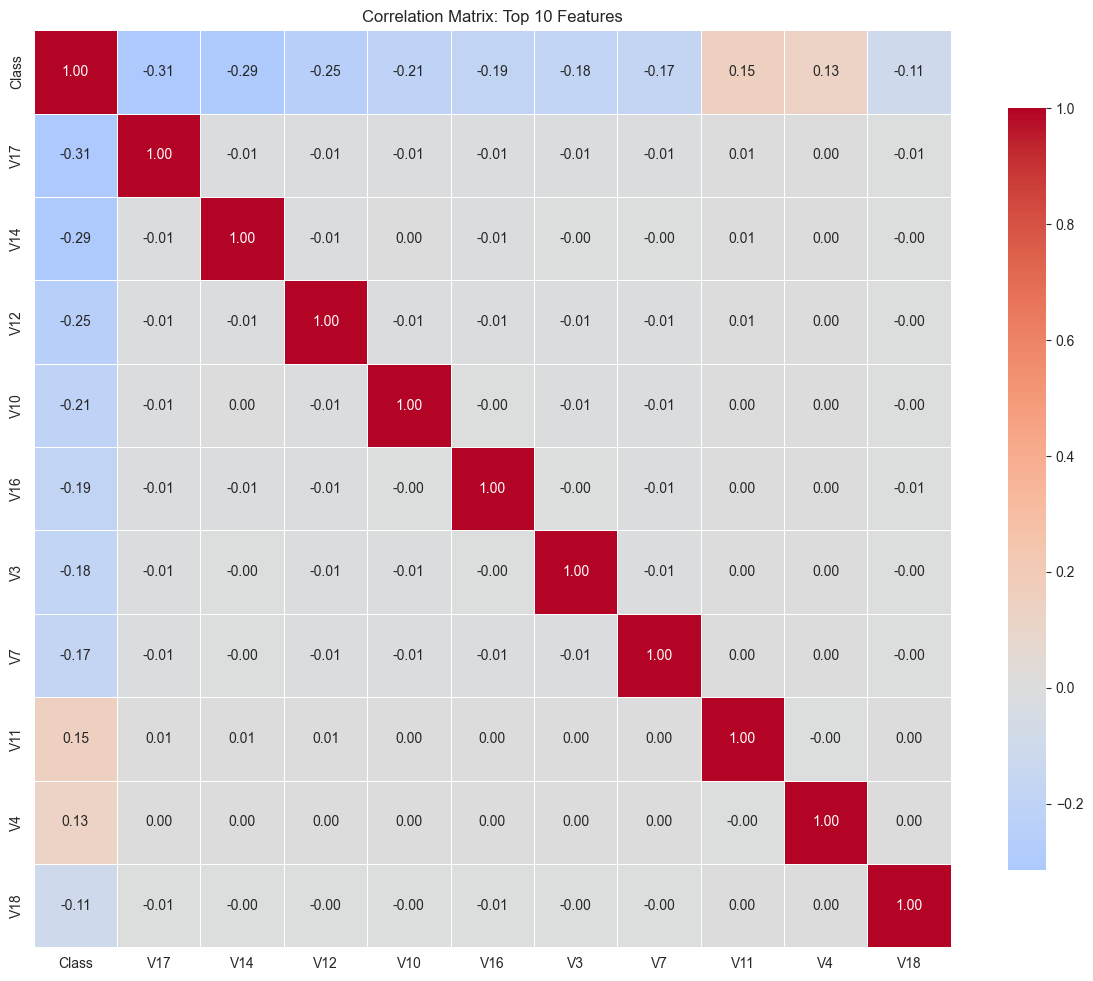

In [36]:
# Visualize correlation matrix for top correlated features
top_features = correlations.abs().nlargest(11).index.tolist()  # Include Class
corr_matrix = df[top_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title(f'Correlation Matrix: Top 10 Features')
plt.tight_layout()
plt.show()


## Feature Distributions


2D Scatter Plot: Using Most Fraud-Correlated Features
Using features: ['V17', 'V14']
Correlations with Class: V17    0.313498
V14    0.293375
Name: Class, dtype: float64


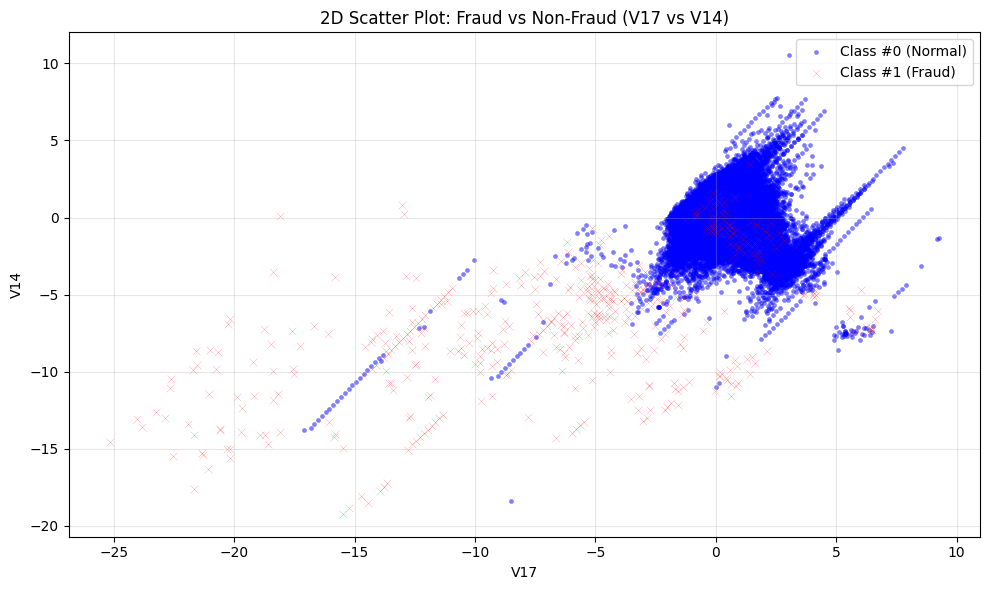

In [37]:
# ============================================================================
# 2D Scatter Plot: Using Most Fraud-Correlated Features
# ============================================================================
# Alternative visualization using the two features most correlated with fraud

print("="*70)
print("2D Scatter Plot: Using Most Fraud-Correlated Features")
print("="*70)

# Calculate correlation with Class and select top 2 features
correlations = df.corr()['Class'].abs().sort_values(ascending=False)
top_features = correlations.head(3).index[1:3].tolist()  # Skip 'Class' itself

print(f"Using features: {top_features}")
print(f"Correlations with Class: {correlations[top_features]}")

# Extract data for visualization
X_2d = df[top_features].values
y = df['Class'].values

# Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(X_2d[y == 0, 0], X_2d[y == 0, 1], 
            label="Class #0 (Normal)", 
            alpha=0.5, linewidth=0.15, s=10, color='blue')
plt.scatter(X_2d[y == 1, 0], X_2d[y == 1, 1], 
            label="Class #1 (Fraud)", 
            alpha=0.7, linewidth=0.15, s=30, c='red', marker='x')
plt.xlabel(top_features[0])
plt.ylabel(top_features[1])
plt.title(f'2D Scatter Plot: Fraud vs Non-Fraud ({top_features[0]} vs {top_features[1]})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

DISTRIBUTION ANALYSIS OF TOP FEATURES

Analyzing 9 top features based on correlation with Class



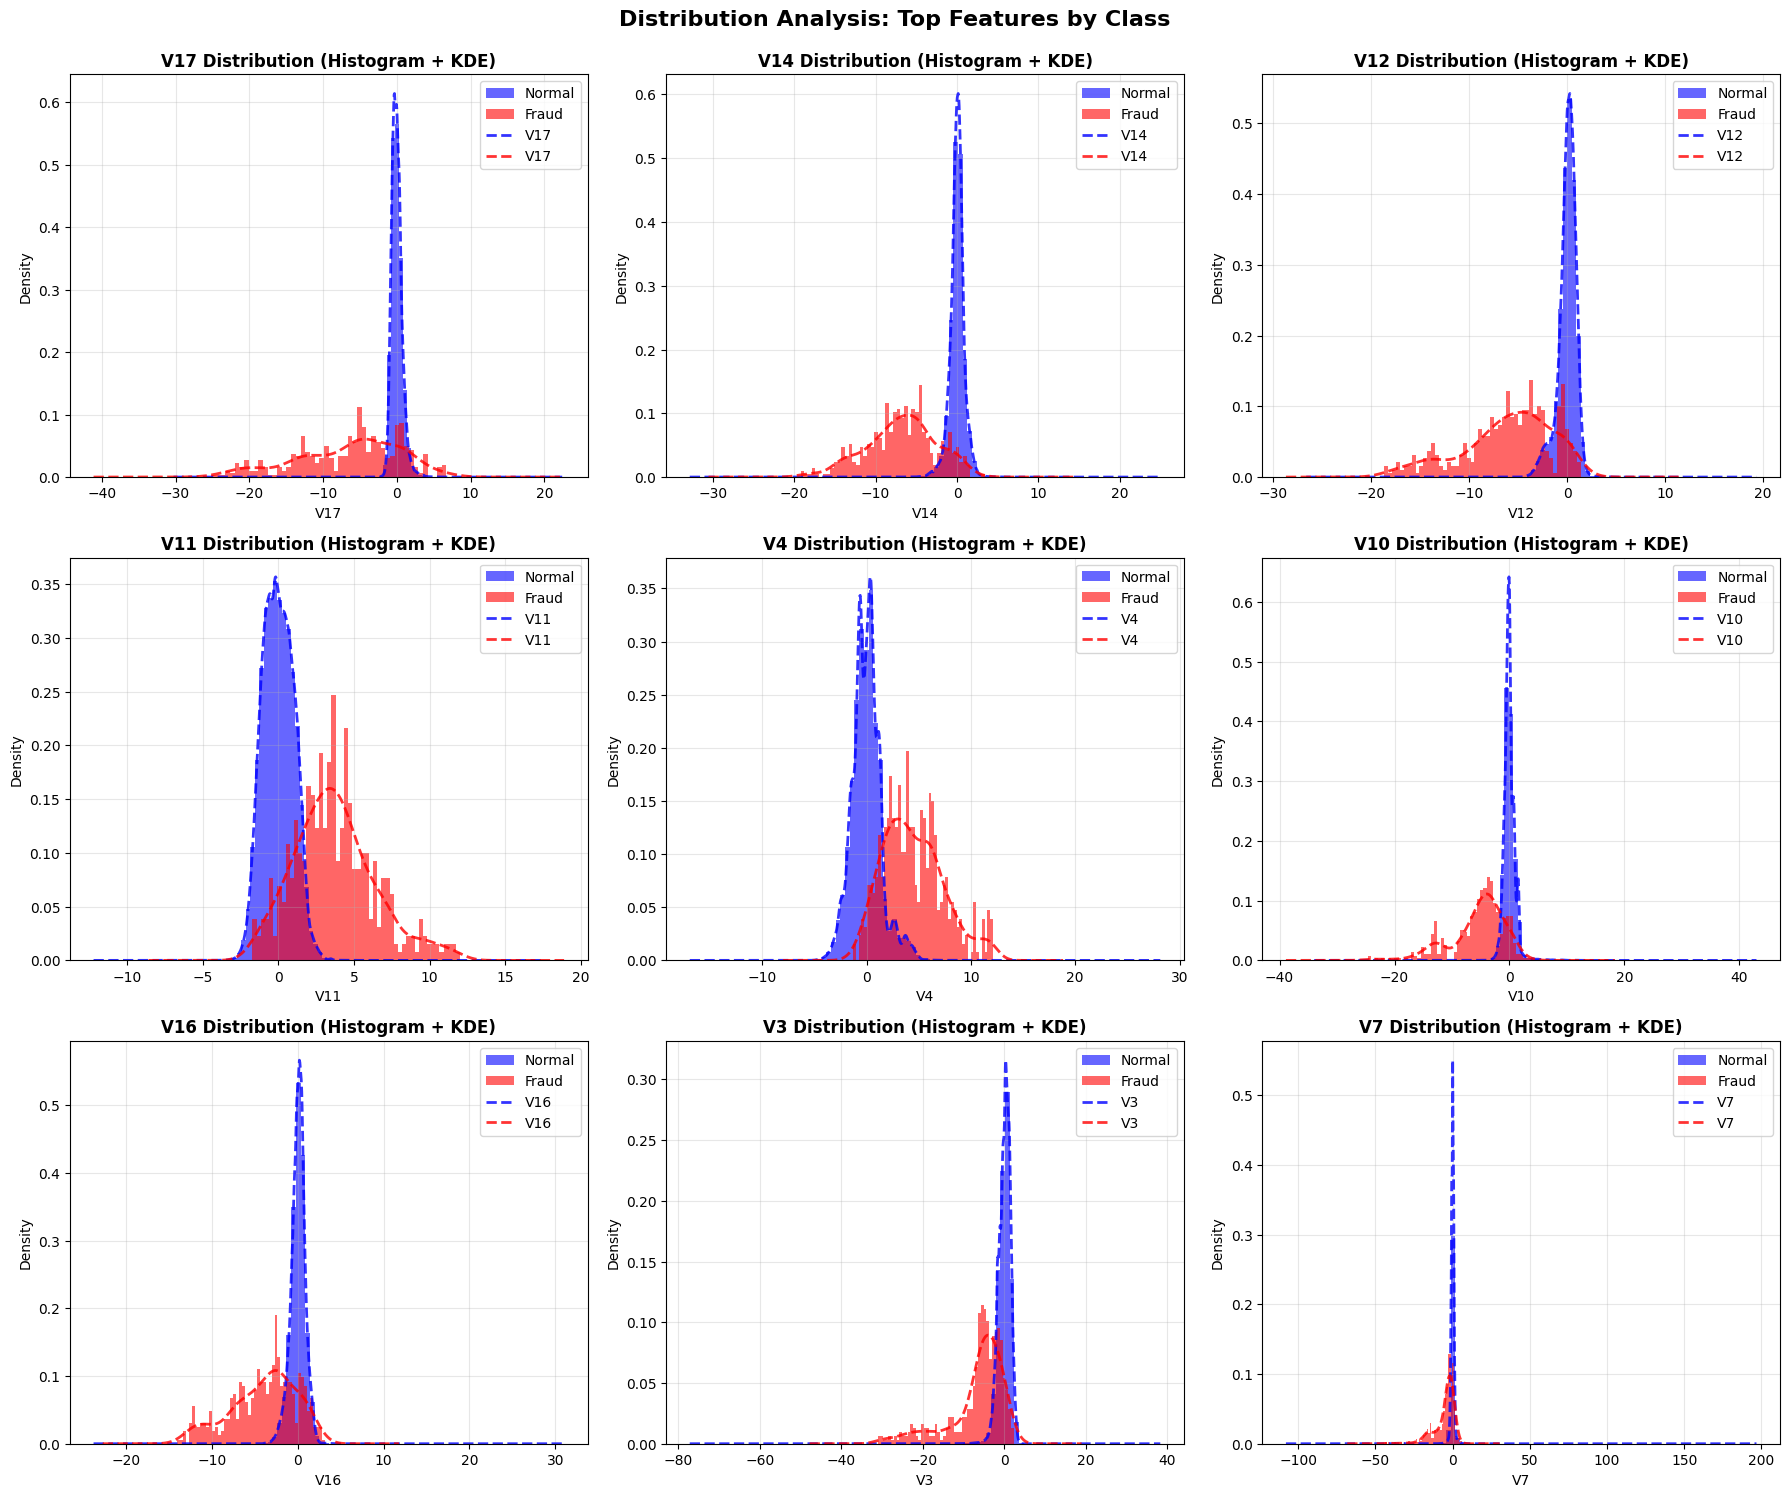

In [ ]:
# Keep, but streamline
# Distribution analysis of top correlated features

# Top features based on correlation with Class
top_features = ['V17', 'V14', 'V12', 'V11', 'V4', 'V10', 'V16', 'V3', 'V7']

print("="*70)
print("DISTRIBUTION ANALYSIS OF TOP FEATURES")
print("="*70)
print(f"\nAnalyzing {len(top_features)} top features based on correlation with Class\n")
# 1. Histograms and KDE plots by class
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.ravel()

for idx, feature in enumerate(top_features):
    ax = axes[idx]
    
    # Get data by class
    normal_data = df[df['Class'] == 0][feature]
    fraud_data = df[df['Class'] == 1][feature]
    
    # Histogram
    ax.hist(normal_data, bins=50, alpha=0.6, label='Normal', color='blue', density=True)
    ax.hist(fraud_data, bins=50, alpha=0.6, label='Fraud', color='red', density=True)
    
    # KDE overlay
    normal_data.plot.kde(ax=ax, color='blue', linewidth=2, linestyle='--', alpha=0.8)
    fraud_data.plot.kde(ax=ax, color='red', linewidth=2, linestyle='--', alpha=0.8)
    
    ax.set_title(f'{feature} Distribution (Histogram + KDE)', fontsize=12, fontweight='bold')
    ax.set_xlabel(feature)
    ax.set_ylabel('Density')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Distribution Analysis: Top Features by Class', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()


/var/folders/pc/62g2xhyd3nd1zwxk910m87jc0000gn/T/ipykernel_46209/3736301812.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([normal_data, fraud_data],
/var/folders/pc/62g2xhyd3nd1zwxk910m87jc0000gn/T/ipykernel_46209/3736301812.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([normal_data, fraud_data],
/var/folders/pc/62g2xhyd3nd1zwxk910m87jc0000gn/T/ipykernel_46209/3736301812.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([normal_data, fraud_data],
/var/folders/pc/62g2xhyd3nd1zwxk910m87jc0000gn/T/ipykernel_46209/3736301812.py:13: MatplotlibDeprecationWarni

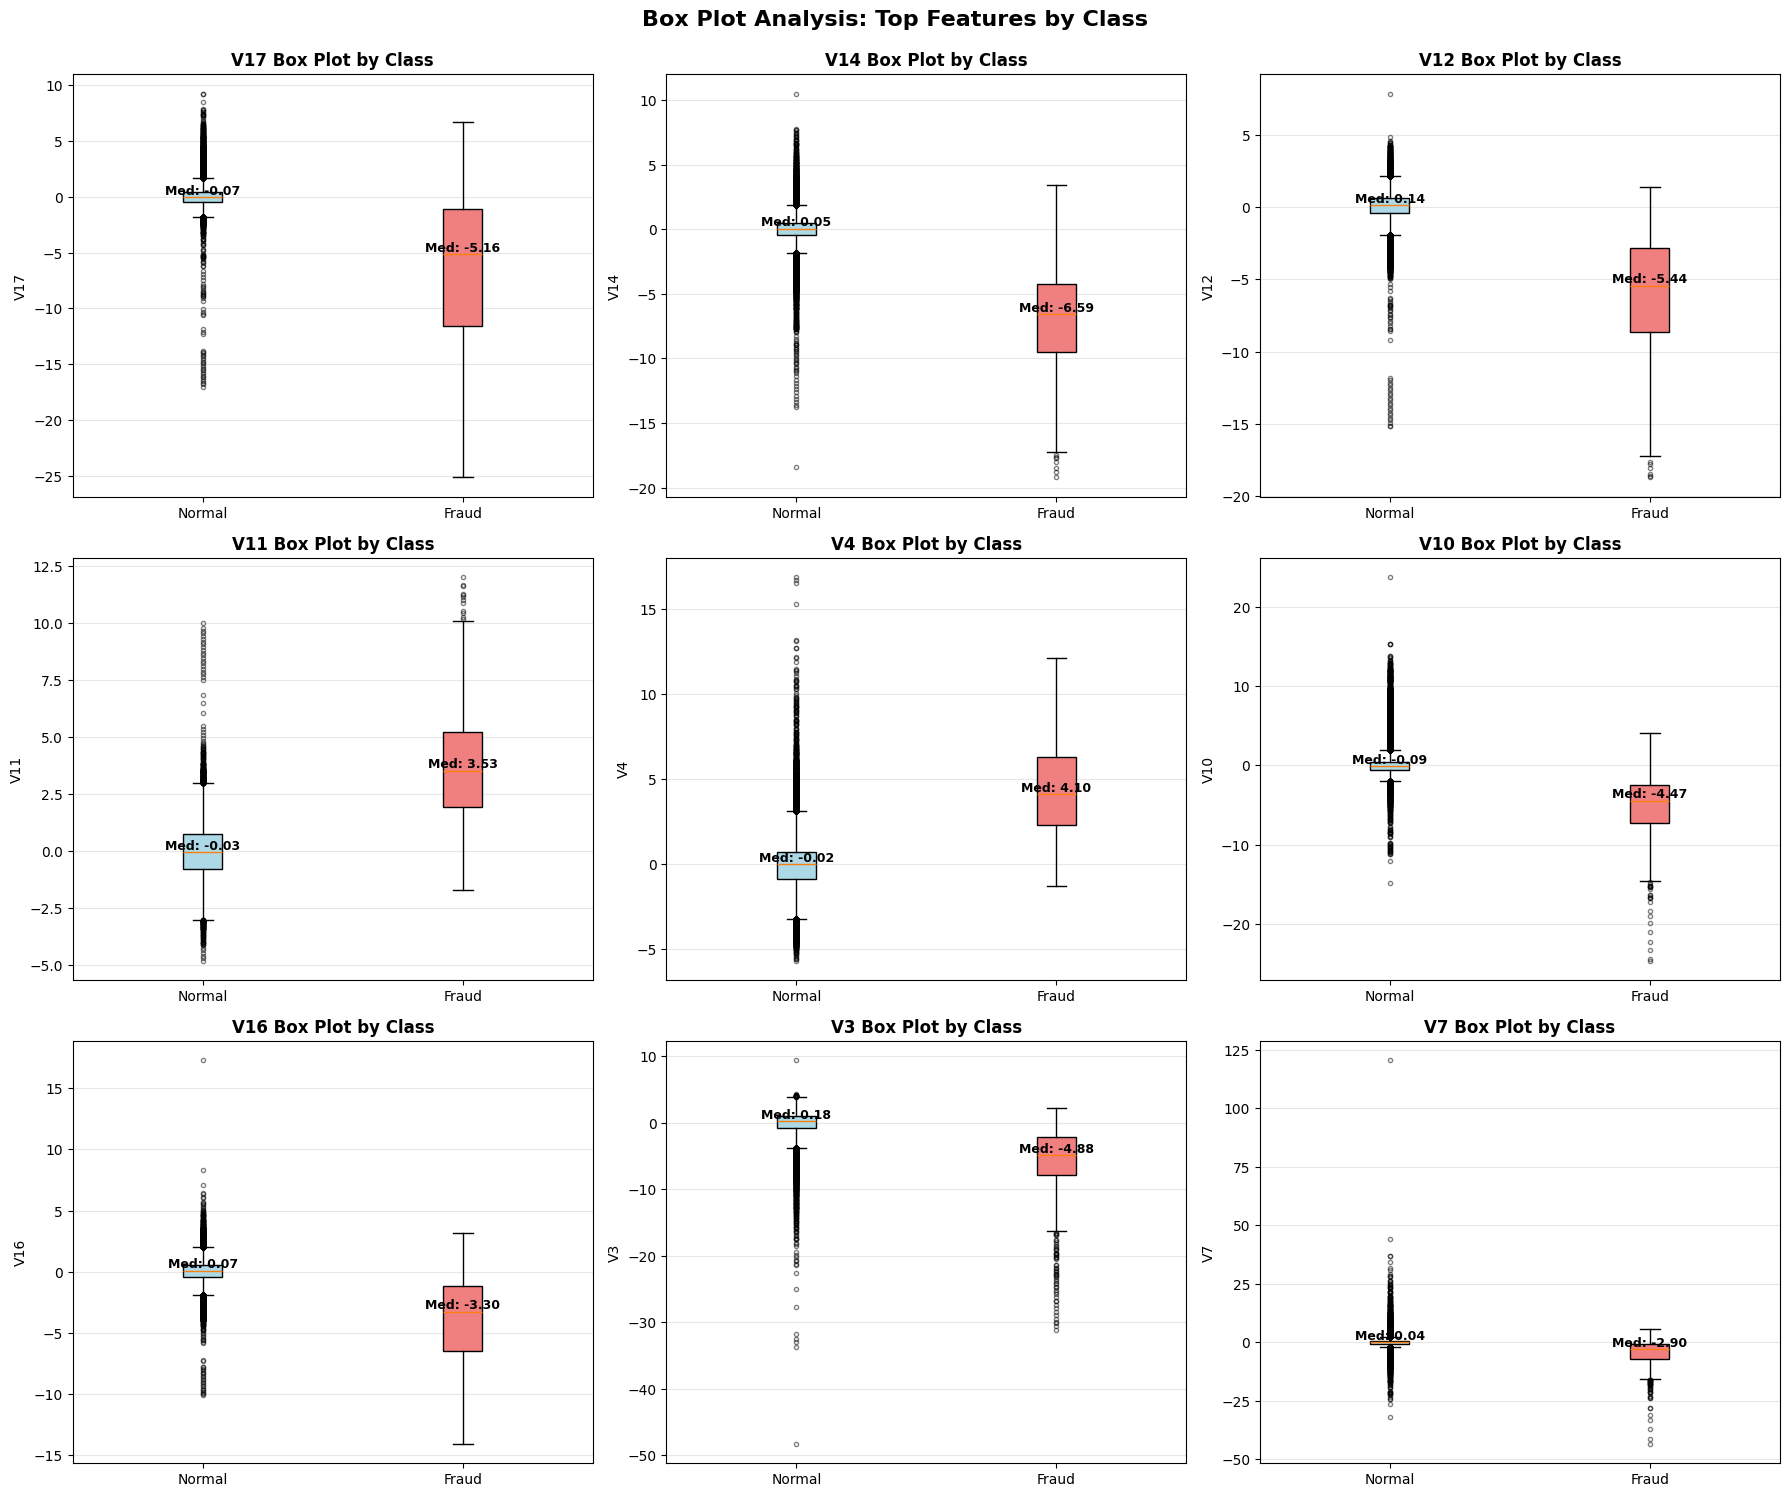

In [ ]:
# 2. Box plots by class
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.ravel()

for idx, feature in enumerate(top_features):
    ax = axes[idx]
    
    # Prepare data for box plot
    normal_data = df[df['Class'] == 0][feature]
    fraud_data = df[df['Class'] == 1][feature]
    
    # Create box plot
    bp = ax.boxplot([normal_data, fraud_data], 
                     labels=['Normal', 'Fraud'],
                     patch_artist=True,
                     showfliers=True,
                     flierprops=dict(marker='o', markersize=3, alpha=0.5))
    
    # Color the boxes
    bp['boxes'][0].set_facecolor('lightblue')
    bp['boxes'][1].set_facecolor('lightcoral')
    
    ax.set_title(f'{feature} Box Plot by Class', fontsize=12, fontweight='bold')
    ax.set_ylabel(feature)
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add median values as text
    medians = [np.median(normal_data), np.median(fraud_data)]
    for i, median in enumerate(medians):
        ax.text(i+1, median, f'Med: {median:.2f}', 
                ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Box Plot Analysis: Top Features by Class', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()


## Statistical Tests

In [ ]:
# KEEP BUT MAKE CONCISE
# 3. Statistical tests to verify differences
print("\n" + "="*70)
print("STATISTICAL TESTS: Verifying Differences Between Classes")
print("="*70)

results = []

for feature in top_features:
    normal_data = df[df['Class'] == 0][feature]
    fraud_data = df[df['Class'] == 1][feature]
    
    # T-test (parametric - assumes normal distribution)
    t_stat, t_pvalue = ttest_ind(normal_data, fraud_data)
    
    # Mann-Whitney U test (non-parametric - no distribution assumptions)
    u_stat, u_pvalue = mannwhitneyu(normal_data, fraud_data, alternative='two-sided')
    
    # Calculate effect size (Cohen's d)
    pooled_std = np.sqrt(((len(normal_data) - 1) * normal_data.std()**2 + 
                         (len(fraud_data) - 1) * fraud_data.std()**2) / 
                        (len(normal_data) + len(fraud_data) - 2))
    cohens_d = (normal_data.mean() - fraud_data.mean()) / pooled_std
    
    # Calculate means
    normal_mean = normal_data.mean()
    fraud_mean = fraud_data.mean()
    mean_diff = normal_mean - fraud_mean
    
    results.append({
        'Feature': feature,
        'Normal_Mean': normal_mean,
        'Fraud_Mean': fraud_mean,
        'Mean_Diff': mean_diff,
        'T-test_pvalue': t_pvalue,
        'Mann-Whitney_pvalue': u_pvalue,
        "Cohen's_d": cohens_d
    })
    
    # Print results
    print(f"\n{feature}:")
    print(f"  Normal Mean: {normal_mean:.4f}, Fraud Mean: {fraud_mean:.4f}, Difference: {mean_diff:.4f}")
    print(f"  T-test p-value: {t_pvalue:.2e} {'***' if t_pvalue < 0.001 else '**' if t_pvalue < 0.01 else '*' if t_pvalue < 0.05 else 'ns'}")
    print(f"  Mann-Whitney p-value: {u_pvalue:.2e} {'***' if u_pvalue < 0.001 else '**' if u_pvalue < 0.01 else '*' if u_pvalue < 0.05 else 'ns'}")
    print(f"  Cohen's d (effect size): {cohens_d:.4f} {'(large)' if abs(cohens_d) > 0.8 else '(medium)' if abs(cohens_d) > 0.5 else '(small)'}")

# Create summary dataframe
results_df = pd.DataFrame(results)
print("\n" + "="*70)
print("SUMMARY TABLE")
print("="*70)
print(results_df.to_string(index=False))
print("\nSignificance levels: *** p<0.001, ** p<0.01, * p<0.05, ns = not significant")



STATISTICAL TESTS: Verifying Differences Between Classes

V17:
  Normal Mean: 0.0110, Fraud Mean: -6.4633, Difference: 6.4742
  T-test p-value: 0.00e+00 ***
  Mann-Whitney p-value: 2.85e-113 ***
  Cohen's d (effect size): 8.0924 (large)

V14:
  Normal Mean: 0.0117, Fraud Mean: -6.8359, Difference: 6.8476
  T-test p-value: 0.00e+00 ***
  Mann-Whitney p-value: 2.30e-248 ***
  Cohen's d (effect size): 7.5222 (large)

V12:
  Normal Mean: 0.0095, Fraud Mean: -6.1033, Difference: 6.1127
  T-test p-value: 0.00e+00 ***
  Mann-Whitney p-value: 1.36e-234 ***
  Cohen's d (effect size): 6.3482 (large)

V11:
  Normal Mean: -0.0060, Fraud Mean: 3.7163, Difference: -3.7224
  T-test p-value: 0.00e+00 ***
  Mann-Whitney p-value: 4.68e-214 ***
  Cohen's d (effect size): -3.6952 (large)

V4:
  Normal Mean: -0.0104, Fraud Mean: 4.4726, Difference: -4.4830
  T-test p-value: 0.00e+00 ***
  Mann-Whitney p-value: 1.60e-236 ***
  Cohen's d (effect size): -3.1969 (large)

V10:
  Normal Mean: 0.0077, Fraud Mean

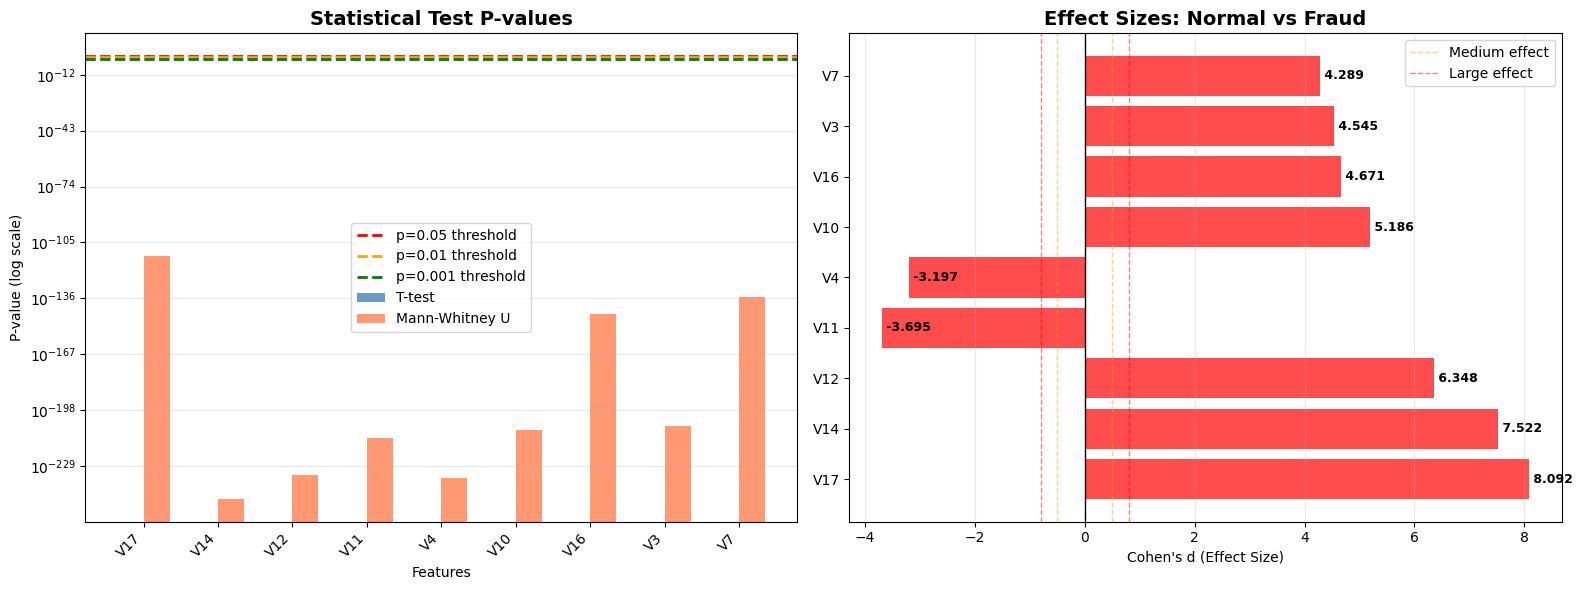


Effect Size Interpretation:
  |d| < 0.2: Negligible
  0.2 ≤ |d| < 0.5: Small
  0.5 ≤ |d| < 0.8: Medium
  |d| ≥ 0.8: Large


In [ ]:
# KEEP
# Visualize statistical test results
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: P-values comparison
x_pos = np.arange(len(top_features))
width = 0.35

axes[0].bar(x_pos - width/2, results_df['T-test_pvalue'], width, 
            label='T-test', alpha=0.8, color='steelblue')
axes[0].bar(x_pos + width/2, results_df['Mann-Whitney_pvalue'], width, 
            label='Mann-Whitney U', alpha=0.8, color='coral')

axes[0].axhline(y=0.05, color='red', linestyle='--', linewidth=2, label='p=0.05 threshold')
axes[0].axhline(y=0.01, color='orange', linestyle='--', linewidth=2, label='p=0.01 threshold')
axes[0].axhline(y=0.001, color='green', linestyle='--', linewidth=2, label='p=0.001 threshold')

axes[0].set_xlabel('Features')
axes[0].set_ylabel('P-value (log scale)')
axes[0].set_title('Statistical Test P-values', fontsize=14, fontweight='bold')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(top_features, rotation=45, ha='right')
axes[0].set_yscale('log')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Plot 2: Effect sizes (Cohen's d)
colors = ['red' if abs(d) > 0.8 else 'orange' if abs(d) > 0.5 else 'yellow' 
          for d in results_df["Cohen's_d"]]
bars = axes[1].barh(top_features, results_df["Cohen's_d"], color=colors, alpha=0.7)

axes[1].axvline(x=0, color='black', linestyle='-', linewidth=1)
axes[1].axvline(x=0.5, color='orange', linestyle='--', linewidth=1, alpha=0.5, label='Medium effect')
axes[1].axvline(x=-0.5, color='orange', linestyle='--', linewidth=1, alpha=0.5)
axes[1].axvline(x=0.8, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Large effect')
axes[1].axvline(x=-0.8, color='red', linestyle='--', linewidth=1, alpha=0.5)

axes[1].set_xlabel("Cohen's d (Effect Size)")
axes[1].set_title("Effect Sizes: Normal vs Fraud", fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='x')

# Add value labels on bars
for i, (bar, d) in enumerate(zip(bars, results_df["Cohen's_d"])):
    axes[1].text(d, i, f' {d:.3f}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nEffect Size Interpretation:")
print("  |d| < 0.2: Negligible")
print("  0.2 ≤ |d| < 0.5: Small")
print("  0.5 ≤ |d| < 0.8: Medium")
print("  |d| ≥ 0.8: Large")


In [ ]:
# Summary statistics table for top features
print("\n" + "="*70)
print("SUMMARY STATISTICS: Top Features by Class")
print("="*70)

summary_stats = []

for feature in top_features:
    normal_data = df[df['Class'] == 0][feature]
    fraud_data = df[df['Class'] == 1][feature]
    
    summary_stats.append({
        'Feature': feature,
        'Normal_Mean': normal_data.mean(),
        'Normal_Median': np.median(normal_data),
        'Normal_Std': normal_data.std(),
        'Fraud_Mean': fraud_data.mean(),
        'Fraud_Median': np.median(fraud_data),
        'Fraud_Std': fraud_data.std(),
        'Mean_Diff': normal_data.mean() - fraud_data.mean(),
        'Median_Diff': np.median(normal_data) - np.median(fraud_data)
    })

summary_df = pd.DataFrame(summary_stats)
print("\n" + summary_df.to_string(index=False))



SUMMARY STATISTICS: Top Features by Class

Feature  Normal_Mean  Normal_Median  Normal_Std  Fraud_Mean  Fraud_Median  Fraud_Std  Mean_Diff  Median_Diff
    V17     0.010963      -0.065096    0.748513   -6.463285     -5.157596   6.965744   6.474249     5.092500
    V14     0.011668       0.051486    0.894379   -6.835946     -6.590550   4.253210   6.847614     6.642036
    V12     0.009476       0.140573    0.945382   -6.103254     -5.437354   4.582331   6.112730     5.577926
    V11    -0.006004      -0.034446    1.002257    3.716347      3.525726   2.672817  -3.722350    -3.560172
     V4    -0.010440      -0.024500    1.398575    4.472591      4.100098   2.871523  -4.483031    -4.124598
    V10     0.007663      -0.092120    1.036321   -5.453274     -4.466284   4.706451   5.460937     4.374164
    V16     0.007845       0.068100    0.844608   -4.000956     -3.302899   3.831724   4.008801     3.370998
     V3     0.012853       0.182247    1.457593   -6.729599     -4.875397   6.909647

/var/folders/pc/62g2xhyd3nd1zwxk910m87jc0000gn/T/ipykernel_46209/3426274676.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(box_data, labels=['Normal', 'Fraud'], patch_artist=True,


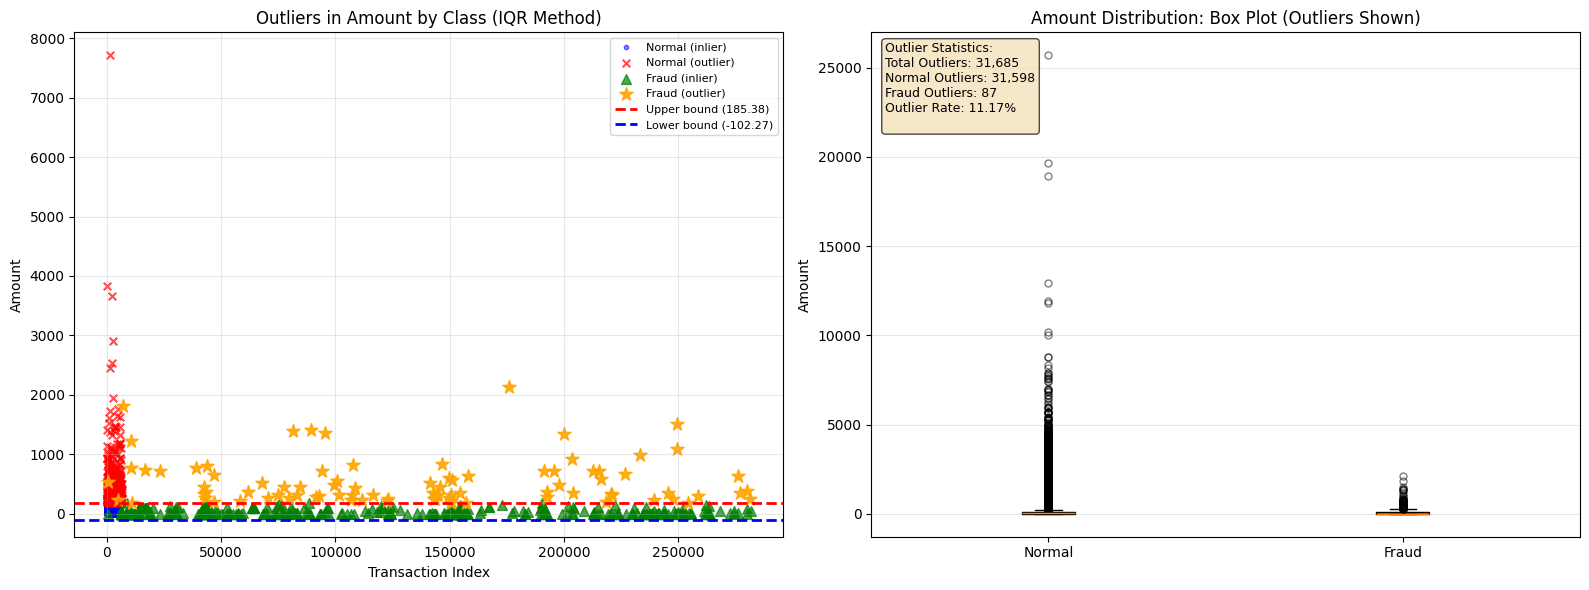

In [ ]:
# KEEP
# Visualize outliers detected by IQR method
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Calculate IQR bounds for Amount
Q1 = df['Amount'].quantile(0.25)
Q3 = df['Amount'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Mark outliers
df['is_outlier'] = (df['Amount'] < lower_bound) | (df['Amount'] > upper_bound)

# Plot 1: Scatter plot showing outliers by Class
normal_inliers = df[(df['Class'] == 0) & (~df['is_outlier'])].head(5000)
normal_outliers = df[(df['Class'] == 0) & (df['is_outlier'])].head(500)
fraud_inliers = df[(df['Class'] == 1) & (~df['is_outlier'])]
fraud_outliers = df[(df['Class'] == 1) & (df['is_outlier'])]

axes[0].scatter(normal_inliers.index, normal_inliers['Amount'], 
                alpha=0.5, label='Normal (inlier)', color='blue', s=10)
axes[0].scatter(normal_outliers.index, normal_outliers['Amount'], 
                alpha=0.7, label='Normal (outlier)', color='red', s=30, marker='x')
axes[0].scatter(fraud_inliers.index, fraud_inliers['Amount'], 
                alpha=0.7, label='Fraud (inlier)', color='green', s=50, marker='^')
axes[0].scatter(fraud_outliers.index, fraud_outliers['Amount'], 
                alpha=0.9, label='Fraud (outlier)', color='orange', s=100, marker='*')

axes[0].axhline(y=upper_bound, color='red', linestyle='--', linewidth=2, 
                label='Upper bound ({:.2f})'.format(upper_bound))
axes[0].axhline(y=lower_bound, color='blue', linestyle='--', linewidth=2, 
                label='Lower bound ({:.2f})'.format(lower_bound))
axes[0].set_xlabel('Transaction Index')
axes[0].set_ylabel('Amount')
axes[0].set_title('Outliers in Amount by Class (IQR Method)')
axes[0].legend(loc='upper right', fontsize=8)
axes[0].grid(True, alpha=0.3)

# Plot 2: Box plot with outliers highlighted
box_data = [df[df['Class'] == 0]['Amount'], df[df['Class'] == 1]['Amount']]
bp = axes[1].boxplot(box_data, labels=['Normal', 'Fraud'], patch_artist=True, 
                     showfliers=True, flierprops=dict(marker='o', markersize=5, alpha=0.5))

# Color the boxes
bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][1].set_facecolor('lightcoral')

axes[1].set_ylabel('Amount')
axes[1].set_title('Amount Distribution: Box Plot (Outliers Shown)')
axes[1].grid(True, alpha=0.3, axis='y')

# Add statistics text
total_outliers = df['is_outlier'].sum()
normal_outlier_count = (df['is_outlier'] & (df['Class'] == 0)).sum()
fraud_outlier_count = (df['is_outlier'] & (df['Class'] == 1)).sum()
outlier_rate = df['is_outlier'].mean() * 100

outlier_stats = """Outlier Statistics:
Total Outliers: {:,}
Normal Outliers: {:,}
Fraud Outliers: {:,}
Outlier Rate: {:.2f}%
""".format(total_outliers, normal_outlier_count, fraud_outlier_count, outlier_rate)

axes[1].text(0.02, 0.98, outlier_stats, transform=axes[1].transAxes,
            fontsize=9, verticalalignment='top', bbox=dict(boxstyle='round', 
            facecolor='wheat', alpha=0.7))

plt.tight_layout()
plt.show()

# Clean up temporary column
df.drop('is_outlier', axis=1, inplace=True)


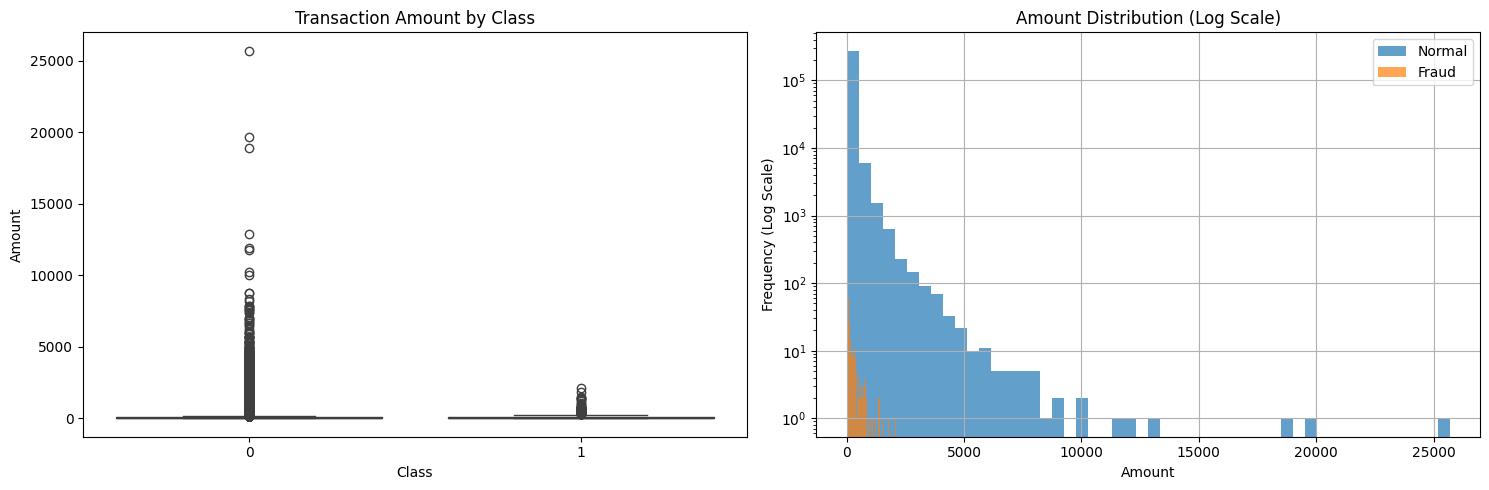


Amount statistics by class:
          count        mean         std  min   25%    50%     75%       max
Class                                                                      
0      283253.0   88.413575  250.379023  0.0  5.67  22.00   77.46  25691.16
1         473.0  123.871860  260.211041  0.0  1.00   9.82  105.89   2125.87


In [ ]:
# KEEP
# Distribution of Amount by Class
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Box plot
sns.boxplot(data=df, x='Class', y='Amount', ax=axes[0])
axes[0].set_title('Transaction Amount by Class')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Amount')

# Log scale histogram
df[df['Class'] == 0]['Amount'].hist(bins=50, alpha=0.7, label='Normal', ax=axes[1], log=True)
df[df['Class'] == 1]['Amount'].hist(bins=50, alpha=0.7, label='Fraud', ax=axes[1], log=True)
axes[1].set_title('Amount Distribution (Log Scale)')
axes[1].set_xlabel('Amount')
axes[1].set_ylabel('Frequency (Log Scale)')
axes[1].legend()

plt.tight_layout()
plt.show()

# Statistics
print("\nAmount statistics by class:")
print(df.groupby('Class')['Amount'].describe())


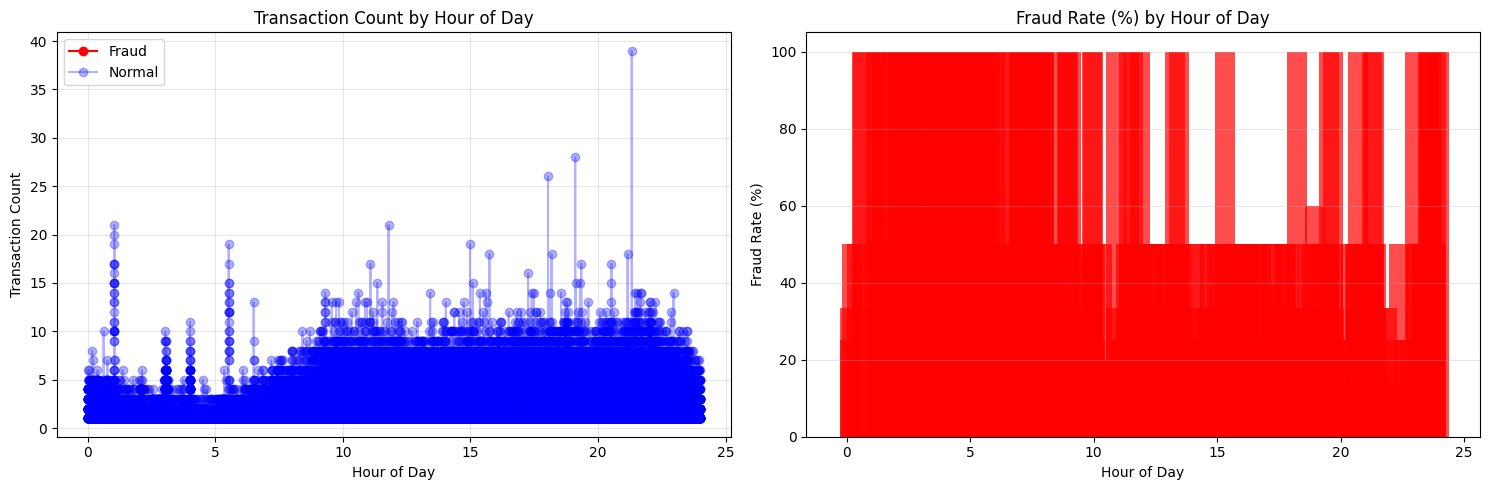

In [ ]:
# KEEP
# Time analysis - convert Time to hours
df['Hour'] = (df['Time'] / 3600) % 24

# Plot fraud distribution over time
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Fraud distribution by hour
fraud_by_hour = df[df['Class'] == 1].groupby('Hour').size()
normal_by_hour = df[df['Class'] == 0].groupby('Hour').size()

axes[0].plot(fraud_by_hour.index, fraud_by_hour.values, marker='o', label='Fraud', color='red')
axes[0].plot(normal_by_hour.index, normal_by_hour.values, marker='o', label='Normal', color='blue', alpha=0.3)
axes[0].set_title('Transaction Count by Hour of Day')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Transaction Count')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Fraud rate by hour
fraud_rate_by_hour = df.groupby('Hour')['Class'].mean() * 100
axes[1].bar(fraud_rate_by_hour.index, fraud_rate_by_hour.values, color='red', alpha=0.7)
axes[1].set_title('Fraud Rate (%) by Hour of Day')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


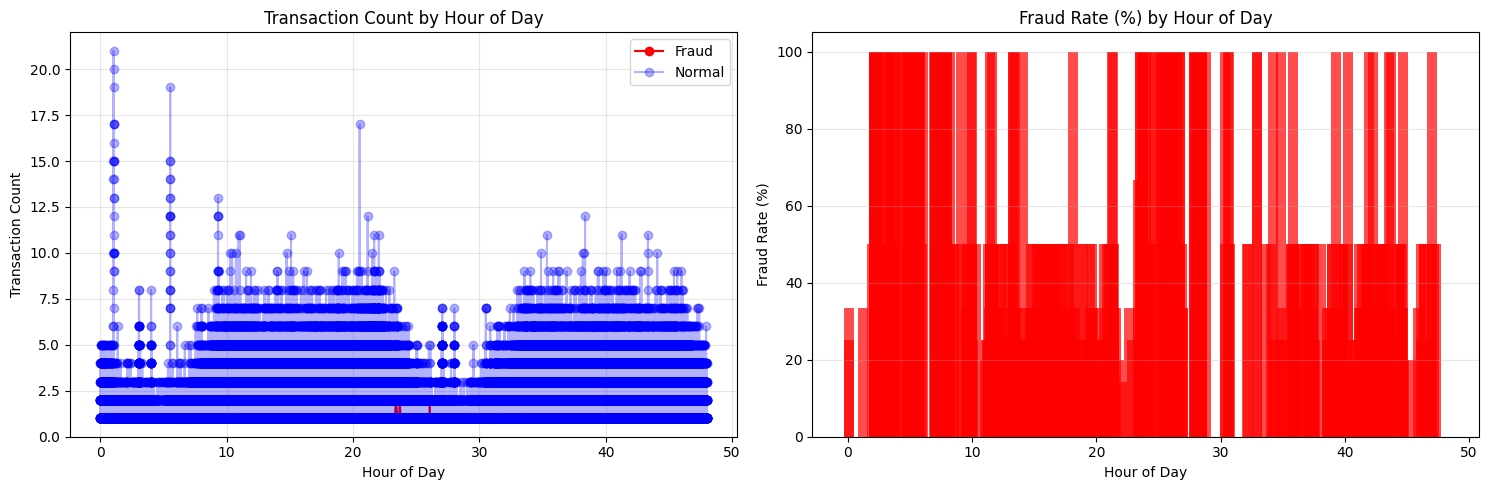

In [47]:
# KEEP
# Time analysis - convert Time to hours
df['Hour'] = (df['Time'] / 3600)

# Plot fraud distribution over time
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Fraud distribution by hour
fraud_by_hour = df[df['Class'] == 1].groupby('Hour').size()
normal_by_hour = df[df['Class'] == 0].groupby('Hour').size()

axes[0].plot(fraud_by_hour.index, fraud_by_hour.values, marker='o', label='Fraud', color='red')
axes[0].plot(normal_by_hour.index, normal_by_hour.values, marker='o', label='Normal', color='blue', alpha=0.3)
axes[0].set_title('Transaction Count by Hour of Day')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Transaction Count')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Fraud rate by hour
fraud_rate_by_hour = df.groupby('Hour')['Class'].mean() * 100
axes[1].bar(fraud_rate_by_hour.index, fraud_rate_by_hour.values, color='red', alpha=0.7)
axes[1].set_title('Fraud Rate (%) by Hour of Day')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

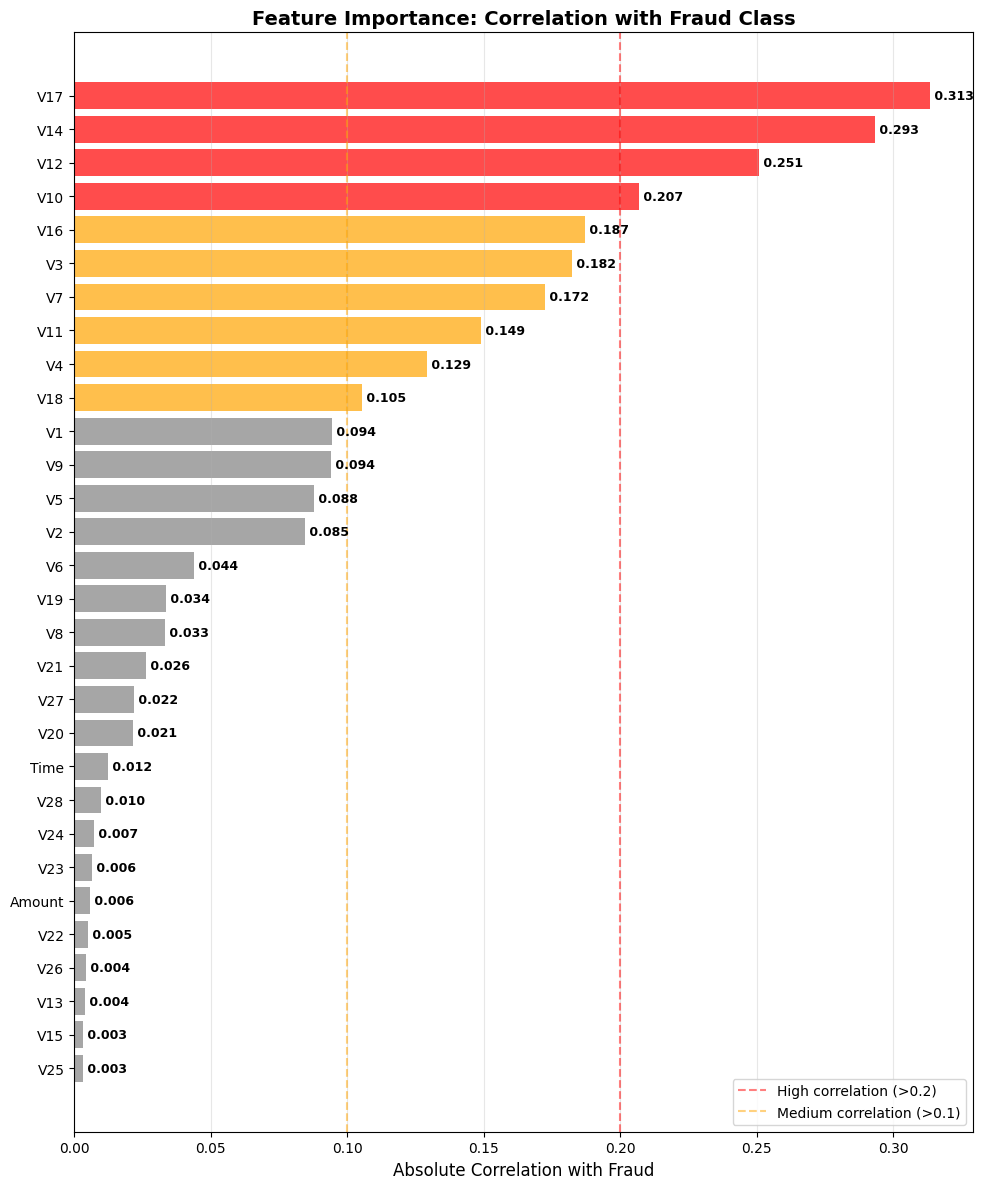


Top 5 Most Important Features for Fraud Detection:
V16    0.187186
V10    0.206971
V12    0.250711
V14    0.293375
V17    0.313498
Name: Class, dtype: float64


In [ ]:
# ============================================================================
# Feature Importance Ranking (Correlation with Fraud)
# ============================================================================

correlations = df.corr()['Class'].drop('Class').abs().sort_values(ascending=True)

plt.figure(figsize=(10, 12))
colors = ['red' if abs(df.corr()['Class'][feat]) > 0.2 else 'orange' if abs(df.corr()['Class'][feat]) > 0.1 else 'gray' 
          for feat in correlations.index]

bars = plt.barh(correlations.index, correlations.values, color=colors, alpha=0.7)
plt.xlabel('Absolute Correlation with Fraud', fontsize=12)
plt.title('Feature Importance: Correlation with Fraud Class', fontsize=14, fontweight='bold')
plt.axvline(x=0.2, color='red', linestyle='--', alpha=0.5, label='High correlation (>0.2)')
plt.axvline(x=0.1, color='orange', linestyle='--', alpha=0.5, label='Medium correlation (>0.1)')
plt.legend()
plt.grid(True, alpha=0.3, axis='x')

# Add value labels
for i, (bar, val) in enumerate(zip(bars, correlations.values)):
    plt.text(val, i, f' {val:.3f}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nTop 5 Most Important Features for Fraud Detection:")
print(correlations.tail(5))

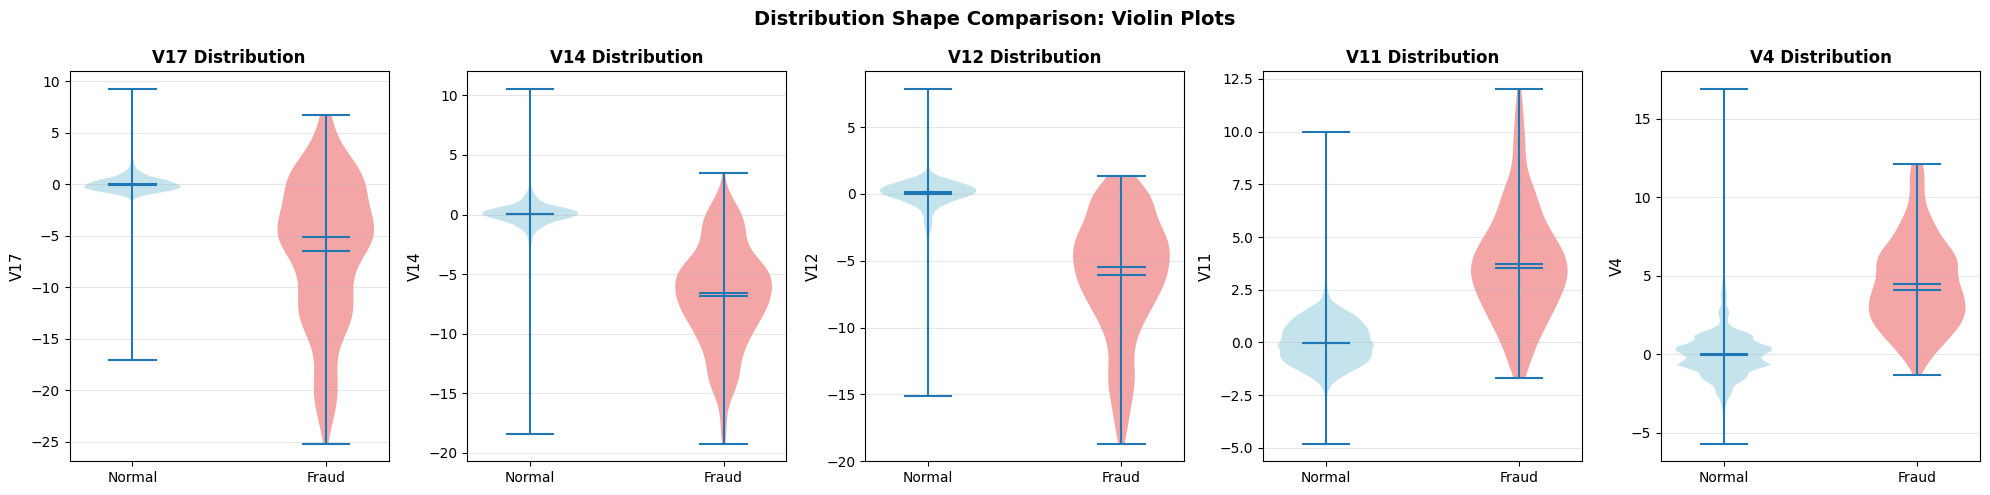

In [ ]:
# ============================================================================
# Violin Plots: Distribution Shape Comparison
# ============================================================================

top_features = ['V17', 'V14', 'V12', 'V11', 'V4']
fig, axes = plt.subplots(1, len(top_features), figsize=(20, 5))

for idx, feature in enumerate(top_features):
    ax = axes[idx]
    
    # Prepare data
    normal_data = df[df['Class'] == 0][feature]
    fraud_data = df[df['Class'] == 1][feature]
    
    # Create violin plot
    parts = ax.violinplot([normal_data, fraud_data], 
                          positions=[0, 1],
                          showmeans=True, showmedians=True)
    
    # Color the violins
    for pc, color in zip(parts['bodies'], ['lightblue', 'lightcoral']):
        pc.set_facecolor(color)
        pc.set_alpha(0.7)
    
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Normal', 'Fraud'])
    ax.set_ylabel(feature, fontsize=11)
    ax.set_title(f'{feature} Distribution', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Distribution Shape Comparison: Violin Plots', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

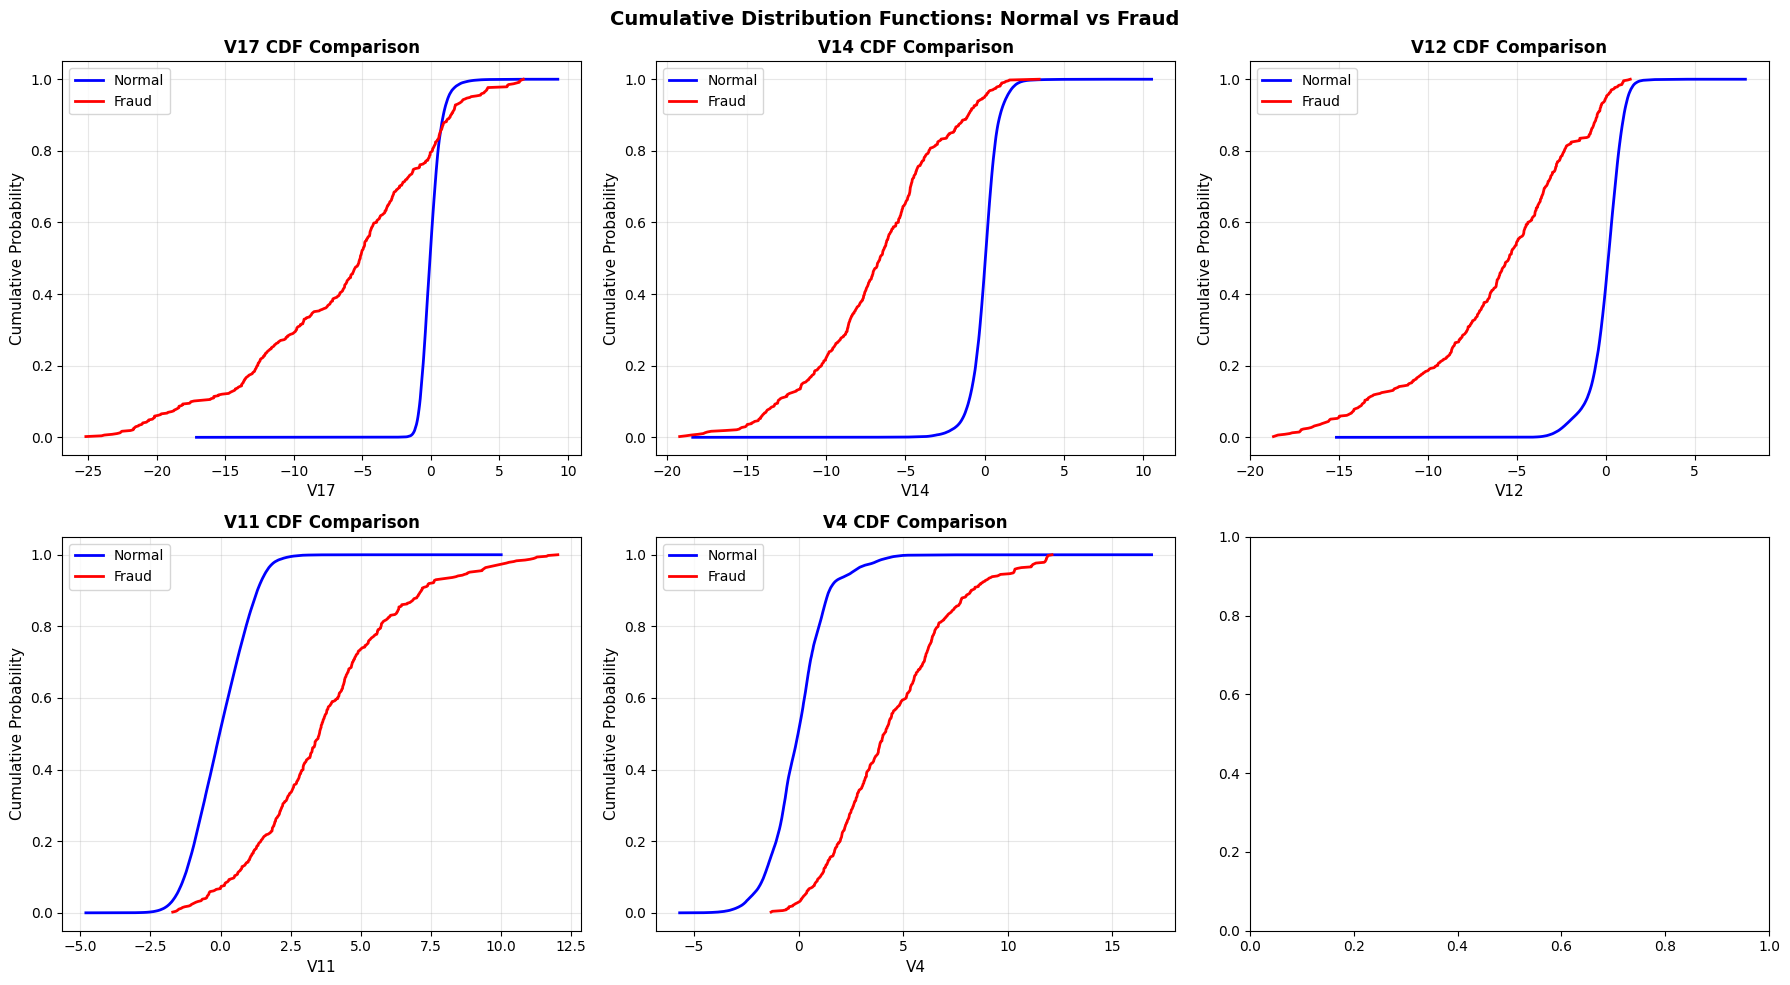

In [ ]:
# ============================================================================
# Cumulative Distribution Function (CDF) Comparison
# ============================================================================

top_features = ['V17', 'V14', 'V12', 'V11', 'V4']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, feature in enumerate(top_features[:6]):  # Top 6 features
    ax = axes[idx]
    
    normal_data = df[df['Class'] == 0][feature].sort_values()
    fraud_data = df[df['Class'] == 1][feature].sort_values()
    
    # Calculate CDF
    normal_cdf = np.arange(1, len(normal_data) + 1) / len(normal_data)
    fraud_cdf = np.arange(1, len(fraud_data) + 1) / len(fraud_data)
    
    ax.plot(normal_data, normal_cdf, label='Normal', color='blue', linewidth=2)
    ax.plot(fraud_data, fraud_cdf, label='Fraud', color='red', linewidth=2)
    
    ax.set_xlabel(feature, fontsize=11)
    ax.set_ylabel('Cumulative Probability', fontsize=11)
    ax.set_title(f'{feature} CDF Comparison', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Cumulative Distribution Functions: Normal vs Fraud', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Class Imbalance Analysis

This section analyzes the class distribution in the dataset, describes the severity of imbalance, visualizes it comprehensively, and discusses the implications for modeling.


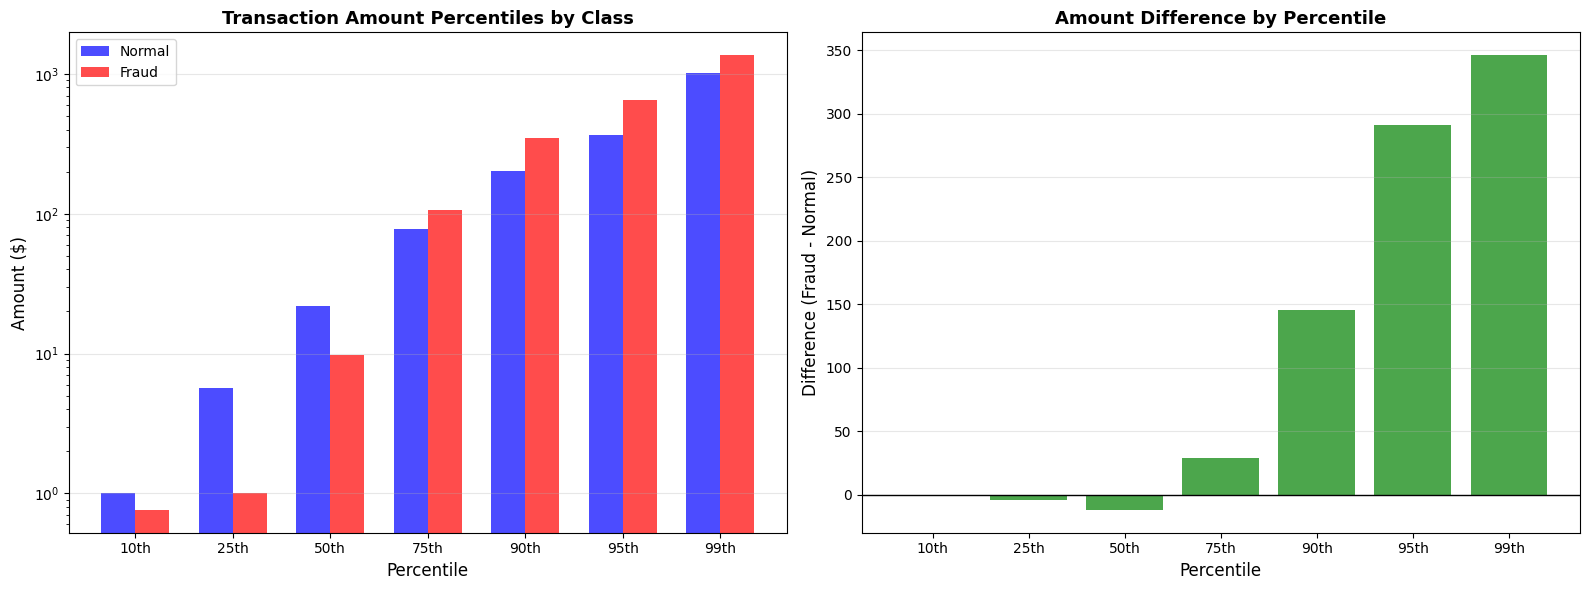


Amount Percentiles Comparison:
Percentile    Normal     Fraud  Difference
      10th    1.0000    0.7600     -0.2400
      25th    5.6700    1.0000     -4.6700
      50th   22.0000    9.8200    -12.1800
      75th   77.4600  105.8900     28.4300
      90th  203.0000  348.6520    145.6520
      95th  365.0000  655.8200    290.8200
      99th 1018.0576 1364.1368    346.0792


In [ ]:
# ============================================================================
# Amount Percentiles Analysis
# ============================================================================

percentiles = [10, 25, 50, 75, 90, 95, 99]
normal_percentiles = [np.percentile(df[df['Class'] == 0]['Amount'], p) for p in percentiles]
fraud_percentiles = [np.percentile(df[df['Class'] == 1]['Amount'], p) for p in percentiles]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Percentile comparison
x_pos = np.arange(len(percentiles))
width = 0.35
axes[0].bar(x_pos - width/2, normal_percentiles, width, label='Normal', 
            color='blue', alpha=0.7)
axes[0].bar(x_pos + width/2, fraud_percentiles, width, label='Fraud', 
            color='red', alpha=0.7)
axes[0].set_xlabel('Percentile', fontsize=12)
axes[0].set_ylabel('Amount ($)', fontsize=12)
axes[0].set_title('Transaction Amount Percentiles by Class', fontsize=13, fontweight='bold')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels([f'{p}th' for p in percentiles])
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].set_yscale('log')

# Percentile difference
percentile_diff = [f - n for f, n in zip(fraud_percentiles, normal_percentiles)]
axes[1].bar(x_pos, percentile_diff, color='green', alpha=0.7)
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=1)
axes[1].set_xlabel('Percentile', fontsize=12)
axes[1].set_ylabel('Difference (Fraud - Normal)', fontsize=12)
axes[1].set_title('Amount Difference by Percentile', fontsize=13, fontweight='bold')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels([f'{p}th' for p in percentiles])
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Summary table
percentile_df = pd.DataFrame({
    'Percentile': [f'{p}th' for p in percentiles],
    'Normal': normal_percentiles,
    'Fraud': fraud_percentiles,
    'Difference': percentile_diff
})
print("\nAmount Percentiles Comparison:")
print(percentile_df.to_string(index=False))

/var/folders/pc/62g2xhyd3nd1zwxk910m87jc0000gn/T/ipykernel_50831/1569429975.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(fraud_by_day_ordered.index, rotation=45, ha='right')
/var/folders/pc/62g2xhyd3nd1zwxk910m87jc0000gn/T/ipykernel_50831/1569429975.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(fraud_by_day_ordered.index, rotation=45, ha='right')


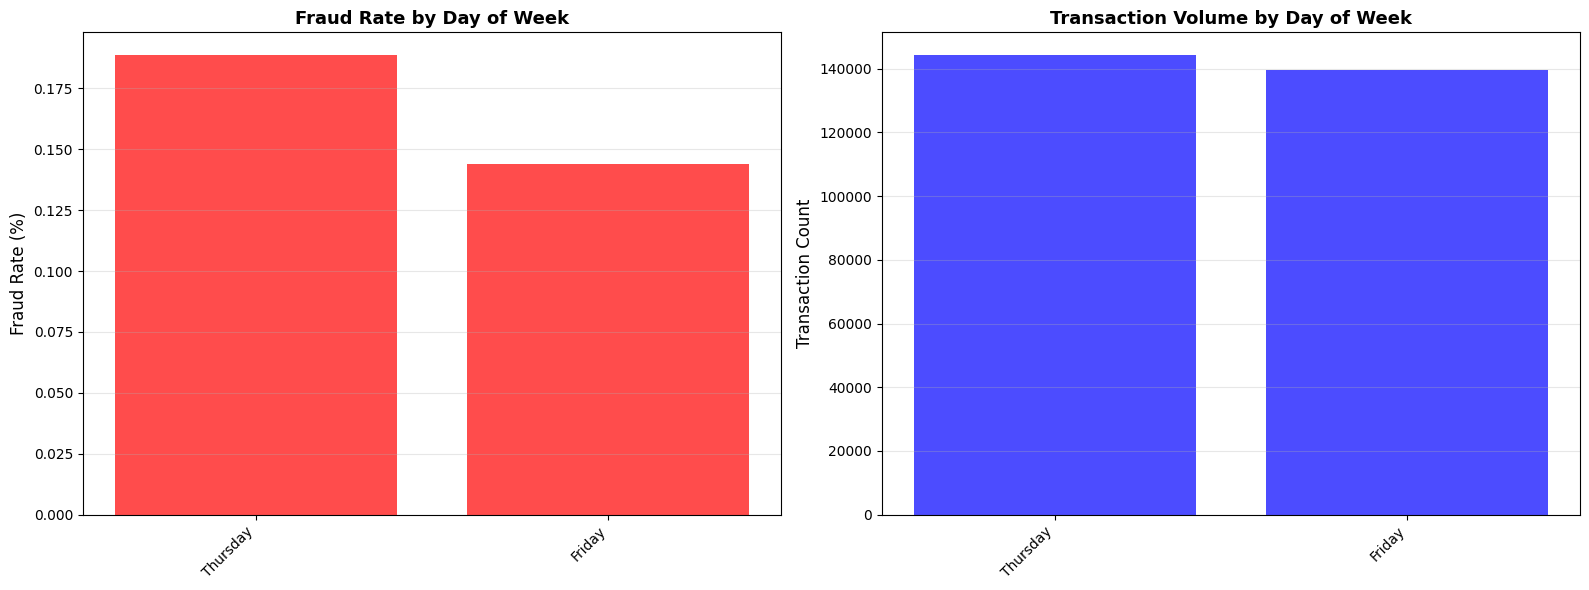

In [ ]:
# ============================================================================
# Temporal Patterns: Day of Week Analysis
# ============================================================================

# Convert Time to datetime (assuming Time is seconds from first transaction)
# You may need to adjust based on your Time column format
df['DayOfWeek'] = pd.to_datetime(df['Time'], unit='s').dt.day_name()

# Fraud rate by day of week
fraud_by_day = df.groupby('DayOfWeek')['Class'].agg(['count', 'sum', 'mean'])
fraud_by_day['fraud_rate'] = fraud_by_day['mean'] * 100
fraud_by_day = fraud_by_day.sort_values('fraud_rate', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Fraud rate by day
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
fraud_by_day_ordered = fraud_by_day.reindex([d for d in day_order if d in fraud_by_day.index])

axes[0].bar(fraud_by_day_ordered.index, fraud_by_day_ordered['fraud_rate'], 
            color='red', alpha=0.7)
axes[0].set_ylabel('Fraud Rate (%)', fontsize=12)
axes[0].set_title('Fraud Rate by Day of Week', fontsize=13, fontweight='bold')
axes[0].set_xticklabels(fraud_by_day_ordered.index, rotation=45, ha='right')
axes[0].grid(True, alpha=0.3, axis='y')

# Transaction volume by day
axes[1].bar(fraud_by_day_ordered.index, fraud_by_day_ordered['count'], 
            color='blue', alpha=0.7)
axes[1].set_ylabel('Transaction Count', fontsize=12)
axes[1].set_title('Transaction Volume by Day of Week', fontsize=13, fontweight='bold')
axes[1].set_xticklabels(fraud_by_day_ordered.index, rotation=45, ha='right')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

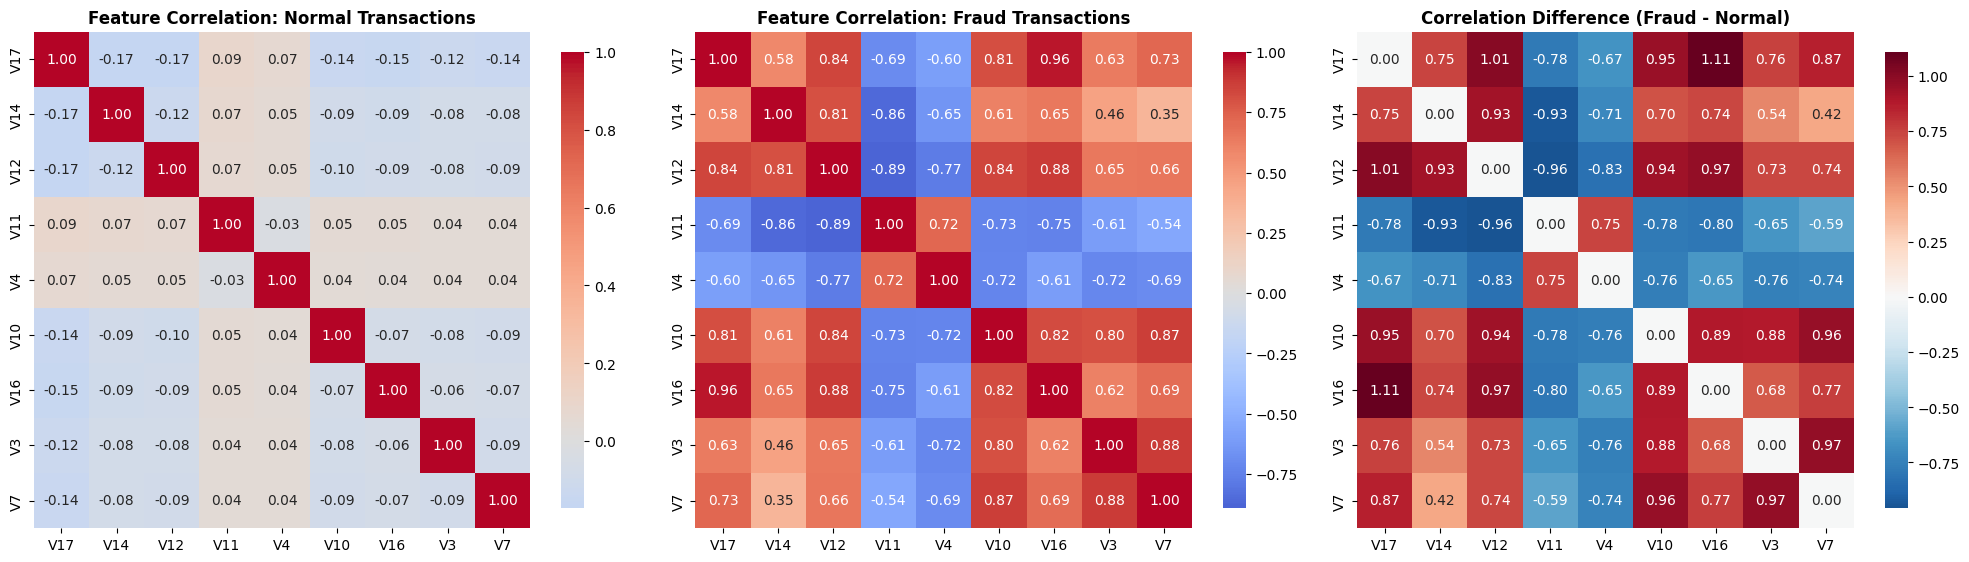

In [ ]:
# ============================================================================
# Feature Interaction Analysis
# ============================================================================

# Select top correlated features
top_features = ['V17', 'V14', 'V12', 'V11', 'V4', 'V10', 'V16', 'V3', 'V7']

# Calculate interaction: correlation between features for fraud vs normal
normal_corr = df[df['Class'] == 0][top_features].corr()
fraud_corr = df[df['Class'] == 1][top_features].corr()
interaction_diff = fraud_corr - normal_corr

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Normal transactions correlation
sns.heatmap(normal_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, ax=axes[0], cbar_kws={"shrink": 0.8})
axes[0].set_title('Feature Correlation: Normal Transactions', fontsize=12, fontweight='bold')

# Fraud transactions correlation
sns.heatmap(fraud_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, ax=axes[1], cbar_kws={"shrink": 0.8})
axes[1].set_title('Feature Correlation: Fraud Transactions', fontsize=12, fontweight='bold')

# Difference (shows how relationships change)
sns.heatmap(interaction_diff, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, ax=axes[2], cbar_kws={"shrink": 0.8})
axes[2].set_title('Correlation Difference (Fraud - Normal)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

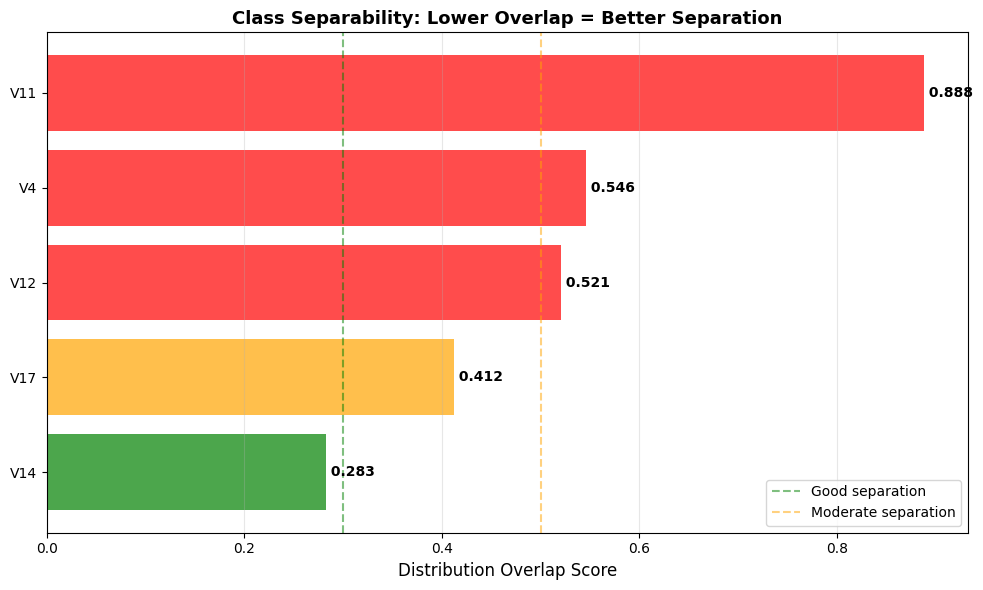


Class Separability Analysis:
Lower overlap = better feature for distinguishing fraud
Feature  Overlap_Score
    V14       0.283001
    V17       0.411962
    V12       0.520805
     V4       0.546128
    V11       0.888167


In [ ]:
# ============================================================================
# Class Separability Analysis
# ============================================================================

top_features = ['V17', 'V14', 'V12', 'V11', 'V4']
overlap_scores = []

for feature in top_features:
    normal_data = df[df['Class'] == 0][feature]
    fraud_data = df[df['Class'] == 1][feature]
    
    # Calculate overlap using histogram intersection
    hist_normal, bins = np.histogram(normal_data, bins=50, density=True)
    hist_fraud, _ = np.histogram(fraud_data, bins=bins, density=True)
    
    # Histogram intersection (overlap measure)
    overlap = np.minimum(hist_normal, hist_fraud).sum()
    overlap_scores.append(overlap)

overlap_df = pd.DataFrame({
    'Feature': top_features,
    'Overlap_Score': overlap_scores
}).sort_values('Overlap_Score')

plt.figure(figsize=(10, 6))
bars = plt.barh(overlap_df['Feature'], overlap_df['Overlap_Score'], 
                color=['green' if s < 0.3 else 'orange' if s < 0.5 else 'red' 
                      for s in overlap_df['Overlap_Score']], alpha=0.7)
plt.xlabel('Distribution Overlap Score', fontsize=12)
plt.title('Class Separability: Lower Overlap = Better Separation', fontsize=13, fontweight='bold')
plt.axvline(x=0.3, color='green', linestyle='--', alpha=0.5, label='Good separation')
plt.axvline(x=0.5, color='orange', linestyle='--', alpha=0.5, label='Moderate separation')
plt.legend()
plt.grid(True, alpha=0.3, axis='x')

for bar, score in zip(bars, overlap_df['Overlap_Score']):
    plt.text(score, bar.get_y() + bar.get_height()/2, 
             f' {score:.3f}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nClass Separability Analysis:")
print("Lower overlap = better feature for distinguishing fraud")
print(overlap_df.to_string(index=False))

In [19]:
# Save cleaned dataset for use in feature engineering notebook
import os

# Create data directory if it doesn't exist
os.makedirs('../data/processed', exist_ok=True)

# Save cleaned dataframe
df.to_csv('../data/processed/creditcard_cleaned.csv', index=False)

print(f"Cleaned dataset saved successfully!")
print(f"Shape: {df.shape}")
print(f"Class distribution:")
print(df['Class'].value_counts())
print(f"\nFile saved to: ../data/processed/creditcard_cleaned.csv")

Cleaned dataset saved successfully!
Shape: (284807, 31)
Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

File saved to: ../data/processed/creditcard_cleaned.csv


# 5. Original Pipeline (Preprocessing)

## Train/Test Split

In [22]:
# Separate features and target
X = df.drop('Class', axis=1)
y = df['Class']

print(f"Feature matrix shape: {X.shape}")
print(f"Target distribution:")
print(y.value_counts())
print(f"\nFeatures: {list(X.columns)}")

Feature matrix shape: (283726, 30)
Target distribution:
Class
0    283253
1       473
Name: count, dtype: int64

Features: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']


In [23]:
# Train/Test Split
# Split into train and test sets (stratified to maintain class distribution)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"\nTraining set class distribution:")
print(y_train.value_counts())
print(f"  Fraud rate: {y_train.mean() * 100:.2f}%")

print(f"\nTest set class distribution:")
print(y_test.value_counts())
print(f"  Fraud rate: {y_test.mean() * 100:.2f}%")

print(f"\n✓ Split completed successfully!")
print(f"  Training samples: {len(X_train):,}")
print(f"  Test samples: {len(X_test):,}")


Training set shape: (226980, 30)
Test set shape: (56746, 30)

Training set class distribution:
Class
0    226602
1       378
Name: count, dtype: int64
  Fraud rate: 0.17%

Test set class distribution:
Class
0    56651
1       95
Name: count, dtype: int64
  Fraud rate: 0.17%

✓ Split completed successfully!
  Training samples: 226,980
  Test samples: 56,746


## 5.2 Scaling Comparison: StandardScaler vs RobustScaler

We'll compare both scalers to determine which performs better for our fraud detection task.



In [24]:
# Scaling Comparison: No Scaling vs StandardScaler vs RobustScaler
# Note: V1-V28 are already PCA components (standardized), only Time & Amount need scaling

# Features to scale
features_to_scale = ['Time', 'Amount']

# Option 1: No Scaling (baseline)
X_train_no_scale = X_train.copy()
X_test_no_scale = X_test.copy()

# Option 2: StandardScaler (only Time & Amount)
standard_scaler = StandardScaler()
X_train_std = X_train.copy()
X_test_std = X_test.copy()

X_train_std[features_to_scale] = standard_scaler.fit_transform(X_train[features_to_scale])
X_test_std[features_to_scale] = standard_scaler.transform(X_test[features_to_scale])

# Option 3: RobustScaler (only Time & Amount)
robust_scaler = RobustScaler()
X_train_rob = X_train.copy()
X_test_rob = X_test.copy()

X_train_rob[features_to_scale] = robust_scaler.fit_transform(X_train[features_to_scale])
X_test_rob[features_to_scale] = robust_scaler.transform(X_test[features_to_scale])

# Verification
print("="*70)
print("SCALING COMPARISON: Three Options Created")
print("="*70)
print(f"\n✓ V1-V28: Kept as-is (already standardized PCA components)")
print(f"✓ Only Time and Amount are scaled in Options 2 & 3\n")

print("Option 1: No Scaling")
print(f"  Time:   Mean={X_train_no_scale['Time'].mean():.2f},   Std={X_train_no_scale['Time'].std():.2f}")
print(f"  Amount: Mean={X_train_no_scale['Amount'].mean():.2f}, Std={X_train_no_scale['Amount'].std():.2f}")

print("\nOption 2: StandardScaler (Time & Amount)")
print(f"  Time:   Mean={X_train_std['Time'].mean():.6f},   Std={X_train_std['Time'].std():.6f}")
print(f"  Amount: Mean={X_train_std['Amount'].mean():.6f}, Std={X_train_std['Amount'].std():.6f}")

print("\nOption 3: RobustScaler (Time & Amount)")
print(f"  Time:   Median={X_train_rob['Time'].median():.6f},   IQR-based")
print(f"  Amount: Median={X_train_rob['Amount'].median():.6f}, IQR-based")
print("="*70)

SCALING COMPARISON: Three Options Created

✓ V1-V28: Kept as-is (already standardized PCA components)
✓ Only Time and Amount are scaled in Options 2 & 3

Option 1: No Scaling
  Time:   Mean=94900.22,   Std=47488.21
  Amount: Mean=88.39, Std=245.77

Option 2: StandardScaler (Time & Amount)
  Time:   Mean=-0.000000,   Std=1.000002
  Amount: Mean=0.000000, Std=1.000002

Option 3: RobustScaler (Time & Amount)
  Time:   Median=0.000000,   IQR-based
  Amount: Median=0.000000, IQR-based


### 5.2.1 Compare Scalers Using Logistic Regression

We'll use Logistic Regression as a baseline to compare scaler performance.



In [25]:
# Quick scaling comparison with Logistic Regression only
scaling_results = {}

# Test each scaling option
scaling_options = {
    'No Scaling': (X_train_no_scale, X_test_no_scale),
    'StandardScaler': (X_train_std, X_test_std),
    'RobustScaler': (X_train_rob, X_test_rob)
}

for name, (X_tr, X_te) in scaling_options.items():
    model = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
    model.fit(X_tr, y_train)
    
    y_proba = model.predict_proba(X_te)[:, 1]
    
    roc_auc = roc_auc_score(y_test, y_proba)
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = auc(recall, precision)
    
    scaling_results[name] = {
        'ROC-AUC': roc_auc,
        'PR-AUC': pr_auc
    }
    
# Display results
results_df = pd.DataFrame(scaling_results).T
print("Scaling Comparison Results:")
print(results_df.sort_values('PR-AUC', ascending=False))

Scaling Comparison Results:
                 ROC-AUC    PR-AUC
StandardScaler  0.965839  0.704636
RobustScaler    0.965710  0.704634
No Scaling      0.961637  0.682819


In [27]:
# Train Logistic Regression with No Scaling
lr_no_scale = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)
lr_no_scale.fit(X_train_no_scale, y_train)
y_pred_proba_no_scale = lr_no_scale.predict_proba(X_test_no_scale)[:, 1]
roc_auc_no_scale = roc_auc_score(y_test, y_pred_proba_no_scale)
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba_no_scale)
pr_auc_no_scale = auc(recall, precision)

# Train Logistic Regression with StandardScaler (selective scaling)
lr_standard = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)
lr_standard.fit(X_train_std, y_train)
y_pred_proba_standard = lr_standard.predict_proba(X_test_std)[:, 1]
roc_auc_standard = roc_auc_score(y_test, y_pred_proba_standard)
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba_standard)
pr_auc_standard = auc(recall, precision)

# Train Logistic Regression with RobustScaler (selective scaling)
lr_robust = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)
lr_robust.fit(X_train_rob, y_train)
y_pred_proba_robust = lr_robust.predict_proba(X_test_rob)[:, 1]
roc_auc_robust = roc_auc_score(y_test, y_pred_proba_robust)
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba_robust)
pr_auc_robust = auc(recall, precision)

# Compare results
print("="*70)
print("SCALER COMPARISON RESULTS (Selective Scaling: Time & Amount Only)")
print("="*70)
print(f"\nNo Scaling (Time & Amount as-is):")
print(f"  ROC-AUC Score: {roc_auc_no_scale:.4f}")
print(f"  PR-AUC Score: {pr_auc_no_scale:.4f}")

print(f"\nStandardScaler (Time & Amount scaled):")
print(f"  ROC-AUC Score: {roc_auc_standard:.4f}")
print(f"  PR-AUC Score: {pr_auc_standard:.4f}")


print(f"\nRobustScaler (Time & Amount scaled):")
print(f"  ROC-AUC Score: {roc_auc_robust:.4f}")
print(f"  PR-AUC Score: {pr_auc_robust:.4f}")

SCALER COMPARISON RESULTS (Selective Scaling: Time & Amount Only)

No Scaling (Time & Amount as-is):
  ROC-AUC Score: 0.9616
  PR-AUC Score: 0.6828

StandardScaler (Time & Amount scaled):
  ROC-AUC Score: 0.9658
  PR-AUC Score: 0.7046

RobustScaler (Time & Amount scaled):
  ROC-AUC Score: 0.9657
  PR-AUC Score: 0.7046


Will use StandardScaler

## 5.3 Resampling

Going to test to see the differences in 
- Random Under Sampling (RUS)
- Random Over Sampling (ROS) 
- SMOTE

### Unused

In [ ]:
# Method 1: Calculate class weights for use in models that support it
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = dict(zip(np.unique(y_train), class_weights))
print("Class weights (balanced):")
print(f"Class 0 (Normal): {class_weight_dict[0]:.4f}")
print(f"Class 1 (Fraud): {class_weight_dict[1]:.4f}")
print(f"\nThis means fraud samples will be weighted {class_weight_dict[1]/class_weight_dict[0]:.2f}x more than normal samples")


Class weights (balanced):
Class 0 (Normal): 0.5008
Class 1 (Fraud): 300.2381

This means fraud samples will be weighted 599.48x more than normal samples


### Used

In [28]:
# ============================================================================
# Resampling Methods: Apply All Strategies
# ============================================================================
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

print("="*70)
print("RESAMPLING METHODS: Applying All Strategies")
print("="*70)
print(f"\nOriginal training set:")
print(f"  Shape: {X_train_best.shape}")
print(f"  Distribution: {Counter(y_train)}")
print(f"  Imbalance ratio: {Counter(y_train)[0] / Counter(y_train)[1]:.1f}:1\n")

# Method 1: No Resampling (Baseline)
X_train_none = X_train_best.copy()
y_train_none = y_train.copy()
print("Method 1: No Resampling (Baseline)")
print(f"  Distribution: {Counter(y_train_none)}\n")

# Method 2: Random Under Sampling
rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train_best.copy(), y_train.copy())
print("Method 2: Random Under Sampling (RUS)")
print(f"  Shape: {X_train_rus.shape}")
print(f"  Distribution: {Counter(y_train_rus)}")
print(f"  Samples removed: {len(y_train) - len(y_train_rus):,}\n")

# Method 3: Random Over Sampling
ros = RandomOverSampler(random_state=42)
X_train_ros, y_train_ros = ros.fit_resample(X_train_best.copy(), y_train.copy())
print("Method 3: Random Over Sampling (ROS)")
print(f"  Shape: {X_train_ros.shape}")
print(f"  Distribution: {Counter(y_train_ros)}")
print(f"  Samples added: {len(y_train_ros) - len(y_train):,}\n")

# Method 4: SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_best.copy(), y_train.copy())
print("Method 4: SMOTE")
print(f"  Shape: {X_train_smote.shape}")
print(f"  Distribution: {Counter(y_train_smote)}")
print(f"  Samples added: {len(y_train_smote) - len(y_train):,}")
print("="*70)

# Store all resampled datasets
resampled_datasets = {
    'No Resampling': (X_train_none, y_train_none),
    'RUS': (X_train_rus, y_train_rus),
    'ROS': (X_train_ros, y_train_ros),
    'SMOTE': (X_train_smote, y_train_smote)
}

RESAMPLING METHODS: Applying All Strategies

Original training set:
  Shape: (226980, 30)
  Distribution: Counter({0: 226602, 1: 378})
  Imbalance ratio: 599.5:1

Method 1: No Resampling (Baseline)
  Distribution: Counter({0: 226602, 1: 378})

Method 2: Random Under Sampling (RUS)
  Shape: (756, 30)
  Distribution: Counter({0: 378, 1: 378})
  Samples removed: 226,224

Method 3: Random Over Sampling (ROS)
  Shape: (453204, 30)
  Distribution: Counter({0: 226602, 1: 226602})
  Samples added: 226,224

Method 4: SMOTE
  Shape: (453204, 30)
  Distribution: Counter({0: 226602, 1: 226602})
  Samples added: 226,224


In [61]:
# Cell 1: Setup - Use Best Scaling (RobustScaler)

# Use Robust scaling since it performed best
X_train_best = X_train_rob.copy()
X_test_best = X_test_rob.copy()

print(f"Training set shape: {X_train_best.shape}")
print(f"Test set shape: {X_test_best.shape}")
print(f"Original class distribution: {Counter(y_train)}")
print(f"Imbalance ratio: {Counter(y_train)[0] / Counter(y_train)[1]:.1f}:1")

Training set shape: (226980, 30)
Test set shape: (56746, 30)
Original class distribution: Counter({0: 226602, 1: 378})
Imbalance ratio: 599.5:1


##### Old Variations of similar things

In [ ]:
# ============================================================================
# Resampling Comparison (More Detailed)
# ============================================================================
from sklearn.metrics import (
    roc_auc_score, precision_recall_curve, auc,
    precision_score, recall_score, f1_score, classification_report
)
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from sklearn.ensemble import RandomForestClassifier

# Resampling strategies
resampling_methods = {
    'No Resampling': (X_train_best, y_train),
    'RandomOverSampler': RandomOverSampler(random_state=42),
    'RandomUnderSampler': RandomUnderSampler(random_state=42),
    'SMOTE': SMOTE(random_state=42)
}

resampling_results = {}

# Use 2-3 models for comparison
models_to_test = {
    'LogisticRegression': LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'),
    'RandomForest': RandomForestClassifier(random_state=42, n_estimators=100, class_weight='balanced')
}

for resample_name, resampler in resampling_methods.items():
    if resample_name == 'No Resampling':
        X_resampled, y_resampled = X_train_best, y_train
    else:
        X_resampled, y_resampled = resampler.fit_resample(X_train_best, y_train)
    
    resampling_results[resample_name] = {}
    
    for model_name, model in models_to_test.items():
        model.fit(X_resampled, y_resampled)
        y_pred = model.predict(X_test_best)
        y_proba = model.predict_proba(X_test_best)[:, 1]
        precision, recall, _ = precision_recall_curve(y_test, y_proba)
        
        resampling_results[resample_name][model_name] = {
            'ROC-AUC': roc_auc_score(y_test, y_proba),
            'PR-AUC': auc(recall, precision),
            'Precision': precision_score(y_test, y_pred),
            'Recall': recall_score(y_test, y_pred),
            'F1-Score': f1_score(y_test, y_pred)
        }

# Display results
print("="*70)
print("RESAMPLING COMPARISON RESULTS")
print("="*70)
for resample_name, model_results in resampling_results.items():
    print(f"\n{resample_name}:")
    for model_name, metrics in model_results.items():
        print(f"  {model_name}:")
        print(f"    ROC-AUC: {metrics['ROC-AUC']:.4f}, PR-AUC: {metrics['PR-AUC']:.4f}")
        print(f"    Precision: {metrics['Precision']:.4f}, Recall: {metrics['Recall']:.4f}, F1: {metrics['F1-Score']:.4f}")

# Select best resampling + model combination
# (You can sort by PR-AUC or create a composite score)

ValueError: x is neither increasing nor decreasing : [0.00167413 0.00167416 0.00167419 ... 0.8        0.79487179 1.        ].

In [64]:
# Use best scaling (let's say X_train_best, X_test_best)
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

# Resampling strategies
resampling_strategies = {
    'No Resampling': (X_train_best, y_train),
    'RandomOverSampler': None,  # Will apply later
    'RandomUnderSampler': None,
    'SMOTE': None
}

# Apply resampling
X_resampled = {}
y_resampled = {}

X_resampled['No Resampling'], y_resampled['No Resampling'] = X_train_best, y_train
X_resampled['RandomOverSampler'], y_resampled['RandomOverSampler'] = RandomOverSampler(random_state=42).fit_resample(X_train_best, y_train)
X_resampled['RandomUnderSampler'], y_resampled['RandomUnderSampler'] = RandomUnderSampler(random_state=42).fit_resample(X_train_best, y_train)
X_resampled['SMOTE'], y_resampled['SMOTE'] = SMOTE(random_state=42).fit_resample(X_train_best, y_train)

# Test with 2-3 diverse models
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

resampling_results = {}

models_to_test = {
    'LogisticRegression': LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'),
    'RandomForest': RandomForestClassifier(random_state=42, n_estimators=100, class_weight='balanced'),
    'XGBoost': xgb(random_state=42, eval_metric='logloss', scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum())
}

for resample_name, (X_tr, y_tr) in resampling_strategies.items():
    resampling_results[resample_name] = {}
    for model_name, model in models_to_test.items():
        model.fit(X_tr, y_tr)
        y_proba = model.predict_proba(X_test_best)[:, 1]
        resampling_results[resample_name][model_name] = {
            'ROC-AUC': roc_auc_score(y_test, y_proba),
            'PR-AUC': auc(*precision_recall_curve(y_test, y_proba)[:2])
        }

# Analyze results
resampling_df = pd.DataFrame(resampling_results).T
print("Resampling Comparison Results:")
print(resampling_df)

ModuleNotFoundError: No module named 'xgboost'

In [ ]:
# ============================================================================
# Apply Different Sampling Methods (Original Data Unchanged)
# ============================================================================

# Store original distribution
original_dist = Counter(y_train)
print("\nOriginal Training Set Distribution:")
print(f"  Class 0 (Normal): {original_dist[0]:,}")
print(f"  Class 1 (Fraud): {original_dist[1]:,}")
print(f"  Total: {len(y_train):,}")
print(f"  Imbalance Ratio: {original_dist[0] / original_dist[1]:.1f}:1")

# Method 1: Random Under Sampling
print("\n" + "="*70)
print("METHOD 1: Random Under Sampling (RUS)")
print("="*70)

rus = RandomUnderSampler(random_state=42, sampling_strategy='auto')
X_train_rus, y_train_rus = rus.fit_resample(X_train_best.copy(), y_train.copy())

rus_dist = Counter(y_train_rus)
print(f"After RUS:")
print(f"  Class 0 (Normal): {rus_dist[0]:,}")
print(f"  Class 1 (Fraud): {rus_dist[1]:,}")
print(f"  Total: {len(y_train_rus):,}")
print(f"  Samples removed: {len(y_train) - len(y_train_rus):,}")
print(f"  Data loss: {((len(y_train) - len(y_train_rus)) / len(y_train)) * 100:.2f}%")

# Method 2: Random Over Sampling
print("\n" + "="*70)
print("METHOD 2: Random Over Sampling (ROS)")
print("="*70)

ros = RandomOverSampler(random_state=42, sampling_strategy='auto')
X_train_ros, y_train_ros = ros.fit_resample(X_train.copy(), y_train.copy())

ros_dist = Counter(y_train_ros)
print(f"After ROS:")
print(f"  Class 0 (Normal): {ros_dist[0]:,}")
print(f"  Class 1 (Fraud): {ros_dist[1]:,}")
print(f"  Total: {len(y_train_ros):,}")
print(f"  Samples added: {len(y_train_ros) - len(y_train):,}")
print(f"  Data increase: {((len(y_train_ros) - len(y_train)) / len(y_train)) * 100:.2f}%")

# Method 3: SMOTE
print("\n" + "="*70)
print("METHOD 3: SMOTE (Synthetic Minority Oversampling)")
print("="*70)

smote = SMOTE(random_state=42, sampling_strategy='auto')
X_train_smote, y_train_smote = smote.fit_resample(X_train.copy(), y_train.copy())

smote_dist = Counter(y_train_smote)
print(f"After SMOTE:")
print(f"  Class 0 (Normal): {smote_dist[0]:,}")
print(f"  Class 1 (Fraud): {smote_dist[1]:,}")
print(f"  Total: {len(y_train_smote):,}")
print(f"  Samples added: {len(y_train_smote) - len(y_train):,}")
print(f"  Data increase: {((len(y_train_smote) - len(y_train)) / len(y_train)) * 100:.2f}%")

# Verify original data is unchanged
print("\n" + "="*70)
print("VERIFICATION: Original Data Unchanged")
print("="*70)
print(f"Original X_train shape: {X_train.shape}")
print(f"Original y_train distribution: {Counter(y_train)}")
print("✓ Original training data remains intact!")


Original Training Set Distribution:
  Class 0 (Normal): 226,602
  Class 1 (Fraud): 378
  Total: 226,980
  Imbalance Ratio: 599.5:1

METHOD 1: Random Under Sampling (RUS)
After RUS:
  Class 0 (Normal): 378
  Class 1 (Fraud): 378
  Total: 756
  Samples removed: 226,224
  Data loss: 99.67%

METHOD 2: Random Over Sampling (ROS)
After ROS:
  Class 0 (Normal): 226,602
  Class 1 (Fraud): 226,602
  Total: 453,204
  Samples added: 226,224
  Data increase: 99.67%

METHOD 3: SMOTE (Synthetic Minority Oversampling)
After SMOTE:
  Class 0 (Normal): 226,602
  Class 1 (Fraud): 226,602
  Total: 453,204
  Samples added: 226,224
  Data increase: 99.67%

VERIFICATION: Original Data Unchanged
Original X_train shape: (226980, 30)
Original y_train distribution: Counter({0: 226602, 1: 378})
✓ Original training data remains intact!


In [31]:
# ============================================================================
# Comparison: Class Distribution Before and After
# ============================================================================

# Create comparison DataFrame
comparison_data = {
    'Method': ['Original', 'RUS', 'ROS', 'SMOTE'],
    'Class_0_Count': [original_dist[0], rus_dist[0], ros_dist[0], smote_dist[0]],
    'Class_1_Count': [original_dist[1], rus_dist[1], ros_dist[1], smote_dist[1]],
    'Total_Samples': [len(y_train), len(y_train_rus), len(y_train_ros), len(y_train_smote)],
    'Class_0_Pct': [original_dist[0]/len(y_train)*100, 
                    rus_dist[0]/len(y_train_rus)*100,
                    ros_dist[0]/len(y_train_ros)*100,
                    smote_dist[0]/len(y_train_smote)*100],
    'Class_1_Pct': [original_dist[1]/len(y_train)*100,
                    rus_dist[1]/len(y_train_rus)*100,
                    ros_dist[1]/len(y_train_ros)*100,
                    smote_dist[1]/len(y_train_smote)*100]
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df['Imbalance_Ratio'] = comparison_df['Class_0_Count'] / comparison_df['Class_1_Count']

print("\n" + "="*70)
print("COMPARISON TABLE: Class Distribution by Method")
print("="*70)
print(comparison_df.to_string(index=False))

NameError: name 'original_dist' is not defined

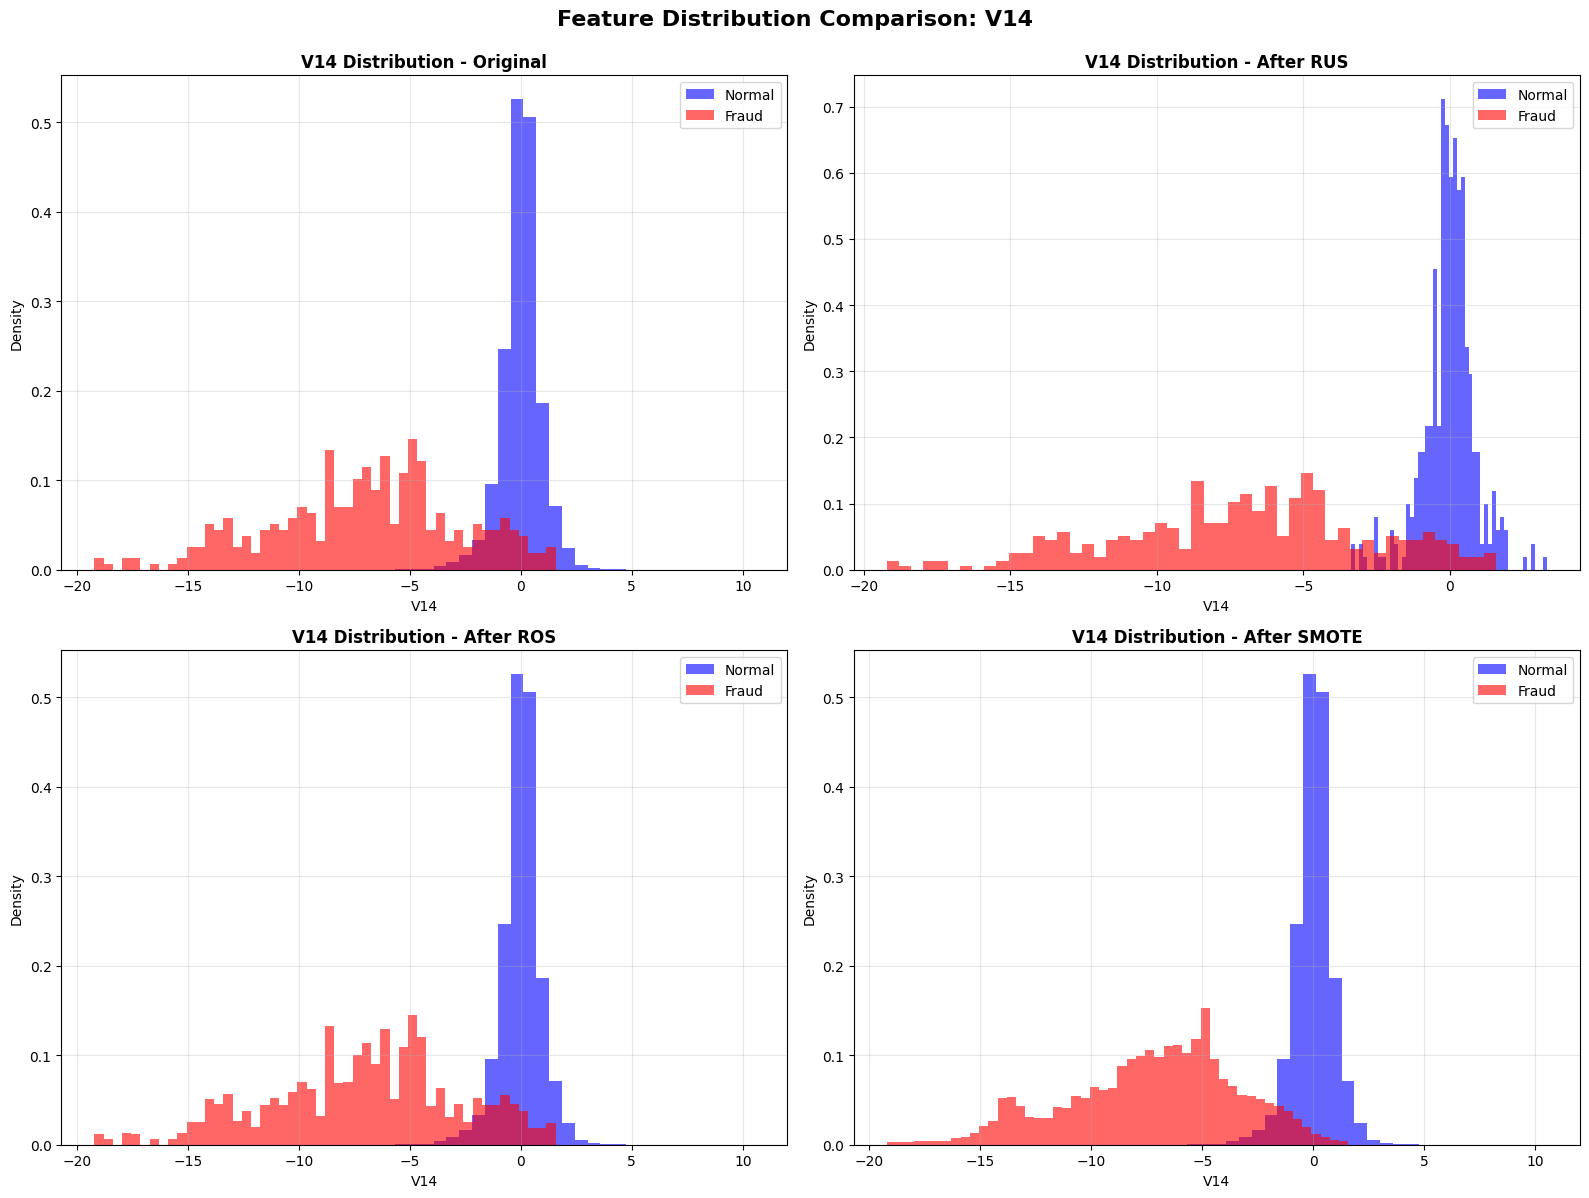

In [ ]:
# ============================================================================
# Visualization: Feature Distribution Comparison (Using Key Feature)
# ============================================================================
# Compare how each method affects the distribution of a key feature (V14)

key_feature = 'V14'  # One of the most correlated features with fraud

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Original data
axes[0, 0].hist(X_train[y_train == 0][key_feature], bins=50, alpha=0.6, 
                label='Normal', color='blue', density=True)
axes[0, 0].hist(X_train[y_train == 1][key_feature], bins=50, alpha=0.6,
                label='Fraud', color='red', density=True)
axes[0, 0].set_title(f'{key_feature} Distribution - Original', fontweight='bold')
axes[0, 0].set_xlabel(key_feature)
axes[0, 0].set_ylabel('Density')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# RUS
axes[0, 1].hist(X_train_rus[y_train_rus == 0][key_feature], bins=50, alpha=0.6,
                label='Normal', color='blue', density=True)
axes[0, 1].hist(X_train_rus[y_train_rus == 1][key_feature], bins=50, alpha=0.6,
                label='Fraud', color='red', density=True)
axes[0, 1].set_title(f'{key_feature} Distribution - After RUS', fontweight='bold')
axes[0, 1].set_xlabel(key_feature)
axes[0, 1].set_ylabel('Density')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# ROS
axes[1, 0].hist(X_train_ros[y_train_ros == 0][key_feature], bins=50, alpha=0.6,
                label='Normal', color='blue', density=True)
axes[1, 0].hist(X_train_ros[y_train_ros == 1][key_feature], bins=50, alpha=0.6,
                label='Fraud', color='red', density=True)
axes[1, 0].set_title(f'{key_feature} Distribution - After ROS', fontweight='bold')
axes[1, 0].set_xlabel(key_feature)
axes[1, 0].set_ylabel('Density')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# SMOTE
axes[1, 1].hist(X_train_smote[y_train_smote == 0][key_feature], bins=50, alpha=0.6,
               label='Normal', color='blue', density=True)
axes[1, 1].hist(X_train_smote[y_train_smote == 1][key_feature], bins=50, alpha=0.6,
               label='Fraud', color='red', density=True)
axes[1, 1].set_title(f'{key_feature} Distribution - After SMOTE', fontweight='bold')
axes[1, 1].set_xlabel(key_feature)
axes[1, 1].set_ylabel('Density')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle(f'Feature Distribution Comparison: {key_feature}', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

### Summary and Recommendations

Based on the comparison:

1. RANDOM UNDER SAMPLING (RUS):
   - Reduced dataset from `{len(y_train):,}` to {len(y_train_rus):,} samples
   - Data loss: {((len(y_train) - len(y_train_rus)) / len(y_train)) * 100:.1f}%
   - Best for: Quick experiments, limited computational resources
   - Trade-off: Significant information loss

2. RANDOM OVER SAMPLING (ROS):
   - Increased dataset from {len(y_train):,} to {len(y_train_ros):,} samples
   - Data increase: {((len(y_train_ros) - len(y_train)) / len(y_train)) * 100:.1f}%
   - Best for: Simple baseline, when computational resources allow
   - Trade-off: Exact duplicates may cause overfitting

3. SMOTE:
   - Increased dataset from {len(y_train):,} to {len(y_train_smote):,} samples
   - Data increase: {((len(y_train_smote) - len(y_train)) / len(y_train)) * 100:.1f}%
   - Best for: Production models, when synthetic data is acceptable
   - Trade-off: Synthetic samples may not perfectly represent real fraud patterns

NEXT STEPS:
- Test each method with your chosen model(s) to see which performs best
- Consider using cross-validation to evaluate performance
- Original data (X_train, y_train) remains available for comparison
- Choose method based on: model performance, computational constraints, and business requirements
""")


In [ ]:
# ============================================================================
# Summary and Recommendations
# ============================================================================

print("\n" + "="*70)
print("SUMMARY AND RECOMMENDATIONS")
print("="*70)
print(f"""
Based on the comparison:

1. RANDOM UNDER SAMPLING (RUS):
   - Reduced dataset from {len(y_train):,} to {len(y_train_rus):,} samples
   - Data loss: {((len(y_train) - len(y_train_rus)) / len(y_train)) * 100:.1f}%
   - Best for: Quick experiments, limited computational resources
   - Trade-off: Significant information loss

2. RANDOM OVER SAMPLING (ROS):
   - Increased dataset from {len(y_train):,} to {len(y_train_ros):,} samples
   - Data increase: {((len(y_train_ros) - len(y_train)) / len(y_train)) * 100:.1f}%
   - Best for: Simple baseline, when computational resources allow
   - Trade-off: Exact duplicates may cause overfitting

3. SMOTE:
   - Increased dataset from {len(y_train):,} to {len(y_train_smote):,} samples
   - Data increase: {((len(y_train_smote) - len(y_train)) / len(y_train)) * 100:.1f}%
   - Best for: Production models, when synthetic data is acceptable
   - Trade-off: Synthetic samples may not perfectly represent real fraud patterns

NEXT STEPS:
- Test each method with your chosen model(s) to see which performs best
- Consider using cross-validation to evaluate performance
- Original data (X_train, y_train) remains available for comparison
- Choose method based on: model performance, computational constraints, and business requirements
""")
print("="*70)


SUMMARY AND RECOMMENDATIONS

Based on the comparison:

1. RANDOM UNDER SAMPLING (RUS):
   - Reduced dataset from 226,980 to 756 samples
   - Data loss: 99.7%
   - Best for: Quick experiments, limited computational resources
   - Trade-off: Significant information loss

2. RANDOM OVER SAMPLING (ROS):
   - Increased dataset from 226,980 to 453,204 samples
   - Data increase: 99.7%
   - Best for: Simple baseline, when computational resources allow
   - Trade-off: Exact duplicates may cause overfitting

3. SMOTE:
   - Increased dataset from 226,980 to 453,204 samples
   - Data increase: 99.7%
   - Best for: Production models, when synthetic data is acceptable
   - Trade-off: Synthetic samples may not perfectly represent real fraud patterns

NEXT STEPS:
- Test each method with your chosen model(s) to see which performs best
- Consider using cross-validation to evaluate performance
- Original data (X_train, y_train) remains available for comparison
- Choose method based on: model performanc

In [ ]:
# Method 2: Apply SMOTE (Synthetic Minority Oversampling Technique)
print("Before SMOTE:")
print(f"Class distribution: {Counter(y_train)}")

# Apply SMOTE
smote = SMOTE(random_state=42, sampling_strategy='auto')
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print(f"Class distribution: {Counter(y_train_smote)}")
print(f"New training set shape: {X_train_smote.shape}")
print(f"Original training set shape: {X_train.shape}")
print(f"Samples added: {X_train_smote.shape[0] - X_train.shape[0]}")


Before SMOTE:
Class distribution: Counter({0: 226602, 1: 378})

After SMOTE:
Class distribution: Counter({0: 226602, 1: 226602})
New training set shape: (453204, 30)
Original training set shape: (226980, 30)
Samples added: 226224


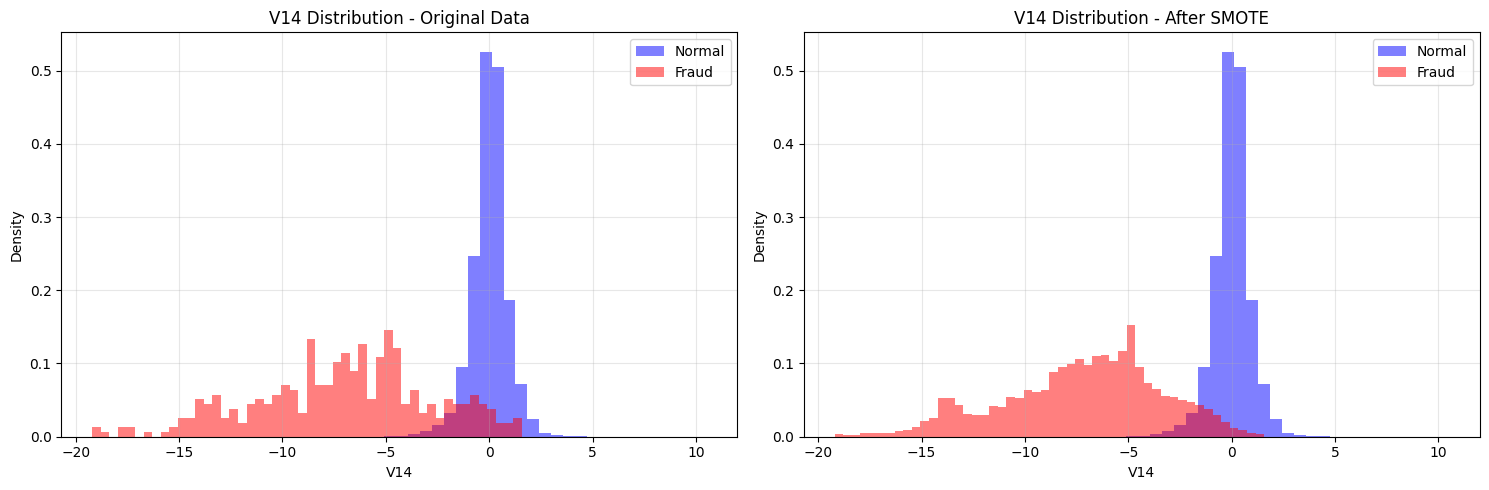

In [ ]:
# Visualize the effect of SMOTE on feature distributions
# Compare original vs SMOTE-augmented data for a key feature
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Original data
axes[0].hist(X_train[y_train == 0]['V14'], bins=50, alpha=0.5, label='Normal', color='blue', density=True)
axes[0].hist(X_train[y_train == 1]['V14'], bins=50, alpha=0.5, label='Fraud', color='red', density=True)
axes[0].set_title('V14 Distribution - Original Data')
axes[0].set_xlabel('V14')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# SMOTE-augmented data
axes[1].hist(X_train_smote[y_train_smote == 0]['V14'], bins=50, alpha=0.5, label='Normal', color='blue', density=True)
axes[1].hist(X_train_smote[y_train_smote == 1]['V14'], bins=50, alpha=0.5, label='Fraud', color='red', density=True)
axes[1].set_title('V14 Distribution - After SMOTE')
axes[1].set_xlabel('V14')
axes[1].set_ylabel('Density')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# 6. Modeling 
- Baseline Models
- Hyperparameter tuning
- Final model selection

In [29]:
# Baseline model evaluation (Logistic Regression, Random Forest, etc.)
# ============================================================================
# Models to Test
# ============================================================================
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Calculate positive class weight for XGBoost
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

models = {
    'LogisticRegression': LogisticRegression(
        random_state=42,
        max_iter=1000,
        class_weight='balanced',
        n_jobs=-1
    ),
    'RandomForest': RandomForestClassifier(
        random_state=42,
        n_estimators=100,
        class_weight='balanced',
        n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        random_state=42,
        eval_metric='logloss',
        scale_pos_weight=pos_weight
    )
}

print("="*70)
print("MODELS TO TEST")
print("="*70)
for name in models.keys():
    print(f"  • {name}")
print("="*70)

MODELS TO TEST
  • LogisticRegression
  • RandomForest
  • XGBoost


In [30]:
# ============================================================================
# Systematic Comparison: Model × Resampling Method
# ============================================================================
from sklearn.metrics import (
    roc_auc_score, precision_recall_curve, auc,
    precision_score, recall_score, f1_score
)

print("="*70)
print("SYSTEMATIC COMPARISON: Model × Resampling Method")
print("="*70)
print(f"Testing {len(models)} models × {len(resampled_datasets)} resampling methods = {len(models) * len(resampled_datasets)} combinations\n")

results = []

for model_name, model in models.items():
    for resample_name, (X_tr, y_tr) in resampled_datasets.items():
        # Clone model to avoid refitting issues
        model_clone = model.__class__(**model.get_params())
        model_clone.fit(X_tr, y_tr)
        
        y_pred = model_clone.predict(X_test_best)
        y_proba = model_clone.predict_proba(X_test_best)[:, 1]
        
        # Fixed PR-AUC calculation
        precision, recall, _ = precision_recall_curve(y_test, y_proba)
        pr_auc = auc(recall, precision)
        
        results.append({
            'Model': model_name,
            'Resampling': resample_name,
            'ROC-AUC': roc_auc_score(y_test, y_proba),
            'PR-AUC': pr_auc,
            'Precision': precision_score(y_test, y_pred),
            'Recall': recall_score(y_test, y_pred),
            'F1-Score': f1_score(y_test, y_pred)
        })

# Create results DataFrame
results_df = pd.DataFrame(results).sort_values('PR-AUC', ascending=False)

print("Results (sorted by PR-AUC):")
print(results_df.to_string(index=False))
print("="*70)

SYSTEMATIC COMPARISON: Model × Resampling Method
Testing 3 models × 4 resampling methods = 12 combinations

Results (sorted by PR-AUC):
             Model    Resampling  ROC-AUC   PR-AUC  Precision   Recall  F1-Score
           XGBoost No Resampling 0.979006 0.823416   0.960526 0.768421  0.853801
      RandomForest         SMOTE 0.966203 0.817779   0.911392 0.757895  0.827586
      RandomForest           ROS 0.929145 0.809446   0.958333 0.726316  0.826347
      RandomForest No Resampling 0.924606 0.804695   0.971014 0.705263  0.817073
           XGBoost           ROS 0.934684 0.804447   0.850575 0.778947  0.813187
           XGBoost         SMOTE 0.949497 0.798272   0.542254 0.810526  0.649789
      RandomForest           RUS 0.976835 0.732138   0.083585 0.873684  0.152574
           XGBoost           RUS 0.974846 0.717514   0.017241 0.905263  0.033838
LogisticRegression         SMOTE 0.961896 0.714997   0.053035 0.873684  0.100000
LogisticRegression           ROS 0.966067 0.704699   0

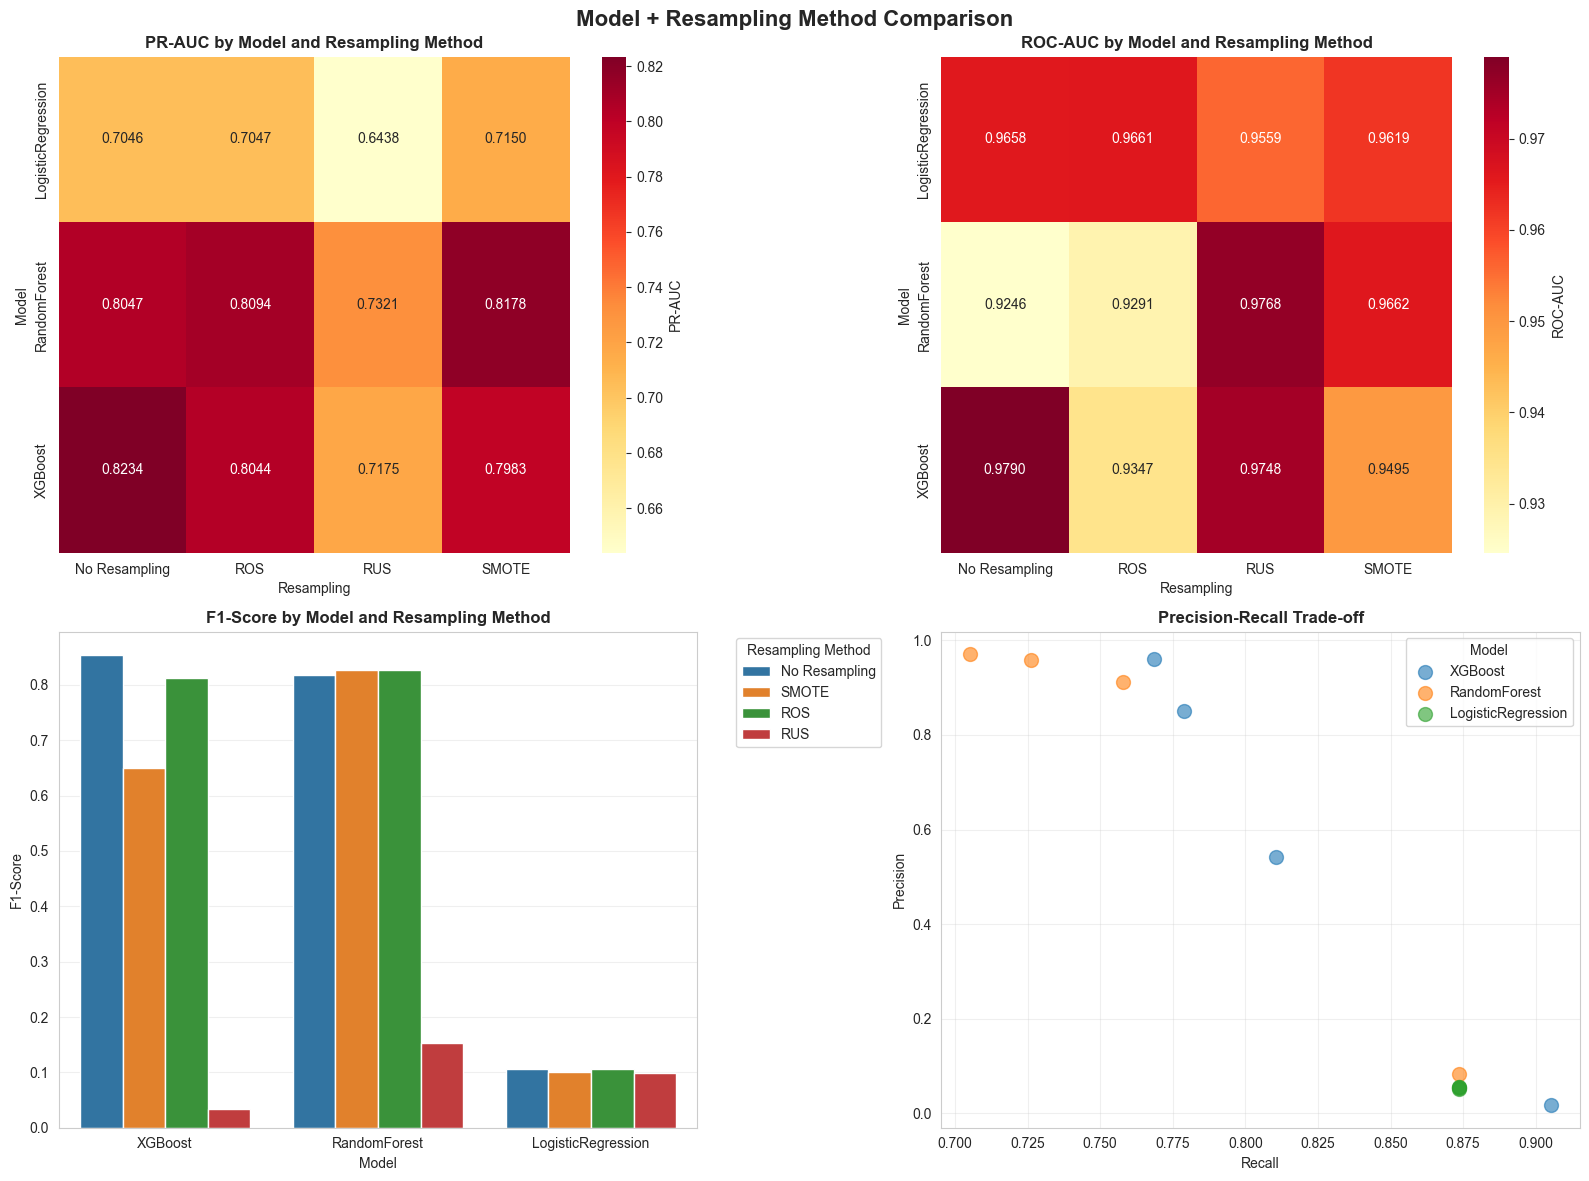


BEST COMBINATION
Model: XGBoost
Resampling: No Resampling
PR-AUC: 0.8234
ROC-AUC: 0.9790
F1-Score: 0.8538
Precision: 0.9605, Recall: 0.7684


In [72]:
# ============================================================================
# Visualization and Best Combination Selection
# ============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. PR-AUC heatmap
ax1 = axes[0, 0]
pivot_pr = results_df.pivot(index='Model', columns='Resampling', values='PR-AUC')
sns.heatmap(pivot_pr, annot=True, fmt='.4f', cmap='YlOrRd', ax=ax1, cbar_kws={'label': 'PR-AUC'})
ax1.set_title('PR-AUC by Model and Resampling Method', fontweight='bold')

# 2. ROC-AUC heatmap
ax2 = axes[0, 1]
pivot_roc = results_df.pivot(index='Model', columns='Resampling', values='ROC-AUC')
sns.heatmap(pivot_roc, annot=True, fmt='.4f', cmap='YlOrRd', ax=ax2, cbar_kws={'label': 'ROC-AUC'})
ax2.set_title('ROC-AUC by Model and Resampling Method', fontweight='bold')

# 3. F1-Score comparison
ax3 = axes[1, 0]
sns.barplot(data=results_df, x='Model', y='F1-Score', hue='Resampling', ax=ax3)
ax3.set_title('F1-Score by Model and Resampling Method', fontweight='bold')
ax3.legend(title='Resampling Method', bbox_to_anchor=(1.05, 1), loc='upper left')
ax3.grid(True, alpha=0.3, axis='y')

# 4. Precision-Recall trade-off
ax4 = axes[1, 1]
for model in results_df['Model'].unique():
    data = results_df[results_df['Model'] == model]
    ax4.scatter(data['Recall'], data['Precision'], label=model, s=100, alpha=0.6)
ax4.set_xlabel('Recall')
ax4.set_ylabel('Precision')
ax4.set_title('Precision-Recall Trade-off', fontweight='bold')
ax4.legend(title='Model')
ax4.grid(True, alpha=0.3)

plt.suptitle('Model + Resampling Method Comparison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Select best combination
best_combo = results_df.iloc[0]
print("\n" + "="*70)
print("BEST COMBINATION")
print("="*70)
print(f"Model: {best_combo['Model']}")
print(f"Resampling: {best_combo['Resampling']}")
print(f"PR-AUC: {best_combo['PR-AUC']:.4f}")
print(f"ROC-AUC: {best_combo['ROC-AUC']:.4f}")
print(f"F1-Score: {best_combo['F1-Score']:.4f}")
print(f"Precision: {best_combo['Precision']:.4f}, Recall: {best_combo['Recall']:.4f}")
print("="*70)

## 6.1 Logistic Regression

LOGISTIC REGRESSION WITH SMOTE - DETAILED EVALUATION

1. CLASSIFICATION REPORT:
----------------------------------------------------------------------
              precision    recall  f1-score   support

      Normal       1.00      0.97      0.99     56651
       Fraud       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.99     56746


2. CONFUSION MATRIX:
----------------------------------------------------------------------
Confusion Matrix:
 [[55169  1482]
 [   12    83]]


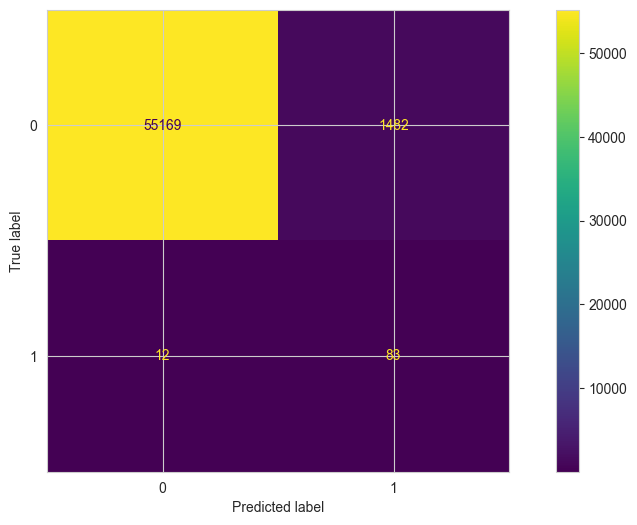

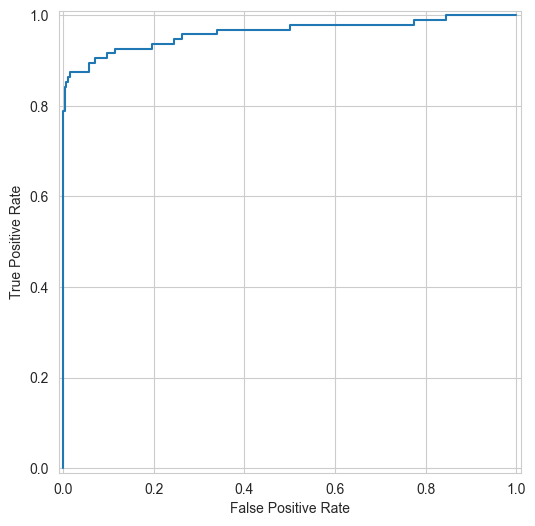

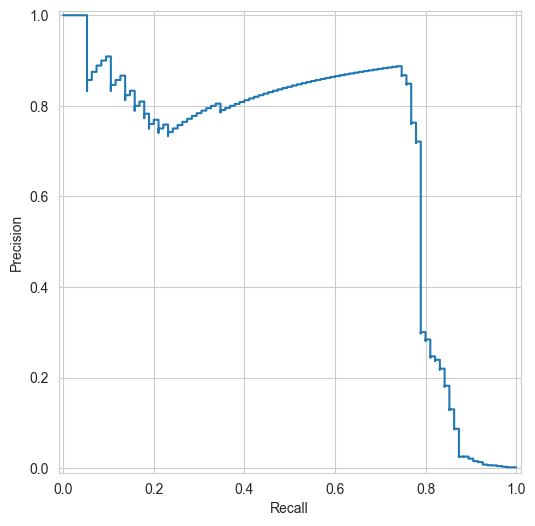

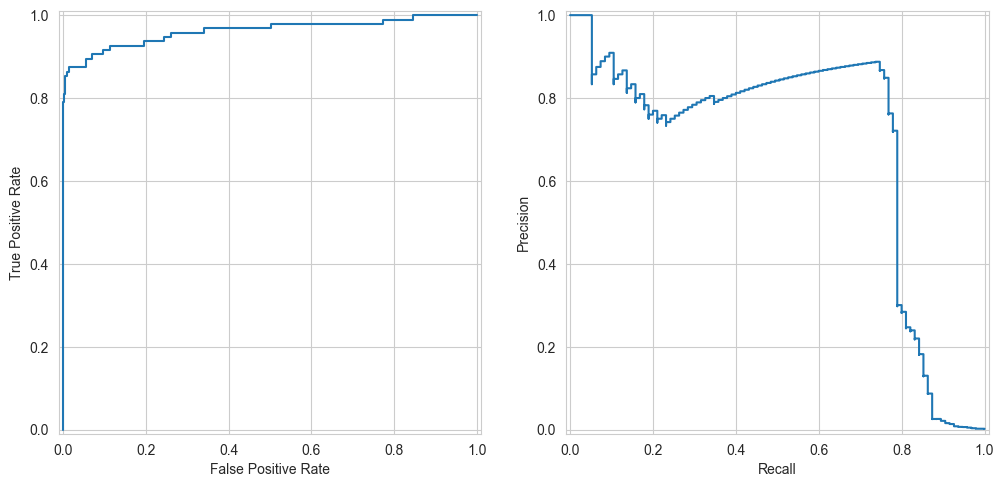

Text(0.5, 1.0, '2-class Precision-Recall curve')
Text(0.5, 1.0, '2-class Precision-Recall curve')

Confusion Matrix Values:
                    Predicted
                 Normal   Fraud
Actual  Normal     55169    1482
        Fraud         12      83

Interpretation:
  True Negatives (TN):   55169 - Correctly identified normal transactions
  False Positives (FP):   1482 - Normal transactions flagged as fraud (Type I Error)
  False Negatives (FN):     12 - Fraud transactions missed (Type II Error)
  True Positives (TP):      83 - Correctly identified fraud transactions


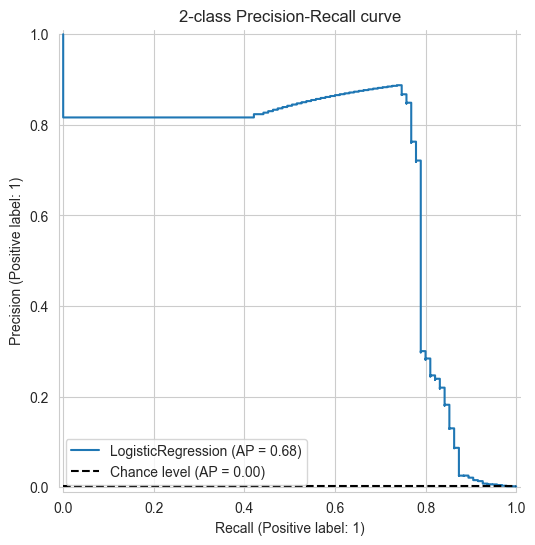

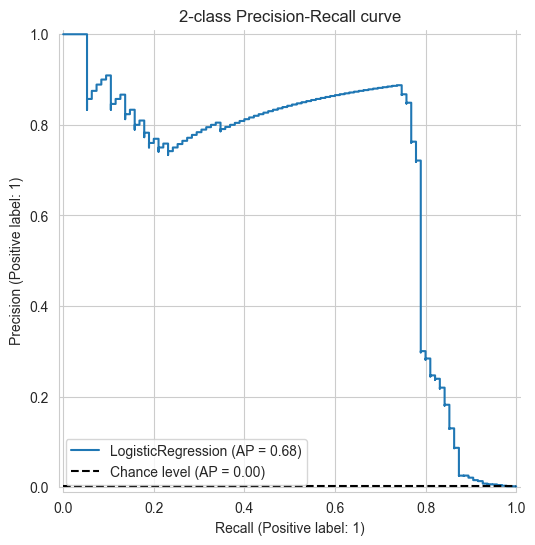

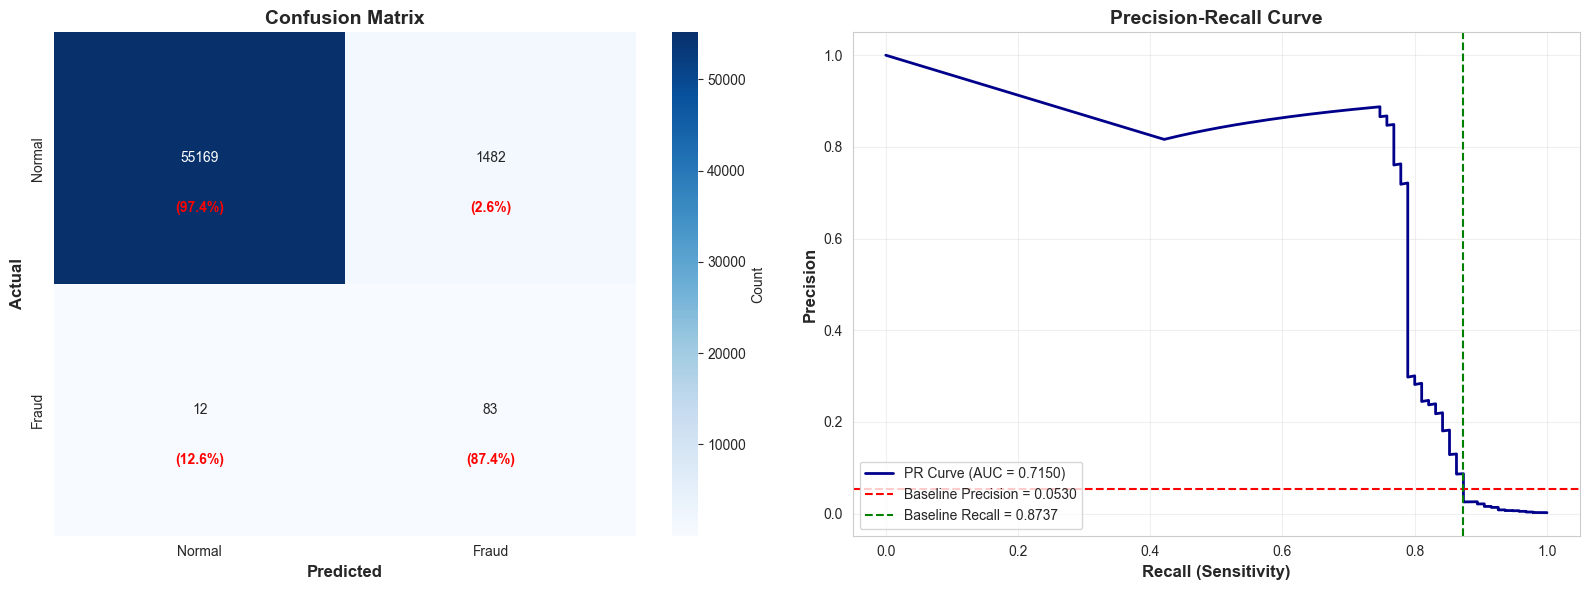


3. R2 SCORE:
----------------------------------------------------------------------
  R2 Score (using probabilities): -13.3196
  Note: R2 score is primarily used for regression tasks.
        For classification, ROC-AUC and PR-AUC are more appropriate metrics.

4. ADDITIONAL METRICS:
----------------------------------------------------------------------
  ROC-AUC:  0.9619
  PR-AUC:   0.7150
  Precision: 0.0530 (from confusion matrix)
  Recall:    0.8737 (from confusion matrix)
  F1-Score:  0.1000


In [42]:
# ============================================================================
# Detailed Evaluation: Logistic Regression with SMOTE
# ============================================================================
from sklearn.metrics import (
    classification_report, confusion_matrix, 
    roc_auc_score, precision_recall_curve, auc,
    r2_score
)
from sklearn.linear_model import LogisticRegression
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("="*70)
print("LOGISTIC REGRESSION WITH SMOTE - DETAILED EVALUATION")
print("="*70)

# Get the best performing Logistic Regression with SMOTE
# Extract SMOTE data from resampled_datasets
X_train_lr_smote, y_train_lr_smote = resampled_datasets['SMOTE']

# Train Logistic Regression with SMOTE
lr_smote = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight='balanced',
    n_jobs=-1
)
lr_smote.fit(X_train_lr_smote, y_train_lr_smote)

# Predictions
y_pred_lr_smote = lr_smote.predict(X_test_best)
y_proba_lr_smote = lr_smote.predict_proba(X_test_best)[:, 1]

# Classification Report
print("\n1. CLASSIFICATION REPORT:")
print("-" * 70)
print(classification_report(y_test, y_pred_lr_smote, target_names=['Normal', 'Fraud']))

# Confusion Matrix - Visual
print("\n2. CONFUSION MATRIX:")
print("-" * 70)
cm = confusion_matrix(y_test, y_pred_lr_smote)
print('Confusion Matrix:\n', cm)

from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
cm_display = ConfusionMatrixDisplay(cm).plot()
print(cm_display)

from sklearn.metrics import RocCurveDisplay, roc_curve

y_score = lr_smote.decision_function(X_test_best)

fpr, tpr, _ = roc_curve(y_test, y_score, pos_label=lr_smote.classes_[1])
roc_display = RocCurveDisplay(fpr=fpr, tpr=tpr).plot()
print(roc_display)


from sklearn.metrics import PrecisionRecallDisplay, precision_recall_curve

prec, recall, _ = precision_recall_curve(y_test, y_score, pos_label=lr_smote.classes_[1])
pr_display = PrecisionRecallDisplay(precision=prec, recall=recall).plot()
print(pr_display)

import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 8))

roc_display.plot(ax=ax1)
pr_display.plot(ax=ax2)
plt.show()


from sklearn.metrics import PrecisionRecallDisplay

display = PrecisionRecallDisplay.from_estimator(
    lr_smote, X_test_best, y_test, name="LogisticRegression", plot_chance_level=True, despine=True
)
print(display.ax_.set_title("2-class Precision-Recall curve"))

y_score = lr_smote.decision_function(X_test_best)

display = PrecisionRecallDisplay.from_predictions(
    y_test, y_score, name="LogisticRegression", plot_chance_level=True, despine=True
)
print(display.ax_.set_title("2-class Precision-Recall curve"))

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion Matrix Heatmap
ax1 = axes[0]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['Normal', 'Fraud'],
            yticklabels=['Normal', 'Fraud'],
            cbar_kws={'label': 'Count'})
ax1.set_xlabel('Predicted', fontsize=12, fontweight='bold')
ax1.set_ylabel('Actual', fontsize=12, fontweight='bold')
ax1.set_title('Confusion Matrix', fontsize=14, fontweight='bold')

# Add percentage annotations
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
for i in range(2):
    for j in range(2):
        ax1.text(j+0.5, i+0.7, f'({cm_percent[i,j]:.1f}%)',
                ha='center', va='center', fontsize=10, color='red', fontweight='bold')

# Calculate metrics from confusion matrix
tn, fp, fn, tp = cm.ravel()
print(f"\nConfusion Matrix Values:")
print(f"                    Predicted")
print(f"                 Normal   Fraud")
print(f"Actual  Normal    {cm[0,0]:6d}  {cm[0,1]:6d}")
print(f"        Fraud     {cm[1,0]:6d}  {cm[1,1]:6d}")

print(f"\nInterpretation:")
print(f"  True Negatives (TN):  {tn:6d} - Correctly identified normal transactions")
print(f"  False Positives (FP): {fp:6d} - Normal transactions flagged as fraud (Type I Error)")
print(f"  False Negatives (FN): {fn:6d} - Fraud transactions missed (Type II Error)")
print(f"  True Positives (TP):  {tp:6d} - Correctly identified fraud transactions")

# Precision-Recall Curve
ax2 = axes[1]
precision, recall, thresholds = precision_recall_curve(y_test, y_proba_lr_smote)
pr_auc = auc(recall, precision)

ax2.plot(recall, precision, color='darkblue', lw=2, 
         label=f'PR Curve (AUC = {pr_auc:.4f})')
ax2.axhline(y=tp/(tp+fp), color='r', linestyle='--', 
           label=f'Baseline Precision = {tp/(tp+fp):.4f}')
ax2.axvline(x=tp/(tp+fn), color='g', linestyle='--', 
           label=f'Baseline Recall = {tp/(tp+fn):.4f}')
ax2.set_xlabel('Recall (Sensitivity)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Precision', fontsize=12, fontweight='bold')
ax2.set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
ax2.legend(loc='lower left', fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# R2 Score (Note: R2 is typically for regression, but we can use it here for completeness)
print(f"\n3. R2 SCORE:")
print("-" * 70)
r2 = r2_score(y_test, y_proba_lr_smote)
print(f"  R2 Score (using probabilities): {r2:.4f}")
print(f"  Note: R2 score is primarily used for regression tasks.")
print(f"        For classification, ROC-AUC and PR-AUC are more appropriate metrics.")

# Additional Metrics
print(f"\n4. ADDITIONAL METRICS:")
print("-" * 70)
roc_auc = roc_auc_score(y_test, y_proba_lr_smote)

print(f"  ROC-AUC:  {roc_auc:.4f}")
print(f"  PR-AUC:   {pr_auc:.4f}")
print(f"  Precision: {tp / (tp + fp):.4f} (from confusion matrix)")
print(f"  Recall:    {tp / (tp + fn):.4f} (from confusion matrix)")
print(f"  F1-Score:  {2 * tp / (2 * tp + fp + fn):.4f}")


# Pipeline vs Direct Approach Analysis

PIPELINE APPROACH:
<br><br/>
  ✓ Pros:
  - Prevents data leakage (SMOTE applied only on training folds in CV)
  - Easier to deploy (single pipeline object)
  - Better for cross-validation and hyperparameter tuning
  - Ensures consistent preprocessing in production

✗ Cons:
  - Slightly more complex setup
  - Requires imblearn.pipeline.Pipeline
    
DIRECT APPROACH (Current):
✓ Pros:
  - Simple and straightforward
  - Easy to understand and debug
  - Works well when train/test split is fixed
    
✗ Cons:
  - SMOTE applied to entire training set (can cause overfitting in CV)
  - Need to manually manage preprocessing steps
  - More error-prone in production

RECOMMENDATION: 
  For production and cross-validation → Use Pipeline
  For quick experimentation → Direct approach is acceptable

IMPROVEMENT OPPORTUNITIES FOR LOGISTIC REGRESSION WITH SMOTE

2. ARE ROC-AUC AND RECALL GOOD METRICS FOR FRAUD DETECTION?"

YES - But with important caveats:

ROC-AUC (Excellent):
- ✓ Good for overall model discrimination ability
- ✓ Measures how well model separates fraud from normal
- ✓ Less sensitive to class imbalance (unlike accuracy)
- ⚠ However: In highly imbalanced datasets, ROC-AUC can be misleadingly high
             even when precision is very low

RECALL (High):
- ✓ CRITICAL for fraud detection - we want to catch as many fraud cases as possible
- ✓ High recall means we're missing only ~12.6% of fraud cases
- ✓ Important for business: Missing fraud is costly
- ⚠ Trade-off: High recall often comes with low precision (false alarms)

KEY INSIGHT:
  - For fraud detection, RECALL is often more important than PRECISION
  - However, very low precision (5.3%) means too many false positives
  - False positives = legitimate customers flagged → customer friction & support costs
  - Need to balance: Catch fraud (high recall) vs Minimize false alarms (precision)


3. WHY IS PRECISION SO LOW?

The model is being very cautious - flagging many transactions as fraud:
  - High Recall (87.4%): Catches most fraud (good!)
  - Low Precision (5.3%): But flags too many normal transactions as fraud (bad!)

This happens because:
  1. Class imbalance is extreme (fraud is rare)
  2. Model is tuned to minimize missing fraud (high recall)
  3. Decision threshold is likely too low (default 0.5)
  4. Need to adjust threshold based on business cost trade-offs


4. IMPROVEMENT STRATEGIES:

A. THRESHOLD OPTIMIZATION (Most Important):
   - Current threshold: 0.5 (default)
   - Optimize using Precision-Recall curve
   - Find threshold that balances business costs
   - Consider: Cost of missing fraud vs Cost of false alarms

B. HYPERPARAMETER TUNING:
   - C parameter: Controls regularization strength
   - Penalty type: L1 (sparse) vs L2 (ridge)
   - Solver: Try different optimization algorithms
   - Class weights: Fine-tune instead of 'balanced'

C. FEATURE ENGINEERING:
   - Add domain-specific features
   - Feature selection (remove noise)
   - Polynomial features for interactions
   - Time-based features if applicable

D. ALTERNATIVE RESAMPLING:
   - ADASYN (adaptive synthetic sampling)
   - Borderline-SMOTE (focus on borderline cases)
   - Try different SMOTE sampling ratios (not just 50/50)

E. CALIBRATION:
   - Calibrate probability outputs
   - Use Platt scaling or isotonic regression
   - Improves threshold tuning reliability

F. ENSEMBLE METHODS:
   - Combine with other models
   - Use voting or stacking
   - Can improve both precision and recall

G. BUSINESS-RULE HYBRID:
   - Use model for initial screening
   - Add business rules for high-value transactions
   - Multi-stage detection system


5. PRIORITY ACTIONS:

1. IMMEDIATE: Optimize classification threshold
   - Analyze precision-recall curve
   - Calculate cost matrix (fraud cost vs false positive cost)
   - Find optimal threshold for your business

2. SHORT-TERM: Hyperparameter tuning
   - GridSearch/RandomSearch for C, penalty, solver
   - Use cross-validation with SMOTE pipeline
   - Focus on PR-AUC as optimization metric

3. MEDIUM-TERM: Feature engineering
   - Domain expertise consultation
   - Feature importance analysis
   - Create interaction features

4. LONG-TERM: Ensemble approach
   - Combine with Random Forest or XGBoost
   - Develop multi-stage detection system


In [34]:
# ============================================================================
# IMPROVEMENT ANALYSIS: Logistic Regression with SMOTE
# ============================================================================
print("="*70)
print("IMPROVEMENT OPPORTUNITIES FOR LOGISTIC REGRESSION WITH SMOTE")
print("="*70)

# Get exact values from results_df
lr_smote_result = results_df[(results_df['Model'] == 'LogisticRegression') & 
                              (results_df['Resampling'] == 'SMOTE')].iloc[0]

print("\n1. CURRENT PERFORMANCE SUMMARY:")
print("-" * 70)
print(f"  ROC-AUC:  {lr_smote_result['ROC-AUC']:.4f}  (Excellent - near perfect)")
print(f"  PR-AUC:   {lr_smote_result['PR-AUC']:.4f}  (Moderate - good but can be improved)")
print(f"  Recall:   {lr_smote_result['Recall']:.4f}  (High - catches {lr_smote_result['Recall']*100:.1f}% of fraud)")
print(f"  Precision: {lr_smote_result['Precision']:.4f}  (Very Low - only {lr_smote_result['Precision']*100:.1f}% of flagged cases are fraud)")
print(f"  F1-Score:  {lr_smote_result['F1-Score']:.4f}  (Low due to precision/recall imbalance)")



IMPROVEMENT OPPORTUNITIES FOR LOGISTIC REGRESSION WITH SMOTE

1. CURRENT PERFORMANCE SUMMARY:
----------------------------------------------------------------------
  ROC-AUC:  0.9619  (Excellent - near perfect)
  PR-AUC:   0.7150  (Moderate - good but can be improved)
  Recall:   0.8737  (High - catches 87.4% of fraud)
  Precision: 0.0530  (Very Low - only 5.3% of flagged cases are fraud)
  F1-Score:  0.1000  (Low due to precision/recall imbalance)

  Exact Metrics from Results:
    ROC-AUC:  0.961896
    PR-AUC:   0.714997
    Precision: 0.053035
    Recall:    0.873684
    F1-Score:  0.100000

2. ARE ROC-AUC AND RECALL GOOD METRICS FOR FRAUD DETECTION?
----------------------------------------------------------------------

YES - But with important caveats:

ROC-AUC (0.9619 - Excellent):
  ✓ Good for overall model discrimination ability
  ✓ Measures how well model separates fraud from normal
  ✓ Less sensitive to class imbalance (unlike accuracy)
  ⚠ However: In highly imbalanced dat

## 6.2 RandomForest

As we saw ealier in the notebook when comparing models and resampling methods.

For Random Forest these are the Resampling methods which perform best according to various metrics:

- ROC-AUC: RUS, SMOTE, ROS, No Sample
- PR-AUC: SMOTE, ROS, No resampling, RUS
- Precision: no resample, ROS, Smote, RUS
- Recall: RUS, Smote, ROS, No Resample
- F1-Score: SMOTE, ROS, No resampling, RUS

PR-AUC and f1-score most informative

In [63]:
# Hyperparameter tuning - Random Forest
model = RandomForestClassifier(random_state=42)
model.fit(X_train_smote, y_train_smote)

# Predictions
y_pred = model.predict(X_test_smote)
y_proba = model.predict_proba(X_test_smote)[:, 1]
print(metrics.accuracy_score(y_test_smote, y_pred))

NameError: name 'X_test_smote' is not defined

In [47]:
# Count the total number of observations from the length of y
total_obs = len(y)

# Count the total number of non-fraudulent observations 
non_fraud = [i for i in y if i == 0]
count_non_fraud = non_fraud.count(0)

# Calculate the percentage of non fraud observations in the dataset
percentage = (float(count_non_fraud)/float(total_obs)) * 100

# Print the percentage: this is our "natural accuracy" by doing nothing
print(percentage)

99.83328986416473


## 6.3 XGBoost

In [ ]:
# Hyperparameter tuning - Other models (XGBoost, etc.)

## 6.4 LightGBM

## 6.5 GradientBoosting 

## 6.6 Ada Boosting

## 6.7 GaussianNB

In [ ]:
# Model ensemble/stacking

In [ ]:
# Final model selection - Without Duplicates

In [ ]:
# Comprehensive evaluation (confusion matrix, ROC, PR curves)

In [ ]:
# Feature importance analysis

In [ ]:
# Cross-validation results

# Accounting for WITH and WITHOUT Duplicates

## PART 2: Full analysis

### Section A: COMPLETE ANALYSIS WITHOUT DUPLICATES


In [ ]:
# Baseline model evaluation (Logistic Regression, Random Forest, etc.)


In [ ]:
# Hyperparameter tuning - Logistic Regression

In [ ]:
# Hyperparameter tuning - Random Forest

In [ ]:
# Hyperparameter tuning - Other models (XGBoost, etc.)

In [ ]:
# Model ensemble/stacking

In [ ]:
# Final model selection - Without Duplicates

In [ ]:
# Comprehensive evaluation (confusion matrix, ROC, PR curves)

In [ ]:
# Feature importance analysis

In [ ]:
# Cross-validation results

### Section B: COMPLETE ANALYSIS WITH DUPLICATES


In [ ]:
# Baseline model evaluation (Logistic Regression, Random Forest, etc.)


In [ ]:
# Hyperparameter tuning - Logistic Regression

In [ ]:
# Hyperparameter tuning - Random Forest

In [ ]:
# Hyperparameter tuning - Other models (XGBoost, etc.)

In [ ]:
# Model ensemble/stacking

In [ ]:
# Final model selection - Without Duplicates

In [ ]:
# Comprehensive evaluation (confusion matrix, ROC, PR curves)

In [ ]:
# Feature importance analysis

In [ ]:
# Cross-validation results

### Final Comparison: With vs Without Duplicates

In [ ]:
# Side-by-side metrics comparison (all models)


In [ ]:
# Best model comparison (from each version)

In [ ]:
# Hyperparameter differences analysis

In [ ]:
# Performance visualization (comprehensive charts)

In [ ]:
# Statistical significance tests

In [ ]:
# Trade-offs summary and recommendations

In [ ]:
# Final conclusions

# Summary and Next Steps

## Key Findings:
1. **Data Quality**: No missing values detected
2. **Class Imbalance**: Severe imbalance (~0.17% fraud rate)
3. **Imbalance Handling Options**:
   - **SMOTE**: Creates synthetic fraud samples to balance classes
   - **Class Weights**: Penalizes misclassification of minority class more heavily
4. **Feature Characteristics**: 
   - V1-V28 are PCA components (already standardized)
   - Time and Amount may need scaling
   - Strong correlations exist between certain features and fraud

## Recommendations:
- Use stratified train/test splits to maintain class distribution
- Consider both SMOTE and class weights approaches
- Focus on precision/recall metrics rather than accuracy (due to imbalance)
- Consider feature scaling for Time and Amount if using distance-based models
